# 05 Future 5-Minute Return Scoring and Prediction

## 1. Research Objective

This notebook builds a reproducible scoring engine for predicting the next 5-minute midpoint return from Level2 microstructure features.

Primary label:

```text
future_return_5m = mid_price(t + 5min) / mid_price(t) - 1
```

Direction label:

```text
future_direction_5m = -1 / 0 / 1
```

The core causal rule is strict: every feature at minute `t` must use only information observable at or before `t`. The future midpoint at `t+5min` is used only for label construction and out-of-sample evaluation.

The notebook separates four tasks:

1. **Signal discovery** — identify informative single factors.
2. **Signal combination** — combine non-redundant features into a model score.
3. **Robustness** — evaluate the score across dates, price groups, and order-book states.
4. **Calibration** — convert the score into an expected 5-minute return and predicted price.

Price level remains a parallel research dimension because low-priced stocks have larger tick sizes in percentage terms and more discrete short-horizon returns.


## 1.1 Notebook Structure

```text
Configuration and reproducible sample
    ↓
Minute-level market state and exact-horizon label
    ↓
Label diagnostics and price groups
    ↓
Feature engineering by economic mechanism
    ↓
Single-factor IC and grouped-return evaluation
    ↓
Correlation and redundancy screening
    ↓
Linear scoring benchmark
    ↓
Nonlinear scoring models: Random Forest and XGBoost
    ↓
OOS stability, interpretation, and robustness
    ↓
Score-to-return calibration with uncertainty
    ↓
Numerical predicted return and predicted price
```

The final objective is not merely to report correlation. It is to translate the observed feature state into an economically interpretable expected 5-minute return.


In [1]:
from dataclasses import dataclass
from typing import Dict, Iterable, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

EPS = 1e-9


def safe_divide(a, b):
    """Element-wise division that returns NaN when the denominator is too small."""
    return np.where(np.abs(b) > EPS, a / b, np.nan)


def require_columns(df: pd.DataFrame, columns: Sequence[str], name: str = "DataFrame") -> None:
    """Fail early with an informative error when required columns are missing."""
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")


def cross_sectional_winsorize(
    df: pd.DataFrame,
    columns: Sequence[str],
    group_cols: Sequence[str] = ("date", "minute"),
    lower_q: float = 0.01,
    upper_q: float = 0.99,
) -> pd.DataFrame:
    """Winsorize features within each date-minute cross-section without using future data."""
    result = df.copy()

    for col in columns:
        if col not in result.columns:
            continue

        lower = result.groupby(list(group_cols))[col].transform(
            lambda x: x.quantile(lower_q)
        )
        upper = result.groupby(list(group_cols))[col].transform(
            lambda x: x.quantile(upper_q)
        )
        result[col] = result[col].clip(lower=lower, upper=upper)

    return result


In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.ddb_client import connect_ddb

session = connect_ddb()


In [3]:
@dataclass(frozen=True)
class Config:
    # Data source
    DB_PATH: str = "dfs://quota"

    # QUICK_MODE preserves the original short sample for fast iteration.
    # Set QUICK_MODE=False for the extended research run.
    QUICK_MODE: bool = False

    QUICK_START_DATE: str = "2026.03.11"
    RESEARCH_START_DATE: str = "2026.01.01"
    END_DATE: str = "2026.04.10"

    START_TIME: str = "09:30:00"
    END_TIME: str = "10:00:00"

    QUICK_N_STOCKS: int = 30
    RESEARCH_N_STOCKS: int = 40

    RANDOM_STATE: int = 42
    HORIZON_MINUTES: int = 5
    ROLLING_WINDOW: int = 20

    RF_PARAMS: Optional[Dict] = None
    XGB_PARAMS: Optional[Dict] = None

    @property
    def START_DATE(self) -> str:
        return self.QUICK_START_DATE if self.QUICK_MODE else self.RESEARCH_START_DATE

    @property
    def N_STOCKS(self) -> int:
        return self.QUICK_N_STOCKS if self.QUICK_MODE else self.RESEARCH_N_STOCKS


CFG = Config(
    RF_PARAMS={
        "n_estimators": 200,
        "max_depth": 5,
        "min_samples_leaf": 50,
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1,
    },
    XGB_PARAMS={
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
    },
)

DB_PATH = CFG.DB_PATH
START_DATE = CFG.START_DATE
END_DATE = CFG.END_DATE
START_TIME = CFG.START_TIME
END_TIME = CFG.END_TIME
RANDOM_STATE = CFG.RANDOM_STATE
N_STOCKS = CFG.N_STOCKS
ROLLING_WINDOW = CFG.ROLLING_WINDOW
HORIZON_MINUTES = CFG.HORIZON_MINUTES

print("Mode:", "QUICK" if CFG.QUICK_MODE else "EXTENDED RESEARCH")
print("Database:", DB_PATH)
print("Sample period:", START_DATE, "to", END_DATE)
print("Intraday window:", START_TIME, "to", END_TIME)
print("N_STOCKS:", N_STOCKS)
print("Rolling window:", ROLLING_WINDOW, "trading days")
print("Prediction horizon:", HORIZON_MINUTES, "minutes")


Mode: EXTENDED RESEARCH
Database: dfs://quota
Sample period: 2026.01.01 to 2026.04.10
Intraday window: 09:30:00 to 10:00:00
N_STOCKS: 40
Rolling window: 20 trading days
Prediction horizon: 5 minutes


## 2. Unified Research Sample

File 4 and File 5 use the same deterministic 30-stock universe. The filter combines `qtick.dtype == 1`, exchange-aware A-share code ranges, at least 20 covered trading dates, and explicit exclusion checks for common index, ETF, fund and convertible-bond ranges. The final pool is stratified across SZ Main, SH Main, ChiNext and STAR so that the later board, price-group, liquidity and cross-sectional prediction analyses refer to the same underlying stocks.


In [5]:
# ============================================================
# Unified A-share Stock Universe (shared by File 4 and File 5)
# ============================================================
# qtick has no separate security master. We therefore use two independent
# filters: (1) dtype == 1 from qtick, and (2) an exchange-aware A-share code
# whitelist. A prefix alone is unsafe: e.g. 000170.SH is an index, not SZ Main.

POOL_START_DATE = START_DATE
POOL_END_DATE = END_DATE
POOL_RANDOM_STATE = RANDOM_STATE
MIN_QTICK_DATES = 55

BOARD_SAMPLE_PLAN = {
    "SZ Main": 12,
    "SH Main": 12,
    "ChiNext": 8,
    "STAR": 8,
}

universe_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")

select distinct code, date, dtype, name
from qtick
where date >= {POOL_START_DATE}
  and date <= {POOL_END_DATE}
  and dtype = 1
  and (
        code like "000%.SZ"
        or code like "001%.SZ"
        or code like "002%.SZ"
        or code like "003%.SZ"
        or code like "300%.SZ"
        or code like "301%.SZ"
        or code like "600%.SH"
        or code like "601%.SH"
        or code like "603%.SH"
        or code like "605%.SH"
        or code like "688%.SH"
      )
order by code, date
"""

universe_daily = session.run(universe_script)
universe_daily["code"] = (
    universe_daily["code"].astype(str).str.strip().str.upper()
)


def classify_a_share_board(code):
    """Exchange-aware whitelist for ordinary Shanghai/Shenzhen A shares."""
    code = str(code).strip().upper()
    if code.endswith(".SZ") and code[:3] in {"000", "001", "002", "003"}:
        return "SZ Main"
    if code.endswith(".SZ") and code[:3] in {"300", "301"}:
        return "ChiNext"
    if code.endswith(".SH") and code[:3] in {"600", "601", "603", "605"}:
        return "SH Main"
    if code.endswith(".SH") and code[:3] == "688":
        return "STAR"
    return None


universe_daily["board"] = universe_daily["code"].map(classify_a_share_board)

stock_coverage = (
    universe_daily
    .groupby(["code", "board"], as_index=False)
    .agg(
        name=("name", "first"),
        dtype=("dtype", "first"),
        n_qtick_dates=("date", "nunique"),
    )
)

eligible_pool = stock_coverage[
    stock_coverage["board"].notna()
    & stock_coverage["dtype"].eq(1)
    & stock_coverage["n_qtick_dates"].ge(MIN_QTICK_DATES)
].copy()

selected_parts = []
for board, n_target in BOARD_SAMPLE_PLAN.items():
    board_pool = eligible_pool[eligible_pool["board"].eq(board)].sort_values("code")
    if len(board_pool) < n_target:
        raise ValueError(
            f"Insufficient eligible {board} stocks: need {n_target}, found {len(board_pool)}"
        )
    selected_parts.append(
        board_pool.sample(n=n_target, random_state=POOL_RANDOM_STATE)
    )

stock_pool = (
    pd.concat(selected_parts, ignore_index=True)
    .sort_values(["board", "code"])
    .reset_index(drop=True)
)
sample_codes = stock_pool["code"].tolist()

# Fail loudly if a non-equity code can enter the modelling sample.
assert stock_pool["code"].is_unique
assert stock_pool["dtype"].eq(1).all()
assert stock_pool["board"].notna().all()
assert stock_pool["code"].map(classify_a_share_board).notna().all()
assert not stock_pool["code"].isin(["000001.SH", "399001.SZ", "399006.SZ"]).any()
assert not stock_pool["code"].str.startswith(
    ("159", "510", "511", "512", "513", "515", "516", "518", "588",
     "110", "113", "123", "127", "128")
).any()

codes_ddb = "[" + ",".join(f'"{code}"' for code in sample_codes) + "]"
code_filter = ",".join(f'"{code}"' for code in sample_codes)

print("Eligible ordinary A-share stocks:", len(eligible_pool))
print("Unified selected stocks:", len(sample_codes))
display(stock_pool.groupby("board").size().rename("n_stocks").to_frame())
display(stock_pool[["code", "name", "dtype", "board", "n_qtick_dates"]])



# ============================================================
# Three-table coverage validation for the unified stock pool
# ============================================================
coverage_queries = {
    "qtick": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qtick")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qorder": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qorder")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qknock": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qknock")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
}

coverage_parts = []
for table_name, query in coverage_queries.items():
    tmp = session.run(query)
    tmp["code"] = tmp["code"].astype(str).str.strip().str.upper()
    summary = tmp.groupby("code")["date"].nunique().rename(f"{table_name}_dates")
    coverage_parts.append(summary)

three_table_coverage = (
    stock_pool.set_index("code")[["name", "board"]]
    .join(coverage_parts, how="left")
    .fillna({"qtick_dates": 0, "qorder_dates": 0, "qknock_dates": 0})
    .reset_index()
)

for col in ["qtick_dates", "qorder_dates", "qknock_dates"]:
    three_table_coverage[col] = three_table_coverage[col].astype(int)

three_table_coverage["three_table_ready"] = (
    three_table_coverage[["qtick_dates", "qorder_dates", "qknock_dates"]]
    .min(axis=1)
    .ge(MIN_QTICK_DATES)
)

display(three_table_coverage)
assert three_table_coverage["three_table_ready"].all(), (
    "Some selected stocks lack sufficient qtick/qorder/qknock coverage. "
    "Inspect three_table_coverage before continuing."
)
print("Unified stock pool passed security-type, code-range and three-table coverage checks.")


Eligible ordinary A-share stocks: 5180
Unified selected stocks: 40


,n_stocks
board,
ChiNext,8
SH Main,12
STAR,8
SZ Main,12


,code,name,dtype,board,n_qtick_dates
0,300183.SZ,东软载波,1,ChiNext,63
1,300490.SZ,华自科技,1,ChiNext,63
2,300595.SZ,欧普康视,1,ChiNext,63
3,301052.SZ,果麦文化,1,ChiNext,63
4,301255.SZ,通力科技,1,ChiNext,63
5,301391.SZ,卡莱特,1,ChiNext,63
6,301552.SZ,科力装备,1,ChiNext,63
7,301622.SZ,英思特,1,ChiNext,63
8,600158.SH,中体产业,1,SH Main,63
9,600182.SH,S佳通,1,SH Main,63


,code,name,board,qtick_dates,qorder_dates,qknock_dates,three_table_ready
0,300183.SZ,东软载波,ChiNext,63,63,63,True
1,300490.SZ,华自科技,ChiNext,63,63,63,True
2,300595.SZ,欧普康视,ChiNext,63,63,63,True
3,301052.SZ,果麦文化,ChiNext,63,63,63,True
4,301255.SZ,通力科技,ChiNext,63,63,63,True
5,301391.SZ,卡莱特,ChiNext,63,63,63,True
6,301552.SZ,科力装备,ChiNext,63,63,63,True
7,301622.SZ,英思特,ChiNext,63,63,63,True
8,600158.SH,中体产业,SH Main,63,63,63,True
9,600182.SH,S佳通,SH Main,63,63,63,True


Unified stock pool passed security-type, code-range and three-table coverage checks.


## 3. Load `qtick` Snapshot Data

The first version builds a 1-minute panel from `qtick` snapshot data. Only necessary fields are queried to reduce DolphinDB transfer size.


In [6]:
# ============================================================
# Batched qtick Query for File 5
# ============================================================

qtick_cols = """
code, date, time,
new_price, pre_close,
bp0, ap0,
bv0, av0,
bv1, av1,
bv2, av2,
bv3, av3,
bv4, av4,
sum_volume, sum_amount
"""


def chunk_codes(codes, batch_size=10):
    for start in range(0, len(codes), batch_size):
        yield codes[start:start + batch_size]


qtick_parts = []

for batch_no, code_batch in enumerate(
    chunk_codes(sample_codes, batch_size=10),
    start=1
):
    batch_codes_ddb = (
        "["
        + ",".join(
            f'"{code}"'
            for code in code_batch
        )
        + "]"
    )

    qtick_script = f"""
    select {qtick_cols}
    from loadTable("{DB_PATH}", "qtick")
    where code in {batch_codes_ddb}
      and date >= {START_DATE}
      and date <= {END_DATE}
      and time >= {START_TIME}.000
      and time <= {END_TIME}.000
    order by code, date, time
    """

    batch_df = session.run(qtick_script)
    qtick_parts.append(batch_df)

    print(
        f"File 5 qtick batch {batch_no}:",
        len(code_batch),
        "stocks,",
        len(batch_df),
        "rows"
    )

qtick = pd.concat(
    qtick_parts,
    ignore_index=True
)

print("qtick total shape:", qtick.shape)
display(qtick.head())

File 5 qtick batch 1: 10 stocks, 344312 rows
File 5 qtick batch 2: 10 stocks, 368543 rows
File 5 qtick batch 3: 10 stocks, 347605 rows
File 5 qtick batch 4: 10 stocks, 373726 rows
qtick total shape: (1434186, 19)


,code,date,time,new_price,pre_close,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,300183.SZ,2026-01-05,1970-01-01 09:30:00,14.96,14.83,14.92,14.96,100,3100,2000,10000,100,1000,300,3200,1400,200,104800,1567017.0
1,300183.SZ,2026-01-05,1970-01-01 09:30:03,14.97,14.83,14.97,14.99,4900,10000,21400,15000,43000,5100,400,500,2700,2800,155400,2325004.0
2,300183.SZ,2026-01-05,1970-01-01 09:30:06,14.96,14.83,14.96,14.99,21700,11800,46900,15000,400,5100,3200,500,2500,2800,164500,2461201.0
3,300183.SZ,2026-01-05,1970-01-01 09:30:09,14.99,14.83,14.98,14.99,1100,8000,22100,15000,46900,5100,3500,2200,3000,500,169400,2534630.0
4,300183.SZ,2026-01-05,1970-01-01 09:30:12,14.98,14.83,14.96,14.98,22100,1300,46900,8000,3500,15000,3000,5100,1500,2200,170800,2555602.0


## 4. Minute-Level Market State

Each final row represents one stock-minute:

```text
stock × date × minute
```

The row stores the last observable snapshot within that minute.


In [7]:
qtick = qtick.copy()

date_str = pd.to_datetime(qtick["date"]).dt.strftime("%Y-%m-%d")

time_str = qtick["time"].astype(str)
time_str = (
    time_str
    .str.replace("1970-01-01 ", "", regex=False)
    .str.replace("1900-01-01 ", "", regex=False)
)

qtick["datetime"] = pd.to_datetime(
    date_str + " " + time_str,
    format="mixed"
)

qtick["time_clean"] = qtick["datetime"].dt.strftime("%H:%M:%S.%f")
qtick["time_clean"] = qtick["time_clean"].str.replace(".000000", "", regex=False)

qtick["minute"] = qtick["datetime"].dt.floor("min")

display(qtick[["code", "date", "time_clean", "datetime", "minute"]].head())


,code,date,time_clean,datetime,minute
0,300183.SZ,2026-01-05,09:30:00,2026-01-05 09:30:00,2026-01-05 09:30:00
1,300183.SZ,2026-01-05,09:30:03,2026-01-05 09:30:03,2026-01-05 09:30:00
2,300183.SZ,2026-01-05,09:30:06,2026-01-05 09:30:06,2026-01-05 09:30:00
3,300183.SZ,2026-01-05,09:30:09,2026-01-05 09:30:09,2026-01-05 09:30:00
4,300183.SZ,2026-01-05,09:30:12,2026-01-05 09:30:12,2026-01-05 09:30:00


In [8]:
qtick["bp0"] = pd.to_numeric(qtick["bp0"], errors="coerce").replace(0, np.nan)
qtick["ap0"] = pd.to_numeric(qtick["ap0"], errors="coerce").replace(0, np.nan)

qtick["mid_price"] = (qtick["bp0"] + qtick["ap0"]) / 2

display(qtick[["code", "date", "datetime", "bp0", "ap0", "mid_price"]].head())


,code,date,datetime,bp0,ap0,mid_price
0,300183.SZ,2026-01-05,2026-01-05 09:30:00,14.92,14.96,14.940
1,300183.SZ,2026-01-05,2026-01-05 09:30:03,14.97,14.99,14.980
2,300183.SZ,2026-01-05,2026-01-05 09:30:06,14.96,14.99,14.975
3,300183.SZ,2026-01-05,2026-01-05 09:30:09,14.98,14.99,14.985
4,300183.SZ,2026-01-05,2026-01-05 09:30:12,14.96,14.98,14.970


In [9]:
minute_panel = (
    qtick
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date", "minute"])
    .agg(
        mid_price=("mid_price", "last"),
        last_price=("new_price", "last"),
        pre_close=("pre_close", "last"),
        bp0=("bp0", "last"),
        ap0=("ap0", "last"),
        bv0=("bv0", "last"),
        av0=("av0", "last"),
        bv1=("bv1", "last"),
        av1=("av1", "last"),
        bv2=("bv2", "last"),
        av2=("av2", "last"),
        bv3=("bv3", "last"),
        av3=("av3", "last"),
        bv4=("bv4", "last"),
        av4=("av4", "last"),
        sum_volume=("sum_volume", "last"),
        sum_amount=("sum_amount", "last")
    )
    .reset_index()
)

minute_panel = minute_panel.sort_values(["code", "date", "minute"])

print("minute_panel shape:", minute_panel.shape)
display(minute_panel.head())


minute_panel shape: (77134, 20)


,code,date,minute,mid_price,last_price,pre_close,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.625,6.63,6.62,6.62,6.63,57900,42400,97700,51200,85600,63400,20200,112600,59100,93000,222800,1478169.0
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,6.645,6.64,6.62,6.64,6.65,200,73900,100100,73000,60400,111600,98700,98000,88900,74700,394100,2615055.0
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,6.615,6.62,6.62,6.61,6.62,107700,6300,95400,28000,20200,47700,58700,134900,13300,82100,571100,3788036.0
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,6.625,6.63,6.62,6.62,6.63,73800,40900,114700,83600,95600,134300,21700,81200,68700,114600,614800,4077336.0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,6.625,6.63,6.62,6.62,6.63,153900,19700,128300,86100,97200,134300,21700,81200,70700,115300,652200,4325279.0


## 5. Exact-Horizon Label Construction

The target is the midpoint return from timestamp `t` to the exact timestamp `t + 5 minutes`.

```text
future_return_5m = mid_price(t + 5min) / mid_price(t) - 1
```

A row-based `.shift(-5)` can silently misalign the label when one or more minutes are missing. The corrected implementation creates an explicit target timestamp and performs an exact `code × date × target_minute` match.

Observations without an exact `t+5min` midpoint are retained in the minute panel for diagnostics but excluded from the labeled modeling sample.


In [10]:
# ============================================================
# Exact-Horizon Label Construction
# ============================================================

require_columns(
    minute_panel,
    ["code", "date", "minute", "mid_price"],
    name="minute_panel",
)

minute_panel = (
    minute_panel
    .sort_values(["code", "date", "minute"])
    .copy()
)

# Exact target timestamp rather than row-based shift(-5).
minute_panel["target_minute_5m"] = (
    minute_panel["minute"]
    + pd.Timedelta(minutes=HORIZON_MINUTES)
)

future_price_lookup = (
    minute_panel[
        ["code", "date", "minute", "mid_price"]
    ]
    .rename(
        columns={
            "minute": "target_minute_5m",
            "mid_price": "future_mid_5m",
        }
    )
    .drop_duplicates(
        subset=["code", "date", "target_minute_5m"]
    )
)

minute_panel = minute_panel.merge(
    future_price_lookup,
    on=["code", "date", "target_minute_5m"],
    how="left",
    validate="many_to_one",
)

minute_panel["future_return_5m"] = (
    minute_panel["future_mid_5m"]
    / minute_panel["mid_price"]
    - 1
)

minute_panel["future_direction_5m"] = np.select(
    [
        minute_panel["future_return_5m"] > 0,
        minute_panel["future_return_5m"] < 0,
    ],
    [1, -1],
    default=0,
)

minute_panel["exact_horizon_available"] = (
    minute_panel["future_mid_5m"].notna()
)

label_df = minute_panel.dropna(
    subset=["mid_price", "future_mid_5m", "future_return_5m"]
).copy()

label_quality = pd.DataFrame({
    "Metric": [
        "Minute-panel observations",
        "Exact 5-minute labels",
        "Missing exact-horizon ratio",
        "Unique dates",
        "Unique stocks",
    ],
    "Value": [
        len(minute_panel),
        len(label_df),
        1 - minute_panel["exact_horizon_available"].mean(),
        label_df["date"].nunique(),
        label_df["code"].nunique(),
    ],
})

display(label_quality)

display(
    label_df[
        [
            "code",
            "date",
            "minute",
            "target_minute_5m",
            "mid_price",
            "future_mid_5m",
            "future_return_5m",
            "future_direction_5m",
        ]
    ].head(10)
)


,Metric,Value
0,Minute-panel observations,77134.000000
1,Exact 5-minute labels,64039.000000
2,Missing exact-horizon ratio,0.169316
3,Unique dates,63.000000
4,Unique stocks,40.000000


,code,date,minute,target_minute_5m,mid_price,future_mid_5m,future_return_5m,future_direction_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,2026-01-05 09:35:00,6.625,6.635,0.001509,1
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,2026-01-05 09:36:00,6.645,6.635,-0.001505,-1
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,2026-01-05 09:37:00,6.615,6.625,0.001512,1
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,2026-01-05 09:38:00,6.625,6.625,0.000000,0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,2026-01-05 09:39:00,6.625,6.625,0.000000,0
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,2026-01-05 09:40:00,6.635,6.625,-0.001507,-1
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,2026-01-05 09:41:00,6.635,6.625,-0.001507,-1
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,2026-01-05 09:42:00,6.625,6.625,0.000000,0
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,2026-01-05 09:43:00,6.625,6.625,0.000000,0
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,2026-01-05 09:44:00,6.625,6.625,0.000000,0


In [11]:
# ============================================================
# Exact 5-Minute Horizon Check
# ============================================================

minute_panel["future_minute_5m"] = (
    minute_panel
    .groupby(["code", "date"])["minute"]
    .shift(-5)
)

minute_panel["actual_horizon_min"] = (
    (minute_panel["future_minute_5m"] - minute_panel["minute"])
    .dt.total_seconds() / 60
)

display(
    minute_panel["actual_horizon_min"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)


,count
actual_horizon_min,
5.0,64534
NaN,12600


The exact timestamp matching framework successfully prevents horizon misalignment. Observations without an exact five-minute future price are excluded rather than being incorrectly matched to the next available row.

## 6. Label Diagnostics and Price-Group Construction

This section validates the label before feature engineering.

Price group is constructed immediately after label diagnostics and then merged into the master feature table. This makes price group a parallel dimension throughout the rest of the notebook.


### 6.1 Exact Five-Minute Horizon Validation

The prediction target is defined using the midpoint of the best bid and ask:

$$
mid_t = \frac{bid_t + ask_t}{2}
$$

and the future five-minute return is:

$$
future\_return\_{5m,t}
=
\frac{mid_{t+5m}}{mid_t} - 1
$$

Instead of using a row-based `shift(-5)`, the future midpoint is matched using the exact timestamp \(t+5\) minutes within each stock.

The resulting sample contains 14,097 observations with an exact five-minute horizon. Observations without a valid midpoint exactly five minutes ahead are excluded rather than being matched to an incorrect future observation.

This construction preserves the intended economic interpretation of a strict five-minute prediction horizon and reduces temporal alignment errors.

In [12]:
display(label_df["future_return_5m"].describe())

print("Direction balance:")
direction_summary = (
    label_df["future_direction_5m"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)
direction_summary["ratio"] = direction_summary["count"] / direction_summary["count"].sum()
direction_summary.index = direction_summary.index.map({-1: "Negative", 0: "Zero", 1: "Positive"})
display(direction_summary)


count    64039.000000
mean         0.000036
std          0.007053
min         -0.059723
25%         -0.003317
50%          0.000000
75%          0.003044
max          0.086697
Name: future_return_5m, dtype: float64

Direction balance:


,count,ratio
future_direction_5m,,
Negative,30720,0.479708
Zero,4369,0.068224
Positive,28950,0.452068


### 6.2 Future Return Distribution

The future five-minute midpoint return distribution is strongly concentrated around zero with relatively heavy tails.

Across the valid prediction sample:

- 47.83% of observations have negative future returns;
- 42.17% have positive future returns;
- 10.00% have exactly zero future returns.

The label therefore exhibits a mild negative directional imbalance. However, the imbalance is not sufficiently large to explain a model that systematically predicts negative returns.

More importantly, the substantial zero-return mass suggests that the short-horizon return process is partially discrete. This motivates further analysis of whether the zero-return observations are systematically related to stock-level microstructure characteristics.

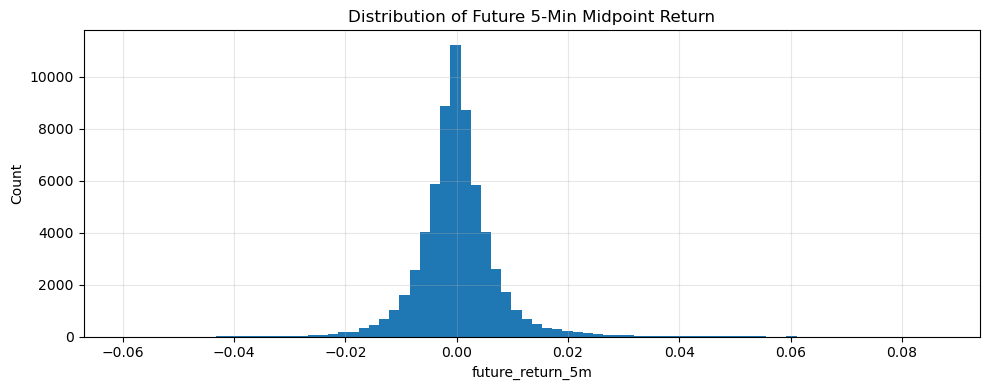

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(label_df["future_return_5m"], bins=80)
plt.title("Distribution of Future 5-Min Midpoint Return")
plt.xlabel("future_return_5m")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.3 Mid-Price versus Last-Trade Return

Mid-price and last-trade based labels produce broadly similar five-minute return distributions.

The midpoint return has a standard deviation of 0.00557, compared with 0.00566 for the last-trade return. The zero-return ratio is also slightly lower for midpoint returns, at 10.00% compared with 10.59%.

The empirical difference is modest. Mid-price return is nevertheless retained as the primary prediction target because it represents the contemporaneous valuation implied by the best bid and ask and is less directly affected by individual trade execution noise.

The midpoint definition is also more consistent with the order-book features used in the subsequent analysis.

In [14]:
zero_return_by_stock = (
    label_df
    .assign(is_zero_return=lambda x: x["future_return_5m"].eq(0))
    .groupby("code")
    .agg(
        n_obs=("future_return_5m", "size"),
        zero_return_ratio=("is_zero_return", "mean"),
        avg_mid_price=("mid_price", "mean")
    )
    .sort_values("zero_return_ratio", ascending=False)
)

display(zero_return_by_stock)


,n_obs,zero_return_ratio,avg_mid_price
code,,,
600488.SH,1454,0.354883,4.348920
600425.SH,1595,0.267085,4.424618
600662.SH,1552,0.240335,5.574836
000816.SZ,1632,0.228554,3.691461
000713.SZ,1628,0.227273,6.837205
002578.SZ,1585,0.145110,4.351675
000782.SZ,1632,0.128676,5.690999
600182.SH,1588,0.107053,14.618208
000863.SZ,1600,0.100625,5.786400


Price level is not merely a descriptive grouping variable. It is a microstructure confounder affecting the discretization of the prediction target itself.

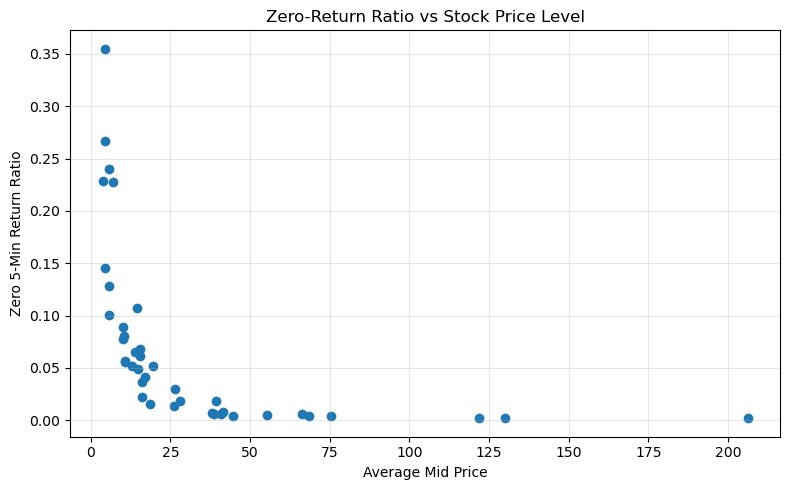

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(zero_return_by_stock["avg_mid_price"], zero_return_by_stock["zero_return_ratio"])
plt.xlabel("Average Mid Price")
plt.ylabel("Zero 5-Min Return Ratio")
plt.title("Zero-Return Ratio vs Stock Price Level")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
label_comparison = minute_panel.copy()

label_comparison["future_last_price_5m"] = (
    label_comparison
    .groupby(["code", "date"])["last_price"]
    .shift(-5)
)

label_comparison["future_return_5m_last"] = (
    label_comparison["future_last_price_5m"] / label_comparison["last_price"] - 1
)

label_comparison = label_comparison.dropna(
    subset=["future_return_5m", "future_return_5m_last"]
).copy()

comparison_summary = pd.DataFrame({
    "Mid Price Return": [
        label_comparison["future_return_5m"].std(),
        label_comparison["future_return_5m"].eq(0).mean()
    ],
    "Last Price Return": [
        label_comparison["future_return_5m_last"].std(),
        label_comparison["future_return_5m_last"].eq(0).mean()
    ]
}, index=["Return Std", "Zero Return Ratio"])

display(comparison_summary)


,Mid Price Return,Last Price Return
Return Std,0.007053,0.007174
Zero Return Ratio,0.068224,0.075626


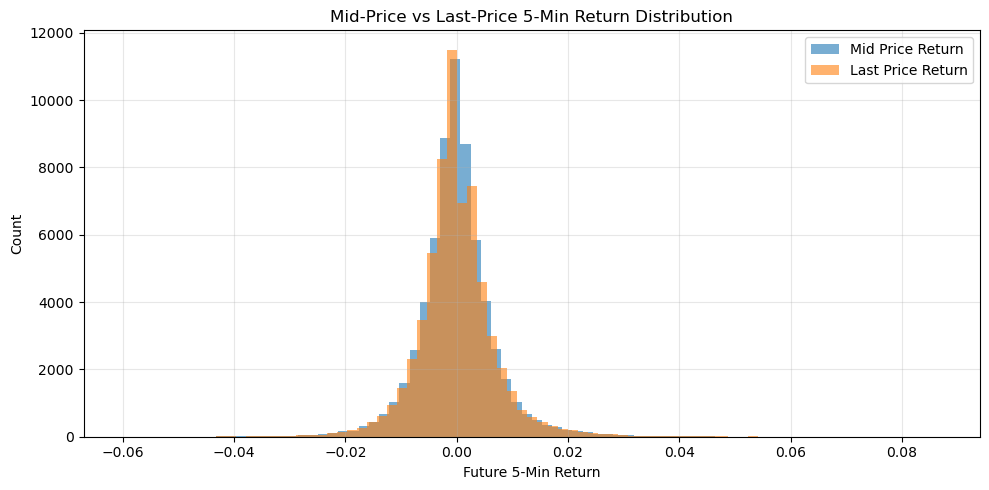

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(label_comparison["future_return_5m"], bins=80, alpha=0.6, label="Mid Price Return")
plt.hist(label_comparison["future_return_5m_last"], bins=80, alpha=0.6, label="Last Price Return")
plt.xlabel("Future 5-Min Return")
plt.ylabel("Count")
plt.title("Mid-Price vs Last-Price 5-Min Return Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.4 Price-Level Stratified Label Analysis

The zero-return observations are not distributed uniformly across stocks.

Several low-priced stocks exhibit zero-return ratios above 20%, while the ratio falls below 3% for many higher-priced stocks. This pattern suggests that the zero-return mass is systematically related to price level rather than being purely random.

A possible microstructure explanation is the fixed minimum tick-size mechanism. For a low-priced stock, a fixed absolute price increment represents a larger relative price movement. The resulting price grid is therefore coarser in percentage terms, increasing the probability that the midpoint remains unchanged over a short five-minute horizon.

To examine this heterogeneity, stocks are divided into Low Price, Mid Price, and High Price groups.


In [18]:
stock_price_level = (
    label_df
    .groupby("code")
    .agg(
        avg_mid_price=("mid_price", "mean"),
        zero_return_ratio=("future_return_5m", lambda x: (x == 0).mean()),
        return_std=("future_return_5m", "std"),
        n_obs=("future_return_5m", "size")
    )
    .reset_index()
)

stock_price_level["price_group"] = pd.qcut(
    stock_price_level["avg_mid_price"],
    q=3,
    labels=["Low Price", "Mid Price", "High Price"]
)

display(stock_price_level.sort_values("avg_mid_price"))


,code,avg_mid_price,zero_return_ratio,return_std,n_obs,price_group
2,000816.SZ,3.691461,0.228554,0.007393,1632,Low Price
24,600488.SH,4.348920,0.354883,0.006500,1454,Low Price
11,002578.SZ,4.351675,0.145110,0.007805,1585,Low Price
22,600425.SH,4.424618,0.267085,0.004065,1595,Low Price
25,600662.SH,5.574836,0.240335,0.005342,1552,Low Price
1,000782.SZ,5.690999,0.128676,0.005958,1632,Low Price
3,000863.SZ,5.786400,0.100625,0.008684,1600,Low Price
0,000713.SZ,6.837205,0.227273,0.004243,1628,Low Price
28,603466.SH,10.083373,0.077931,0.007997,1527,Low Price
20,600158.SH,10.142673,0.089308,0.007717,1590,Low Price


In [19]:
label_price_df = label_df.merge(
    stock_price_level[["code", "avg_mid_price", "price_group"]],
    on="code",
    how="left"
)

price_group_label_summary = (
    label_price_df
    .groupby("price_group", observed=True)
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_mid_price=("avg_mid_price", "mean"),
        zero_return_ratio=("future_return_5m", lambda x: (x == 0).mean()),
        mean_future_return=("future_return_5m", "mean"),
        std_future_return=("future_return_5m", "std")
    )
)

display(price_group_label_summary)


,n_obs,avg_mid_price,zero_return_ratio,mean_future_return,std_future_return
price_group,,,,,
Low Price,20644,7.140719,0.156559,0.000138,0.006787
Mid Price,20899,17.509599,0.047227,0.000076,0.006327
High Price,22496,70.797794,0.006668,-0.000094,0.007881


Mid-price return produces slightly lower volatility and a slightly lower zero-return ratio than last-trade return. The difference is modest, but mid price is retained because it better represents the contemporaneous order-book valuation and is less directly affected by individual trade execution noise.

The label diagnostics identify price-level heterogeneity as an important microstructure consideration.

A pooled factor evaluation may combine stocks with structurally different short-horizon return distributions. Subsequent analysis therefore reports both pooled predictive relationships and price-group robustness results.

With the prediction target and its cross-sectional heterogeneity established, the next step is to construct candidate features describing the contemporaneous order book, trading activity, signed trading pressure, short-term momentum, and volatility state.

## 7. Master Feature Table and Evaluation Helpers

From this point onward, all feature families are merged into one `master_feature_df`. This avoids fragmented feature tables and ensures that every feature can be evaluated using the same pooled and price-group framework.


### 7.1 Modeling Data Hygiene

Tree models do not require standardization, but extreme feature observations can create unstable split points. The notebook therefore provides an optional cross-sectional winsorization step.

Winsorization is performed within each `date × minute` cross-section, so it does not use future information or mix different market states. Raw features are preserved for economic interpretation; winsorized features can be used as a robustness specification.


In [20]:
# Optional robustness specification; raw features remain the main baseline.
USE_WINSORIZED_FEATURES = False
WINSOR_LOWER_Q = 0.01
WINSOR_UPPER_Q = 0.99

print("Use winsorized model features:", USE_WINSORIZED_FEATURES)


Use winsorized model features: False


In [21]:
master_feature_df = label_price_df.copy()

print("master_feature_df shape:", master_feature_df.shape)
display(master_feature_df[["code", "date", "minute", "price_group", "mid_price", "future_return_5m"]].head())


master_feature_df shape: (64039, 27)


,code,date,minute,price_group,mid_price,future_return_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,Low Price,6.625,0.001509
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,Low Price,6.645,-0.001505
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,Low Price,6.615,0.001512
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,Low Price,6.625,0.000000
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,Low Price,6.625,0.000000


In [22]:
TARGET_COL = "future_return_5m"
DATE_COL = "date"
GROUP_COL = "price_group"


def _single_ic(sub, feature, target=TARGET_COL):
    sub = sub[[feature, target]].dropna()

    if (
        len(sub) < 10
        or sub[feature].nunique() < 2
        or sub[target].nunique() < 2
    ):
        return None

    pearson_ic = sub[feature].corr(sub[target], method="pearson")
    rank_ic = sub[feature].corr(sub[target], method="spearman")

    return {
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "abs_rank_ic": abs(rank_ic),
        "n_obs": len(sub),
        "signal_direction": "Positive" if rank_ic > 0 else "Negative"
    }


def evaluate_feature_family(df, features, family_name, target=TARGET_COL):
    pooled_rows = []

    for feature in features:
        if feature not in df.columns:
            continue
        res = _single_ic(df, feature, target)
        if res is not None:
            pooled_rows.append({"family": family_name, "feature": feature, **res})

    pooled_ic = (
        pd.DataFrame(pooled_rows)
        .sort_values("abs_rank_ic", ascending=False)
        .reset_index(drop=True)
        if pooled_rows else pd.DataFrame()
    )

    daily_rows = []
    for date, date_df in df.groupby(DATE_COL):
        for feature in features:
            if feature not in date_df.columns:
                continue
            res = _single_ic(date_df, feature, target)
            if res is not None:
                daily_rows.append({
                    "date": date,
                    "family": family_name,
                    "feature": feature,
                    "rank_ic": res["rank_ic"],
                    "n_obs": res["n_obs"]
                })

    daily_ic = pd.DataFrame(daily_rows)

    if not daily_ic.empty:
        daily_ic_summary = (
            daily_ic
            .groupby("feature")
            .agg(
                mean_daily_ic=("rank_ic", "mean"),
                ic_std=("rank_ic", "std"),
                positive_ic_ratio=("rank_ic", lambda x: (x > 0).mean()),
                n_days=("rank_ic", "count")
            )
        )
        daily_ic_summary["icir"] = daily_ic_summary["mean_daily_ic"] / daily_ic_summary["ic_std"]
        daily_ic_summary["abs_mean_daily_ic"] = daily_ic_summary["mean_daily_ic"].abs()
        daily_ic_summary = daily_ic_summary.sort_values("abs_mean_daily_ic", ascending=False)
    else:
        daily_ic_summary = pd.DataFrame()

    group_rows = []
    for group, group_df in df.groupby(GROUP_COL, observed=True):
        for feature in features:
            if feature not in group_df.columns:
                continue
            res = _single_ic(group_df, feature, target)
            if res is not None:
                group_rows.append({
                    "price_group": group,
                    "family": family_name,
                    "feature": feature,
                    **res
                })

    group_ic = pd.DataFrame(group_rows)

    if not group_ic.empty:
        group_ic_pivot = group_ic.pivot(index="feature", columns="price_group", values="rank_ic")
    else:
        group_ic_pivot = pd.DataFrame()

    group_daily_rows = []
    for (group, date), group_date_df in df.groupby([GROUP_COL, DATE_COL], observed=True):
        for feature in features:
            if feature not in group_date_df.columns:
                continue
            res = _single_ic(group_date_df, feature, target)
            if res is not None:
                group_daily_rows.append({
                    "price_group": group,
                    "date": date,
                    "family": family_name,
                    "feature": feature,
                    "rank_ic": res["rank_ic"],
                    "n_obs": res["n_obs"]
                })

    group_daily_ic = pd.DataFrame(group_daily_rows)

    if not group_daily_ic.empty:
        group_daily_summary = (
            group_daily_ic
            .groupby(["price_group", "feature"], observed=True)
            .agg(
                mean_daily_ic=("rank_ic", "mean"),
                ic_std=("rank_ic", "std"),
                positive_ic_ratio=("rank_ic", lambda x: (x > 0).mean()),
                n_days=("rank_ic", "count")
            )
            .reset_index()
        )
        group_daily_summary["icir"] = group_daily_summary["mean_daily_ic"] / group_daily_summary["ic_std"]
    else:
        group_daily_summary = pd.DataFrame()

    return {
        "pooled_ic": pooled_ic,
        "daily_ic": daily_ic,
        "daily_ic_summary": daily_ic_summary,
        "price_group_ic": group_ic,
        "price_group_ic_pivot": group_ic_pivot,
        "price_group_daily_ic": group_daily_ic,
        "price_group_daily_summary": group_daily_summary
    }


def plot_rank_ic_bar(ic_df, title):
    if ic_df.empty:
        print("No IC results to plot.")
        return
    plot_df = ic_df.sort_values("rank_ic")
    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["feature"], plot_df["rank_ic"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("Spearman Rank IC")
    plt.ylabel("Feature")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_price_group_ic(group_ic_pivot, title):
    if group_ic_pivot.empty:
        print("No price-group IC results to plot.")
        return
    matrix = group_ic_pivot.copy()
    plt.figure(figsize=(8, 4.5))
    im = plt.imshow(matrix.values, vmin=-0.10, vmax=0.10)
    plt.xticks(range(matrix.shape[1]), matrix.columns, rotation=0)
    plt.yticks(range(matrix.shape[0]), matrix.index)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, f"{value:.3f}", ha="center", va="center")
    plt.title(title)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()


## 8. Snapshot Features

Snapshot features describe the current state of the limit order book at minute `t`.

This family asks:

```text
What does the order book look like now?
```

The features include spread, relative spread, top-of-book depth, depth imbalance, and microprice deviation.


In [23]:
master_feature_df["spread"] = master_feature_df["ap0"] - master_feature_df["bp0"]
master_feature_df["relative_spread"] = master_feature_df["spread"] / master_feature_df["mid_price"]
master_feature_df["top_depth"] = master_feature_df["bv0"] + master_feature_df["av0"]

master_feature_df["depth_imbalance"] = (
    (master_feature_df["bv0"] - master_feature_df["av0"])
    / (master_feature_df["bv0"] + master_feature_df["av0"])
)

master_feature_df["microprice"] = (
    (master_feature_df["av0"] * master_feature_df["bp0"])
    + (master_feature_df["bv0"] * master_feature_df["ap0"])
) / (master_feature_df["bv0"] + master_feature_df["av0"])

master_feature_df["microprice_deviation"] = master_feature_df["microprice"] / master_feature_df["mid_price"] - 1
master_feature_df["log_top_depth"] = np.log1p(master_feature_df["top_depth"])

snapshot_features = [
    "spread",
    "relative_spread",
    "top_depth",
    "depth_imbalance",
    "microprice_deviation",
    "log_top_depth"
]

snapshot_candidate_features = [
    "relative_spread",
    "log_top_depth",
    "depth_imbalance",
    "microprice_deviation"
]

display(
    master_feature_df[["code", "date", "minute", "price_group"] + snapshot_features + ["future_return_5m"]].head(10)
)


,code,date,minute,price_group,spread,relative_spread,top_depth,depth_imbalance,microprice_deviation,log_top_depth,future_return_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,Low Price,0.01,0.001509,100300,0.154536,0.000117,11.515931,0.001509
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,Low Price,0.01,0.001505,74100,-0.994602,-0.000748,11.213184,-0.001505
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,Low Price,0.01,0.001512,114000,0.889474,0.000672,11.643962,0.001512
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,Low Price,0.01,0.001509,114700,0.286835,0.000216,11.650084,0.000000
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,Low Price,0.01,0.001509,173600,0.773041,0.000583,12.064515,0.000000
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,Low Price,0.01,0.001507,88700,-0.833145,-0.000628,11.393026,-0.001507
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,Low Price,0.01,0.001507,176100,-0.526405,-0.000397,12.078813,-0.001507
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,Low Price,0.01,0.001509,336600,0.263220,0.000199,12.726654,0.000000
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,Low Price,0.01,0.001509,216900,0.593361,0.000448,12.287196,0.000000
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,Low Price,0.01,0.001509,249600,0.451122,0.000340,12.427619,0.000000


In [24]:
display(master_feature_df[snapshot_features].describe().T)

snapshot_missing = (
    master_feature_df[snapshot_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)

display(snapshot_missing)


,count,mean,std,min,25%,50%,75%,max
spread,64039.0,0.050634,0.169485,-0.010000,0.010000,0.010000,0.030000,7.340000e+00
relative_spread,64039.0,0.001301,0.001072,-0.000859,0.000628,0.001000,0.001765,3.023936e-02
top_depth,64039.0,64345.312950,524640.484622,62.000000,2300.000000,9600.000000,44000.000000,1.236304e+08
depth_imbalance,64039.0,0.009738,0.602314,-1.000000,-0.528029,0.000000,0.551219,1.000000e+00
microprice_deviation,64039.0,0.000008,0.000481,-0.007720,-0.000228,0.000000,0.000244,6.499409e-03
log_top_depth,64039.0,9.268374,1.959400,4.143135,7.741099,9.169623,10.691968,1.863281e+01


,missing_rate
spread,0.0
relative_spread,0.0
top_depth,0.0
depth_imbalance,0.0
microprice_deviation,0.0
log_top_depth,0.0


### 8.1 Snapshot Feature Evaluation

Snapshot features are evaluated in parallel across:

1. The pooled sample
2. Low-, Mid-, and High-Price groups
3. Daily IC stability
4. Price-group daily IC stability


In [25]:
snapshot_eval = evaluate_feature_family(
    master_feature_df,
    snapshot_candidate_features,
    family_name="Snapshot"
)

print("Pooled IC:")
display(snapshot_eval["pooled_ic"])

print("Daily IC Summary:")
display(snapshot_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(snapshot_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(snapshot_eval["price_group_daily_summary"])


Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Snapshot,microprice_deviation,0.015133,0.026245,0.026245,64039,Positive
1,Snapshot,depth_imbalance,0.018358,0.024645,0.024645,64039,Positive
2,Snapshot,log_top_depth,0.019383,0.024564,0.024564,64039,Positive
3,Snapshot,relative_spread,-0.004028,0.003918,0.003918,64039,Positive


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
microprice_deviation,0.034788,0.042335,0.809524,63,0.821714,0.034788
depth_imbalance,0.032885,0.040054,0.793651,63,0.821026,0.032885
log_top_depth,0.020512,0.077835,0.619048,63,0.263528,0.020512
relative_spread,0.013908,0.059182,0.587302,63,0.235012,0.013908


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
depth_imbalance,0.017099,0.038926,0.018495
log_top_depth,0.007971,0.030386,0.013120
microprice_deviation,0.012764,0.043103,0.021346
relative_spread,-0.016172,0.018056,0.014178


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,depth_imbalance,0.016346,0.055943,0.619048,63,0.292200
1,High Price,log_top_depth,0.006137,0.061190,0.523810,63,0.100290
2,High Price,microprice_deviation,0.011974,0.056280,0.587302,63,0.212757
3,High Price,relative_spread,-0.007148,0.074818,0.460317,63,-0.095543
4,Low Price,depth_imbalance,0.063342,0.070757,0.825397,63,0.895204
5,Low Price,log_top_depth,0.018542,0.115063,0.523810,63,0.161144
6,Low Price,microprice_deviation,0.066868,0.076313,0.841270,63,0.876224
7,Low Price,relative_spread,0.047955,0.104157,0.682540,63,0.460413
8,Mid Price,depth_imbalance,0.029410,0.056418,0.714286,63,0.521289
9,Mid Price,log_top_depth,0.003668,0.073689,0.523810,63,0.049772


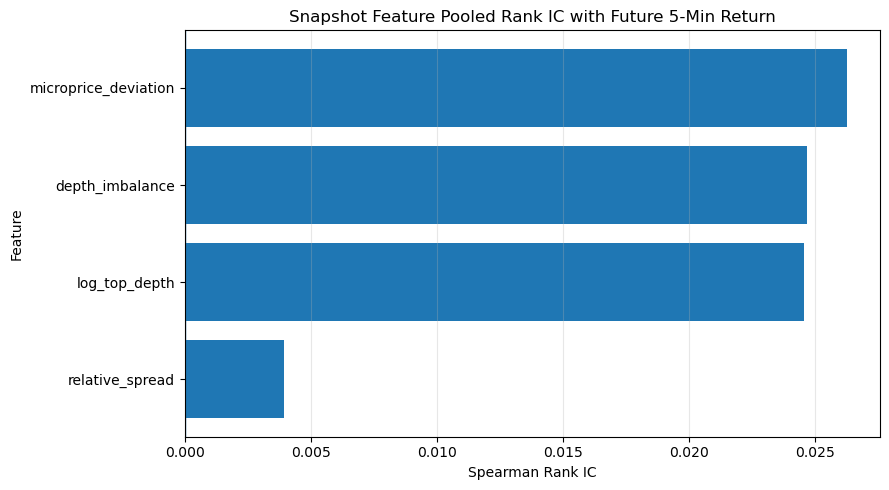

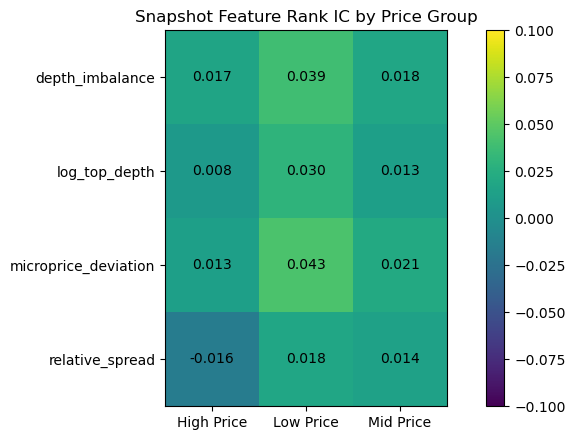

In [26]:
plot_rank_ic_bar(
    snapshot_eval["pooled_ic"],
    "Snapshot Feature Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    snapshot_eval["price_group_ic_pivot"],
    "Snapshot Feature Rank IC by Price Group"
)


### 8.2 Snapshot Feature Interpretation Template

The first feature family examines whether the contemporaneous order-book state contains information about future five-minute returns.

The snapshot features describe four dimensions of the best bid and ask:

- `relative_spread`: transaction-cost and liquidity condition;
- `log_top_depth`: total top-of-book liquidity;
- `depth_imbalance`: relative bid-versus-ask depth pressure;
- `microprice_deviation`: order-book pressure embedded in the microprice relative to the midpoint.

The objective is to distinguish whether short-horizon predictive information is primarily associated with liquidity level, trading friction, or directional order-book pressure.


#### Interim Findings: Snapshot Features and Price-Level Effects

The snapshot analysis identifies order-book pressure as the first persistent predictive mechanism in the sample.

`microprice_deviation` produces a pooled Rank IC of approximately 0.043 and a mean daily IC of 0.035, with positive IC on 81.0% of the 63 trading days. `depth_imbalance` exhibits a similar pattern, with mean daily IC of 0.033 and positive IC on 79.4% of days.

The effect is particularly concentrated in low-price stocks. Within the low-price group, mean daily IC reaches approximately 0.12 for both features, and all eight sampled low-price stocks exhibit positive stock-level IC.

The consistency across pooled, daily, price-group, and stock-level analyses suggests that the result is not driven by a single trading day or individual security.

**Predictive interpretation:** contemporaneous top-of-book pressure contains short-horizon continuation information, particularly when the return label has coarser price resolution.

In [27]:
# ============================================================
# Stock-Level IC Decomposition
# ============================================================

stock_level_features = [
    "depth_imbalance",
    "microprice_deviation"
]

stock_ic_rows = []

for code, group_df in master_feature_df.groupby("code"):

    price_group = group_df["price_group"].iloc[0]

    for feature in stock_level_features:

        sub = group_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 30
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        stock_ic_rows.append({
            "code": code,
            "price_group": price_group,
            "feature": feature,
            "rank_ic": rank_ic,
            "abs_rank_ic": abs(rank_ic),
            "n_obs": len(sub)
        })


stock_level_ic_df = pd.DataFrame(stock_ic_rows)

display(
    stock_level_ic_df
    .sort_values(
        ["feature", "rank_ic"],
        ascending=[True, False]
    )
)

,code,price_group,feature,rank_ic,abs_rank_ic,n_obs
48,600488.SH,Low Price,depth_imbalance,0.169428,0.169428,1454
44,600425.SH,Low Price,depth_imbalance,0.083607,0.083607,1595
78,688737.SH,Mid Price,depth_imbalance,0.073306,0.073306,1592
0,000713.SZ,Low Price,depth_imbalance,0.065210,0.065210,1628
42,600182.SH,Mid Price,depth_imbalance,0.057677,0.057677,1588
...,...,...,...,...,...,...
29,300595.SZ,Mid Price,microprice_deviation,-0.006461,0.006461,1636
39,301622.SZ,High Price,microprice_deviation,-0.018002,0.018002,1634
21,002553.SZ,Mid Price,microprice_deviation,-0.024043,0.024043,1638
69,688125.SH,High Price,microprice_deviation,-0.030783,0.030783,1592


In [28]:
# ============================================================
# Stock-Level IC Summary by Price Group
# ============================================================

stock_ic_summary = (
    stock_level_ic_df
    .groupby(
        [
            "price_group",
            "feature"
        ],
        observed=True
    )
    .agg(
        n_stocks=(
            "code",
            "nunique"
        ),
        mean_stock_ic=(
            "rank_ic",
            "mean"
        ),
        median_stock_ic=(
            "rank_ic",
            "median"
        ),
        stock_ic_std=(
            "rank_ic",
            "std"
        ),
        positive_stock_ratio=(
            "rank_ic",
            lambda x: (x > 0).mean()
        ),
        max_stock_ic=(
            "rank_ic",
            "max"
        ),
        min_stock_ic=(
            "rank_ic",
            "min"
        )
    )
    .reset_index()
)


display(stock_ic_summary)

,price_group,feature,n_stocks,mean_stock_ic,median_stock_ic,stock_ic_std,positive_stock_ratio,max_stock_ic,min_stock_ic
0,High Price,depth_imbalance,14,0.018921,0.032520,0.026918,0.785714,0.048590,-0.037874
1,High Price,microprice_deviation,14,0.017814,0.023916,0.029998,0.785714,0.065867,-0.036824
2,Low Price,depth_imbalance,13,0.046109,0.040427,0.044560,0.923077,0.169428,-0.001202
3,Low Price,microprice_deviation,13,0.047102,0.032984,0.045651,0.923077,0.176390,-0.000478
4,Mid Price,depth_imbalance,13,0.020339,0.017873,0.030387,0.692308,0.073306,-0.027913
5,Mid Price,microprice_deviation,13,0.021460,0.015872,0.028818,0.769231,0.080043,-0.024043


Pooled Snapshot Factor Performance

The pooled factor evaluation shows that predictive information is concentrated primarily in directional order-book pressure.

`microprice_deviation` and `depth_imbalance` remain the strongest snapshot pressure signals in the expanded sample. Both retain positive predictive directions, indicating that stronger bid-side order-book pressure is associated with higher subsequent five-minute returns.

The daily IC results provide evidence of temporal persistence across 63 trading days. `microprice_deviation` has a mean daily IC of 0.0348 and an ICIR of 0.82, while `depth_imbalance` has a mean daily IC of 0.0329 and an ICIR of 0.82. Positive daily IC ratios are 81.0% and 79.4%, respectively.

In contrast, `relative_spread` contains little pooled ranking information, while `log_top_depth` shows only modest predictive strength.

The snapshot analysis therefore suggests that the directional configuration of the order book is more informative than the absolute level of displayed liquidity or the contemporaneous bid-ask spread.

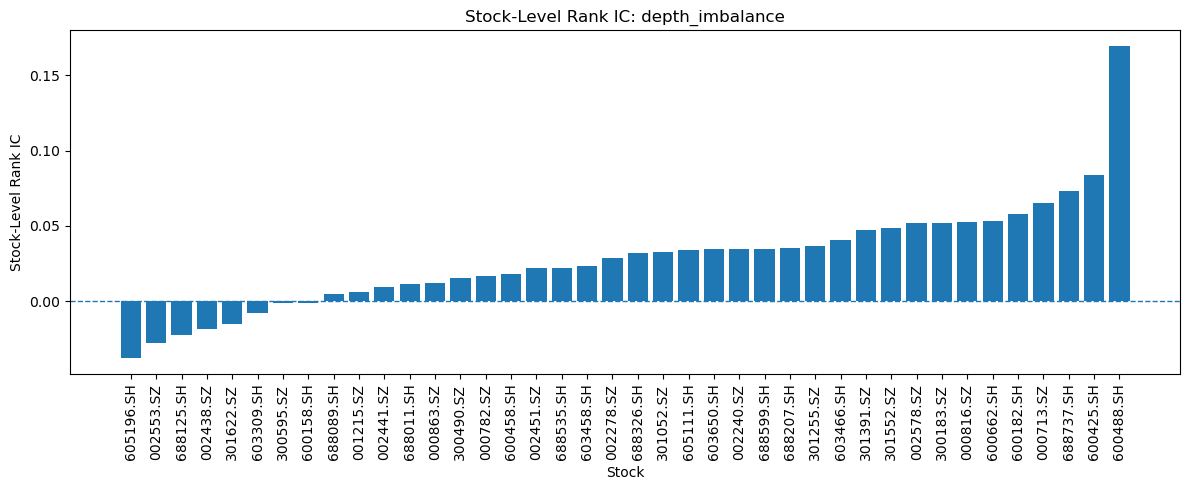

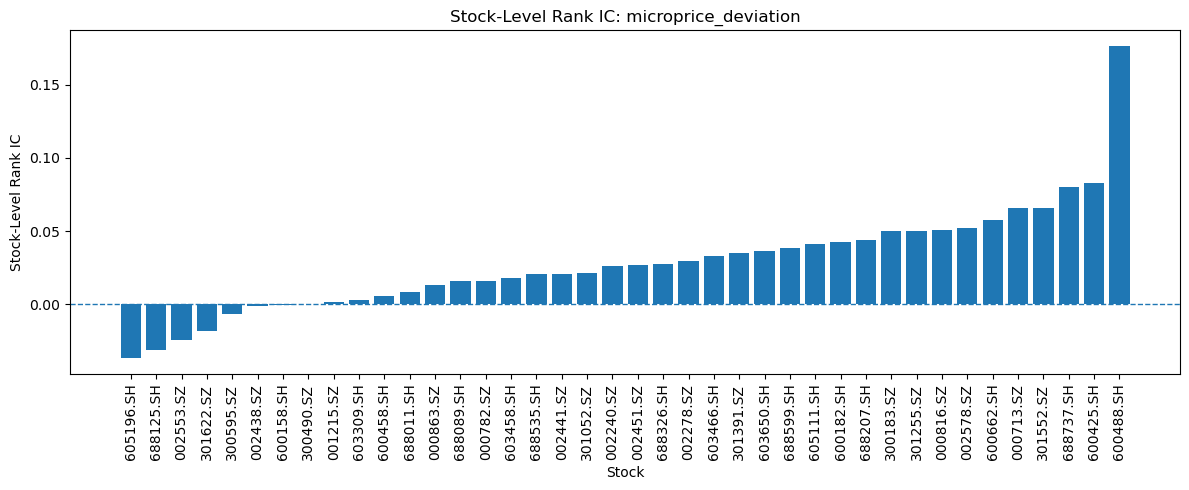

In [29]:
# ============================================================
# Stock-Level IC Distribution
# ============================================================

for feature in stock_level_features:

    plot_df = (
        stock_level_ic_df[
            stock_level_ic_df["feature"] == feature
        ]
        .sort_values("rank_ic")
        .copy()
    )

    plt.figure(figsize=(12, 5))

    x = np.arange(len(plot_df))

    plt.bar(
        x,
        plot_df["rank_ic"]
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xticks(
        x,
        plot_df["code"],
        rotation=90
    )

    plt.xlabel("Stock")
    plt.ylabel("Stock-Level Rank IC")

    plt.title(
        f"Stock-Level Rank IC: {feature}"
    )

    plt.tight_layout()
    plt.show()

The predictive strength of order-book pressure differs substantially across price groups.

For Low Price stocks, both `depth_imbalance` and `microprice_deviation` achieve Rank IC values close to 0.08. Their mean daily IC values exceed 0.11, with ICIR values above 1.3.

The corresponding pooled Rank IC values for Mid Price and High Price stocks are substantially weaker, generally between 0.01 and 0.02.

This result extends the price-level heterogeneity identified in the label diagnostics. Price level affects not only the discretization of future five-minute returns, but also the strength of the relationship between the contemporaneous order book and subsequent price movement.

One possible interpretation is that, under a larger relative tick size, displayed top-of-book pressure represents a more economically meaningful shift in the short-horizon price state. Order-book imbalance therefore appears to contain stronger directional information for low-priced stocks.

C:\Users\work\AppData\Local\Temp\ipykernel_24260\4065649081.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


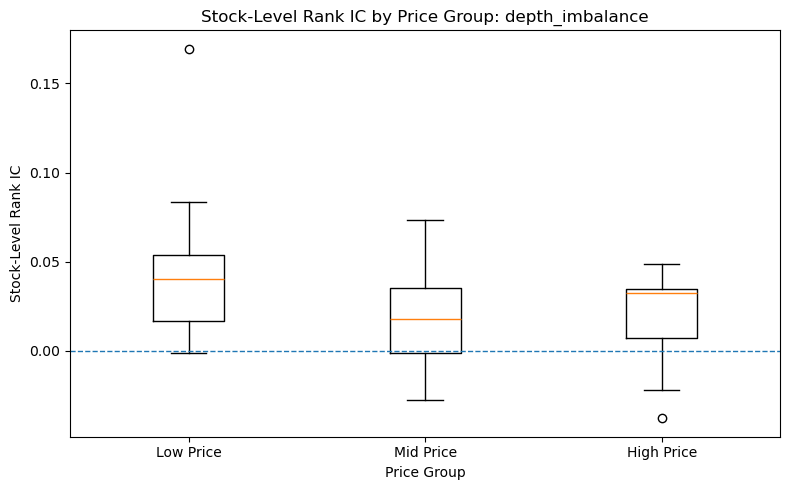

C:\Users\work\AppData\Local\Temp\ipykernel_24260\4065649081.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


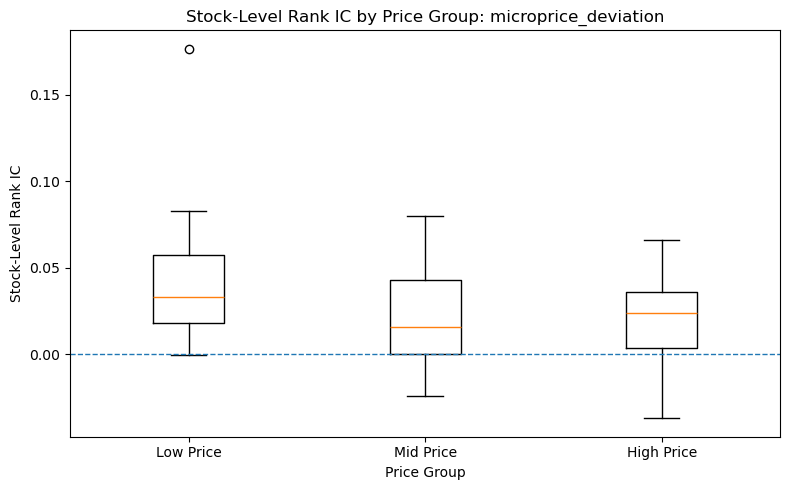

In [30]:
# ============================================================
# Stock-Level IC by Price Group
# ============================================================

for feature in stock_level_features:

    plot_df = stock_level_ic_df[
        stock_level_ic_df["feature"] == feature
    ].copy()

    price_order = [
        "Low Price",
        "Mid Price",
        "High Price"
    ]

    data = [
        plot_df.loc[
            plot_df["price_group"] == group,
            "rank_ic"
        ].dropna().values
        for group in price_order
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        data,
        labels=price_order
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Price Group")
    plt.ylabel("Stock-Level Rank IC")

    plt.title(
        f"Stock-Level Rank IC by Price Group: {feature}"
    )

    plt.tight_layout()
    plt.show()

The price-group result is further examined using stock-level Rank IC.

Within the Low Price group, all eight stocks exhibit positive Rank IC for both `depth_imbalance` and `microprice_deviation`. The mean stock-level IC is approximately 0.081 for both features, while the median IC is also close to 0.08.

The similarity between the mean and median stock-level IC, together with a 100% positive-stock ratio, indicates that the stronger Low Price signal is broad-based across the sampled stocks rather than being driven by a small number of extreme observations.

Mid Price and High Price stocks exhibit substantially greater cross-stock variation, including negative stock-level IC for several securities.

The evidence therefore suggests that order-book pressure is a particularly stable short-horizon signal within the Low Price subgroup.

#### Stock-Level IC Decomposition

Unsigned trading activity provides limited standalone directional information.

Five-minute turnover produces the strongest pooled Rank IC within the family at approximately 0.021, but its daily IC is weak and unstable. Volume and turnover variables generally exhibit low ICIR values and inconsistent daily directions.

The result suggests that trading intensity alone does not determine the direction of the next five-minute return.

**Predictive implication:** activity measures may describe the strength of the market state, but directional information requires either signed trading pressure, recent price movement, or contemporaneous order-book conditions.

## 9. Trade Activity Features

The second feature family examines whether recent trading activity contains directional information about future five-minute returns.

Unlike the snapshot order-book features, trade activity variables primarily measure the magnitude of recent market participation rather than the direction of buying or selling pressure.

The evaluated features include rolling trading volume, turnover, five-minute trading intensity, and volume acceleration across multiple lookback horizons.

This section therefore asks whether unusually active trading alone is sufficient to rank subsequent short-horizon returns.


In [31]:
trade_base = minute_panel.copy()
trade_base = trade_base.sort_values(["code", "date", "minute"]).reset_index(drop=True)

group_keys = ["code", "date"]

trade_base["minute_volume"] = trade_base.groupby(group_keys)["sum_volume"].diff()
trade_base["minute_turnover"] = trade_base.groupby(group_keys)["sum_amount"].diff()

display(
    trade_base[[
        "code", "date", "minute", "sum_volume", "minute_volume",
        "sum_amount", "minute_turnover"
    ]].head(10)
)

display(trade_base[["minute_volume", "minute_turnover"]].describe().T)


,code,date,minute,sum_volume,minute_volume,sum_amount,minute_turnover
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,222800,NaN,1478169.0,NaN
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,394100,171300.0,2615055.0,1136886.0
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,571100,177000.0,3788036.0,1172981.0
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,614800,43700.0,4077336.0,289300.0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,652200,37400.0,4325279.0,247943.0
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,726100,73900.0,4815320.0,490041.0
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,759300,33200.0,5035467.0,220147.0
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,816800,57500.0,5416732.0,381265.0
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,879300,62500.0,5830629.0,413897.0
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,906500,27200.0,6010752.0,180123.0


,count,mean,std,min,25%,50%,75%,max
minute_volume,74614.0,2.207146e+05,5.731134e+05,0.0,19900.0,69041.0,212060.75,24733800.0
minute_turnover,74614.0,3.609484e+06,7.999968e+06,0.0,454353.5,1259709.5,3465025.75,298430130.0


In [32]:
trade_base["volume_1m"] = trade_base["minute_volume"]
trade_base["turnover_1m"] = trade_base["minute_turnover"]

for window in [3, 5]:
    trade_base[f"volume_{window}m"] = (
        trade_base
        .groupby(group_keys)["minute_volume"]
        .transform(lambda x: x.rolling(window=window, min_periods=window).sum())
    )
    trade_base[f"turnover_{window}m"] = (
        trade_base
        .groupby(group_keys)["minute_turnover"]
        .transform(lambda x: x.rolling(window=window, min_periods=window).sum())
    )

trade_base["trade_intensity_5m"] = trade_base["volume_5m"] / 5

trade_base["previous_volume_3m"] = (
    trade_base
    .groupby(group_keys)["minute_volume"]
    .transform(lambda x: x.shift(3).rolling(window=3, min_periods=3).sum())
)

trade_base["volume_acceleration"] = (
    (trade_base["volume_3m"] - trade_base["previous_volume_3m"])
    / (trade_base["previous_volume_3m"].abs() + 1)
)

display(
    trade_base[[
        "code", "date", "minute", "minute_volume", "volume_3m",
        "previous_volume_3m", "volume_acceleration", "trade_intensity_5m"
    ]].head(15)
)


,code,date,minute,minute_volume,volume_3m,previous_volume_3m,volume_acceleration,trade_intensity_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,NaN,NaN,NaN,NaN,NaN
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,171300.0,NaN,NaN,NaN,NaN
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,177000.0,NaN,NaN,NaN,NaN
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,43700.0,392000.0,NaN,NaN,NaN
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,37400.0,258100.0,NaN,NaN,NaN
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,73900.0,155000.0,NaN,NaN,100660.0
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,33200.0,144500.0,392000.0,-0.631376,73040.0
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,57500.0,164600.0,258100.0,-0.362261,49140.0
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,62500.0,153200.0,155000.0,-0.011613,52900.0
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,27200.0,147200.0,144500.0,0.018685,50860.0


In [33]:
trade_candidate_features = [
    "volume_1m",
    "volume_3m",
    "volume_5m",
    "turnover_1m",
    "turnover_3m",
    "turnover_5m",
    "trade_intensity_5m",
    "volume_acceleration"
]

trade_feature_cols = ["code", "date", "minute"] + trade_candidate_features

master_feature_df = master_feature_df.merge(
    trade_base[trade_feature_cols],
    on=["code", "date", "minute"],
    how="left"
)

print("master_feature_df shape:", master_feature_df.shape)
display(
    master_feature_df[["code", "date", "minute", "price_group"] + trade_candidate_features + ["future_return_5m"]].head(12)
)


master_feature_df shape: (64039, 42)


,code,date,minute,price_group,volume_1m,volume_3m,volume_5m,turnover_1m,turnover_3m,turnover_5m,trade_intensity_5m,volume_acceleration,future_return_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,Low Price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001509
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,Low Price,171300.0,NaN,NaN,1136886.0,NaN,NaN,NaN,NaN,-0.001505
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,Low Price,177000.0,NaN,NaN,1172981.0,NaN,NaN,NaN,NaN,0.001512
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,Low Price,43700.0,392000.0,NaN,289300.0,2599167.0,NaN,NaN,NaN,0.000000
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,Low Price,37400.0,258100.0,NaN,247943.0,1710224.0,NaN,NaN,NaN,0.000000
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,Low Price,73900.0,155000.0,503300.0,490041.0,1027284.0,3337151.0,100660.0,NaN,-0.001507
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,Low Price,33200.0,144500.0,365200.0,220147.0,958131.0,2420412.0,73040.0,-0.631376,-0.001507
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,Low Price,57500.0,164600.0,245700.0,381265.0,1091453.0,1628696.0,49140.0,-0.362261,0.000000
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,Low Price,62500.0,153200.0,264500.0,413897.0,1015309.0,1753293.0,52900.0,-0.011613,0.000000
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,Low Price,27200.0,147200.0,254300.0,180123.0,975285.0,1685473.0,50860.0,0.018685,0.000000


In [34]:
display(master_feature_df[trade_candidate_features].describe().T)

display(
    master_feature_df[trade_candidate_features]
    .isna()
    .mean()
    .rename("missing_rate")
    .to_frame()
)


,count,mean,std,min,25%,50%,75%,max
volume_1m,61533.0,2.356753e+05,5.797320e+05,0.000000,2.334300e+04,7.830000e+04,2.335000e+05,2.429910e+07
volume_3m,56528.0,6.882981e+05,1.515694e+06,1100.000000,8.080000e+04,2.552475e+05,7.118002e+05,4.447255e+07
volume_5m,51523.0,1.129387e+06,2.362042e+06,4400.000000,1.410930e+05,4.361260e+05,1.199500e+06,5.966305e+07
turnover_1m,61533.0,3.888251e+06,8.198982e+06,0.000000,5.316290e+05,1.410958e+06,3.797415e+06,2.834957e+08
turnover_3m,56528.0,1.139979e+07,2.219109e+07,15694.000000,1.871273e+06,4.453169e+06,1.128250e+07,4.986073e+08
turnover_5m,51523.0,1.873891e+07,3.499514e+07,89686.000000,3.280104e+06,7.493516e+06,1.880415e+07,6.583762e+08
trade_intensity_5m,51523.0,2.258774e+05,4.724084e+05,880.000000,2.821860e+04,8.722520e+04,2.399000e+05,1.193261e+07
volume_acceleration,49022.0,7.392297e-02,9.814636e-01,-0.983785,-3.882705e-01,-1.298479e-01,2.575932e-01,5.291005e+01


,missing_rate
volume_1m,0.039132
volume_3m,0.117288
volume_5m,0.195443
turnover_1m,0.039132
turnover_3m,0.117288
turnover_5m,0.195443
trade_intensity_5m,0.195443
volume_acceleration,0.234498


#### Rolling Activity Feature Construction

Trading activity is aggregated over one-, three-, and five-minute rolling windows.

Volume measures capture the number of shares traded, while turnover measures the economic value of recent trading activity. `trade_intensity_5m` summarizes average activity over the five-minute window, and `volume_acceleration` compares recent trading activity with its preceding level.

The missing observations in the rolling features are primarily structural. Longer lookback windows require sufficient historical observations at the beginning of each stock-day sequence. The higher missing rate of `volume_acceleration` additionally reflects its lagged-window construction.

These observations are therefore excluded from factor evaluation rather than interpreted as data-quality failures.

### 9.1 Trade Activity Feature Evaluation

Trade activity features are also evaluated using the same parallel framework:

- Pooled IC
- Daily IC stability
- Price-group IC
- Price-group daily IC stability


In [35]:
trade_eval = evaluate_feature_family(
    master_feature_df,
    trade_candidate_features,
    family_name="Trade Activity"
)

print("Pooled IC:")
display(trade_eval["pooled_ic"])

print("Daily IC Summary:")
display(trade_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(trade_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(trade_eval["price_group_daily_summary"])


Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Trade Activity,turnover_3m,-0.040909,-0.035642,0.035642,56528,Negative
1,Trade Activity,turnover_5m,-0.040182,-0.033484,0.033484,51523,Negative
2,Trade Activity,turnover_1m,-0.031023,-0.033116,0.033116,61533,Negative
3,Trade Activity,volume_acceleration,-0.018513,-0.014955,0.014955,49022,Negative
4,Trade Activity,volume_1m,-0.028542,-0.014141,0.014141,61533,Negative
5,Trade Activity,volume_3m,-0.036029,-0.013625,0.013625,56528,Negative
6,Trade Activity,volume_5m,-0.030617,-0.012082,0.012082,51523,Negative
7,Trade Activity,trade_intensity_5m,-0.030617,-0.012082,0.012082,51523,Negative


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
turnover_3m,-0.024316,0.081041,0.476190,63,-0.300044,0.024316
turnover_5m,-0.022928,0.083776,0.460317,63,-0.273677,0.022928
turnover_1m,-0.021248,0.074486,0.507937,63,-0.285257,0.021248
volume_acceleration,-0.006948,0.055241,0.492063,63,-0.125773,0.006948
volume_3m,-0.005206,0.077209,0.492063,63,-0.067428,0.005206
volume_1m,-0.004977,0.070006,0.476190,63,-0.071089,0.004977
trade_intensity_5m,-0.004344,0.085725,0.492063,63,-0.050670,0.004344
volume_5m,-0.004344,0.085725,0.492063,63,-0.050670,0.004344


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
trade_intensity_5m,-0.019305,-0.031596,-0.032303
turnover_1m,-0.019762,-0.037184,-0.039720
turnover_3m,-0.023346,-0.038789,-0.041134
turnover_5m,-0.020384,-0.040398,-0.037151
volume_1m,-0.016541,-0.031103,-0.035609
volume_3m,-0.020176,-0.030898,-0.036607
volume_5m,-0.019305,-0.031596,-0.032303
volume_acceleration,-0.017457,-0.008008,-0.019501


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,trade_intensity_5m,-0.014070,0.108964,0.476190,63,-0.129129
1,High Price,turnover_1m,-0.009103,0.096654,0.539683,63,-0.094177
2,High Price,turnover_3m,-0.011472,0.104271,0.555556,63,-0.110026
3,High Price,turnover_5m,-0.008268,0.112130,0.492063,63,-0.073736
4,High Price,volume_1m,-0.007906,0.093158,0.507937,63,-0.084861
5,High Price,volume_3m,-0.011740,0.101170,0.523810,63,-0.116041
6,High Price,volume_5m,-0.014070,0.108964,0.476190,63,-0.129129
7,High Price,volume_acceleration,-0.011220,0.077553,0.492063,63,-0.144677
8,Low Price,trade_intensity_5m,-0.021819,0.107663,0.444444,63,-0.202664
9,Low Price,turnover_1m,-0.023258,0.093022,0.412698,63,-0.250029


#### Single-Factor Performance

Raw trading activity exhibits substantially weaker directional predictive power than the order-book pressure signals identified in the previous section.

Among the activity-level features, `turnover_5m` produces the strongest positive pooled Rank IC of 0.0211. Three- and five-minute volume and turnover measures generally show small positive Rank IC values between approximately 0.01 and 0.02.

One-minute activity measures contain almost no ranking information, suggesting that very short trading bursts are dominated by noise. Activity accumulated over three to five minutes appears marginally more informative.

`volume_acceleration` is the strongest activity feature in absolute Rank IC, with a value of -0.0268. The negative direction suggests a possible short-horizon reversal or activity-exhaustion effect. However, its low ICIR and limited daily direction consistency indicate that the relationship is not sufficiently stable to be treated as a standalone predictive factor.

Overall, recent trading activity appears to describe the intensity of the market state more effectively than the direction of future returns.

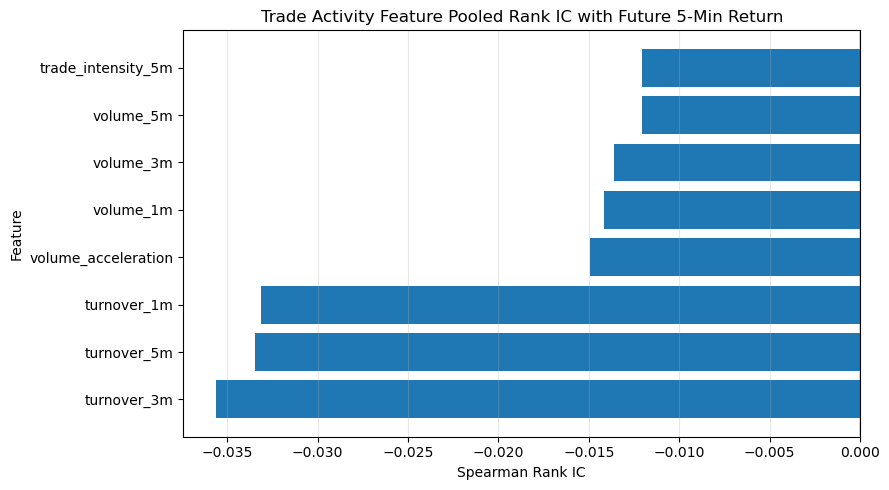

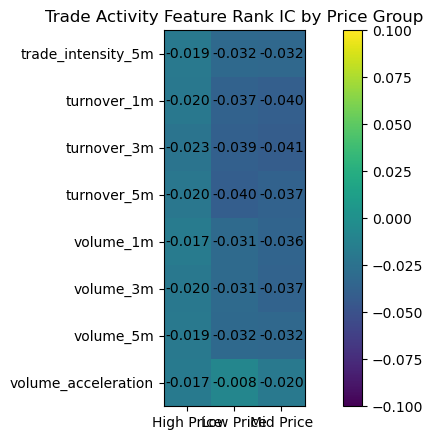

In [36]:
plot_rank_ic_bar(
    trade_eval["pooled_ic"],
    "Trade Activity Feature Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    trade_eval["price_group_ic_pivot"],
    "Trade Activity Feature Rank IC by Price Group"
)


#### Interim Findings: Trade Activity Features

The trade activity analysis indicates that unsigned volume and turnover measures are weak standalone directional predictors.

Higher trading activity identifies periods of greater market participation, but does not distinguish whether the underlying pressure originates from aggressive buying or aggressive selling.

This limitation motivates the next feature family. Signed trade-pressure variables are introduced to combine recent trading activity with an estimated direction of trade initiation.

The analysis therefore moves from measuring:

> **How much trading occurred?**

to:

> **In which direction did the recent trading pressure occur?**

## 10. Signed Trading Pressure Features

### Research Motivation
同样的成交量
→ 是buy-dominated还是sell-dominated

Raw trading activity measures how much trading occurs, but it does not identify which side of the market is driving the activity.

For example, high trading volume may result from aggressive buying, aggressive selling, or intense two-sided trading. Therefore, volume alone contains limited information about the direction of future price movements.

Signed trading pressure introduces a directional component into trading activity:

```text
Buyer-side pressure  → Positive
Seller-side pressure → Negative

Last Price ≥ Best Ask
→ Buyer-pressure proxy (+1)

Last Price ≤ Best Bid
→ Seller-pressure proxy (-1)

Inside the spread
→ Ambiguous pressure (0)

In [37]:
if "minute_volume" not in master_feature_df.columns:
    master_feature_df = master_feature_df.merge(
        trade_base[
            [
                "code",
                "date",
                "minute",
                "minute_volume",
                "volume_1m",
                "volume_3m",
                "volume_5m",
                "turnover_1m",
                "turnover_3m",
                "turnover_5m",
                "volume_acceleration"
            ]
        ],
        on=["code", "date", "minute"],
        how="left"
    )

In [38]:
# ============================================================
# Signed Trading Pressure Features
# ============================================================

# Start from master feature table
# master_feature_df should already contain:
# code, date, minute, mid_price, bp0, ap0, last_price,
# minute_volume, future_return_5m, price_group

master_feature_df = master_feature_df.sort_values(
    ["code", "date", "minute"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Trade sign proxy
#
# +1: last price at or above ask -> buyer-initiated proxy
# -1: last price at or below bid -> seller-initiated proxy
#  0: ambiguous / inside spread
# ------------------------------------------------------------

master_feature_df["trade_sign_proxy"] = np.select(
    [
        master_feature_df["last_price"] >= master_feature_df["ap0"],
        master_feature_df["last_price"] <= master_feature_df["bp0"]
    ],
    [
        1,
        -1
    ],
    default=0
)


# ------------------------------------------------------------
# Signed minute volume
# ------------------------------------------------------------

master_feature_df["signed_volume_1m"] = (
    master_feature_df["trade_sign_proxy"]
    * master_feature_df["minute_volume"]
)


display(
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "last_price",
            "bp0",
            "ap0",
            "trade_sign_proxy",
            "minute_volume",
            "signed_volume_1m"
        ]
    ].head(15)
)

,code,date,minute,last_price,bp0,ap0,trade_sign_proxy,minute_volume,signed_volume_1m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.63,6.62,6.63,1,NaN,NaN
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,6.64,6.64,6.65,-1,171300.0,-171300.0
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,6.62,6.61,6.62,1,177000.0,177000.0
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,6.63,6.62,6.63,1,43700.0,43700.0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,6.63,6.62,6.63,1,37400.0,37400.0
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,6.63,6.63,6.64,-1,73900.0,-73900.0
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,6.63,6.63,6.64,-1,33200.0,-33200.0
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,6.63,6.62,6.63,1,57500.0,57500.0
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,6.62,6.62,6.63,-1,62500.0,-62500.0
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,6.63,6.62,6.63,1,27200.0,27200.0


In [39]:
# ============================================================
# Rolling Signed Trading Pressure
# ============================================================

group_keys = ["code", "date"]

for window in [3, 5]:

    master_feature_df[f"signed_volume_{window}m"] = (
        master_feature_df
        .groupby(group_keys)["signed_volume_1m"]
        .transform(
            lambda x: x.rolling(
                window=window,
                min_periods=window
            ).sum()
        )
    )

    master_feature_df[f"abs_volume_{window}m"] = (
        master_feature_df
        .groupby(group_keys)["minute_volume"]
        .transform(
            lambda x: x.rolling(
                window=window,
                min_periods=window
            ).sum()
        )
    )


# ------------------------------------------------------------
# Signed volume imbalance ratios
# ------------------------------------------------------------

master_feature_df["signed_volume_imbalance_1m"] = (
    master_feature_df["signed_volume_1m"]
    / (
        master_feature_df["minute_volume"].abs()
        + 1
    )
)

for window in [3, 5]:

    master_feature_df[f"signed_volume_imbalance_{window}m"] = (
        master_feature_df[f"signed_volume_{window}m"]
        / (
            master_feature_df[f"abs_volume_{window}m"].abs()
            + 1
        )
    )


signed_pressure_features = [
    "trade_sign_proxy",
    "signed_volume_1m",
    "signed_volume_3m",
    "signed_volume_5m",
    "signed_volume_imbalance_1m",
    "signed_volume_imbalance_3m",
    "signed_volume_imbalance_5m"
]


display(
    master_feature_df[
        [
            "code",
            "date",
            "minute"
        ]
        + signed_pressure_features
        + [
            "future_return_5m",
            "price_group"
        ]
    ].head(15)
)

,code,date,minute,trade_sign_proxy,signed_volume_1m,signed_volume_3m,signed_volume_5m,signed_volume_imbalance_1m,signed_volume_imbalance_3m,signed_volume_imbalance_5m,future_return_5m,price_group
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,1,NaN,NaN,NaN,NaN,NaN,NaN,0.001509,Low Price
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,-1,-171300.0,NaN,NaN,-0.999994,NaN,NaN,-0.001505,Low Price
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,1,177000.0,NaN,NaN,0.999994,NaN,NaN,0.001512,Low Price
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,1,43700.0,49400.0,NaN,0.999977,0.126020,NaN,0.000000,Low Price
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,1,37400.0,258100.0,NaN,0.999973,0.999996,NaN,0.000000,Low Price
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,-1,-73900.0,7200.0,12900.0,-0.999986,0.046451,0.025631,-0.001507,Low Price
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,-1,-33200.0,-69700.0,151000.0,-0.999970,-0.482350,0.413471,-0.001507,Low Price
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,1,57500.0,-49600.0,31500.0,0.999983,-0.301335,0.128205,0.000000,Low Price
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,-1,-62500.0,-38200.0,-74700.0,-0.999984,-0.249346,-0.282419,0.000000,Low Price
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,1,27200.0,22200.0,-84900.0,0.999963,0.150814,-0.333856,0.000000,Low Price


`trade_sign_proxy` classifies the current trading state as buy-dominated, sell-dominated, or neutral using the relationship between the observed trade price and the best bid and ask.

Rolling signed-volume features aggregate recent trading activity after weighting volume by the estimated trade direction. Signed-volume imbalance normalizes directional volume by total activity and therefore measures the relative dominance of buy- versus sell-initiated trading.

The rolling features exhibit the same structural missingness as the trade-activity variables. Longer windows require more historical observations at the beginning of each stock-day sequence. These missing values reflect feature initialization rather than data-quality failures.

In [40]:
# ============================================================
# Signed Pressure Feature Diagnostics
# ============================================================

display(
    master_feature_df[
        signed_pressure_features
    ].describe().T
)

display(
    master_feature_df[
        signed_pressure_features
    ]
    .isna()
    .mean()
    .rename("missing_rate")
    .to_frame()
)

,count,mean,std,min,25%,50%,75%,max
trade_sign_proxy,64039.0,0.005622,9.592397e-01,-1.0,-1.000000,0.000000,1.000000,1.0
signed_volume_1m,61533.0,5810.620204,6.187029e+05,-24299100.0,-68200.000000,0.000000,74100.000000,20647150.0
signed_volume_3m,56518.0,16360.004246,1.066716e+06,-37800168.0,-95600.000000,1307.000000,109876.500000,37817900.0
signed_volume_5m,51505.0,24026.645316,1.399149e+06,-51290202.0,-122400.000000,2016.000000,142956.000000,54565500.0
signed_volume_imbalance_1m,61533.0,0.006727,9.584117e-01,-1.0,-0.999985,0.000000,0.999987,1.0
signed_volume_imbalance_3m,56518.0,0.009464,6.182341e-01,-1.0,-0.474947,0.017566,0.492730,1.0
signed_volume_imbalance_5m,51505.0,0.008548,5.029305e-01,-1.0,-0.364704,0.014888,0.385858,1.0


,missing_rate
trade_sign_proxy,0.000000
signed_volume_1m,0.039132
signed_volume_3m,0.117444
signed_volume_5m,0.195724
signed_volume_imbalance_1m,0.039132
signed_volume_imbalance_3m,0.117444
signed_volume_imbalance_5m,0.195724


In [41]:
# ============================================================
# Pooled IC: Signed Trading Pressure Features
# ============================================================

signed_pooled_rows = []

for feature in signed_pressure_features:

    sub = master_feature_df[
        [
            feature,
            "future_return_5m"
        ]
    ].dropna()

    if (
        len(sub) < 20
        or sub[feature].nunique() < 2
        or sub["future_return_5m"].nunique() < 2
    ):
        continue

    pearson_ic = sub[feature].corr(
        sub["future_return_5m"],
        method="pearson"
    )

    rank_ic = sub[feature].corr(
        sub["future_return_5m"],
        method="spearman"
    )

    signed_pooled_rows.append({
        "family": "Signed Trading Pressure",
        "feature": feature,
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "abs_rank_ic": abs(rank_ic),
        "n_obs": len(sub),
        "signal_direction": (
            "Positive"
            if rank_ic > 0
            else "Negative"
        )
    })


signed_pooled_ic = (
    pd.DataFrame(signed_pooled_rows)
    .sort_values(
        "abs_rank_ic",
        ascending=False
    )
    .reset_index(drop=True)
)

display(signed_pooled_ic)

,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Signed Trading Pressure,trade_sign_proxy,0.015502,0.019603,0.019603,64039,Positive
1,Signed Trading Pressure,signed_volume_1m,-0.005784,0.017307,0.017307,61533,Positive
2,Signed Trading Pressure,signed_volume_imbalance_1m,0.018375,0.017307,0.017307,61533,Positive
3,Signed Trading Pressure,signed_volume_imbalance_3m,0.011651,0.012639,0.012639,56518,Positive
4,Signed Trading Pressure,signed_volume_imbalance_5m,0.010913,0.011393,0.011393,51505,Positive
5,Signed Trading Pressure,signed_volume_3m,-0.013937,0.009986,0.009986,56518,Positive
6,Signed Trading Pressure,signed_volume_5m,-0.010437,0.007605,0.007605,51505,Positive


Adding directional information improves the predictive content of recent trading activity.

The strongest pooled signed-pressure signal is `signed_volume_3m`, with a Rank IC of 0.0320. `trade_sign_proxy`, `signed_volume_1m`, and `signed_volume_imbalance_1m` also produce positive Rank IC values close to 0.028.

These values are generally stronger than the unsigned volume and turnover signals evaluated in the previous section. This indicates that the direction of recent trading pressure contains incremental information beyond trading intensity alone.

However, pooled IC does not fully describe temporal stability. `trade_sign_proxy` provides the most balanced result, with a mean daily IC of 0.0180, a positive daily-IC ratio of 68.2%, and complete sample coverage.

In contrast, the higher pooled IC of `signed_volume_3m` is not matched by stable daily performance.

In [42]:
# ============================================================
# Daily IC: Signed Trading Pressure Features
# ============================================================

signed_daily_rows = []

for date, date_df in master_feature_df.groupby("date"):

    for feature in signed_pressure_features:

        sub = date_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 20
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        signed_daily_rows.append({
            "date": date,
            "feature": feature,
            "rank_ic": rank_ic
        })


signed_daily_ic = pd.DataFrame(signed_daily_rows)

signed_daily_ic_summary = (
    signed_daily_ic
    .groupby("feature")
    .agg(
        mean_daily_ic=("rank_ic", "mean"),
        ic_std=("rank_ic", "std"),
        positive_ic_ratio=(
            "rank_ic",
            lambda x: (x > 0).mean()
        ),
        n_days=("rank_ic", "count")
    )
)

signed_daily_ic_summary["icir"] = (
    signed_daily_ic_summary["mean_daily_ic"]
    / signed_daily_ic_summary["ic_std"]
)

signed_daily_ic_summary["abs_mean_daily_ic"] = (
    signed_daily_ic_summary["mean_daily_ic"].abs()
)

signed_daily_ic_summary = (
    signed_daily_ic_summary
    .sort_values(
        "abs_mean_daily_ic",
        ascending=False
    )
)

display(signed_daily_ic_summary)

,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
trade_sign_proxy,0.015044,0.029525,0.682540,63,0.509556,0.015044
signed_volume_1m,0.013650,0.034510,0.619048,63,0.395545,0.013650
signed_volume_imbalance_1m,0.013650,0.034510,0.619048,63,0.395545,0.013650
signed_volume_imbalance_3m,0.005683,0.048364,0.571429,63,0.117498,0.005683
signed_volume_3m,0.004417,0.044921,0.619048,63,0.098332,0.004417
signed_volume_imbalance_5m,0.002592,0.059671,0.539683,63,0.043434,0.002592
signed_volume_5m,0.000826,0.058089,0.555556,63,0.014213,0.000826


In [43]:
# ============================================================
# Price-Group IC: Signed Trading Pressure Features
# ============================================================

signed_price_group_rows = []

for price_group, group_df in master_feature_df.groupby(
    "price_group",
    observed=True
):

    for feature in signed_pressure_features:

        sub = group_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 20
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        signed_price_group_rows.append({
            "price_group": price_group,
            "feature": feature,
            "rank_ic": rank_ic,
            "abs_rank_ic": abs(rank_ic),
            "n_obs": len(sub)
        })


signed_price_group_ic = pd.DataFrame(
    signed_price_group_rows
)

signed_price_group_rank_ic = (
    signed_price_group_ic
    .pivot(
        index="feature",
        columns="price_group",
        values="rank_ic"
    )
)

display(signed_price_group_rank_ic)

price_group,High Price,Low Price,Mid Price
feature,,,
signed_volume_1m,0.011244,0.022977,0.016290
signed_volume_3m,0.011581,0.008355,0.012218
signed_volume_5m,0.003390,0.005163,0.015078
signed_volume_imbalance_1m,0.011244,0.022977,0.016290
signed_volume_imbalance_3m,0.010413,0.011044,0.018327
signed_volume_imbalance_5m,0.009431,0.009026,0.017660
trade_sign_proxy,0.012685,0.026828,0.020989


In [44]:
# ============================================================
# Price-Group Daily IC: Signed Trading Pressure Features
# ============================================================

signed_pg_daily_rows = []

for (price_group, date), group_df in master_feature_df.groupby(
    [
        "price_group",
        "date"
    ],
    observed=True
):

    for feature in signed_pressure_features:

        sub = group_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 10
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        signed_pg_daily_rows.append({
            "price_group": price_group,
            "date": date,
            "feature": feature,
            "rank_ic": rank_ic
        })


signed_pg_daily_ic = pd.DataFrame(
    signed_pg_daily_rows
)

signed_pg_daily_ic_summary = (
    signed_pg_daily_ic
    .groupby(
        [
            "price_group",
            "feature"
        ],
        observed=True
    )
    .agg(
        mean_daily_ic=("rank_ic", "mean"),
        ic_std=("rank_ic", "std"),
        positive_ic_ratio=(
            "rank_ic",
            lambda x: (x > 0).mean()
        ),
        n_days=("rank_ic", "count")
    )
    .reset_index()
)

signed_pg_daily_ic_summary["icir"] = (
    signed_pg_daily_ic_summary["mean_daily_ic"]
    / signed_pg_daily_ic_summary["ic_std"]
)

display(signed_pg_daily_ic_summary)

,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,signed_volume_1m,0.007825,0.052988,0.619048,63,0.147678
1,High Price,signed_volume_3m,0.005658,0.077704,0.571429,63,0.072813
2,High Price,signed_volume_5m,-0.001140,0.107277,0.444444,63,-0.010628
3,High Price,signed_volume_imbalance_1m,0.007825,0.052988,0.619048,63,0.147678
4,High Price,signed_volume_imbalance_3m,0.004861,0.082176,0.587302,63,0.059157
5,High Price,signed_volume_imbalance_5m,0.000873,0.107429,0.523810,63,0.008123
6,High Price,trade_sign_proxy,0.009521,0.046626,0.603175,63,0.204205
7,Low Price,signed_volume_1m,0.017950,0.071432,0.634921,63,0.251293
8,Low Price,signed_volume_3m,0.000159,0.092368,0.507937,63,0.001722
9,Low Price,signed_volume_5m,-0.004868,0.108870,0.444444,63,-0.044711


#### Signed Trading Pressure Findings

Signed trading variables provide stronger directional information than unsigned activity measures, but their stability remains moderate.

`trade_sign_proxy` is the most persistent feature in the family, with positive daily IC on approximately 68% of trading days. The signal is stronger among low-price stocks.

Several signed-volume variables exhibit similar pooled IC but weaker daily stability. Later redundancy analysis also shows that the one-minute signed-volume measures contain highly overlapping rank information.

**Predictive implication:** executed trade direction contributes a distinct information channel, but a parsimonious representative signal is preferable to including multiple highly correlated signed-flow variables.

### 11. Price Momentum Features

Price momentum features describe the recent direction of price movement before time \(t\).

This feature family asks:

> Does recent price movement contain information about the next 5-minute return?

Three backward-looking return windows are constructed:

| Feature | Definition | Interpretation |
|---|---|---|
| `return_1m` | Mid-price return over the previous 1 minute | Very short-term price movement |
| `return_3m` | Mid-price return over the previous 3 minutes | Short-term price trend |
| `return_5m` | Mid-price return over the previous 5 minutes | Medium short-horizon momentum |

All momentum features use only information observable at or before time \(t\).

The main empirical question is whether recent price movements exhibit:

- **Momentum**: positive past returns predict positive future returns.
- **Reversal**: positive past returns predict negative future returns.

The analysis continues to distinguish Low-, Mid-, and High-Price stocks because tick-size discreteness may affect short-horizon return dynamics.

In [45]:
# ============================================================
# Price Momentum Features
# ============================================================

master_feature_df = (
    master_feature_df
    .sort_values(["code", "date", "minute"])
    .reset_index(drop=True)
)

group_keys = ["code", "date"]

for window in [1, 3, 5]:
    master_feature_df[f"return_{window}m"] = (
        master_feature_df["mid_price"]
        / master_feature_df.groupby(group_keys)["mid_price"].shift(window)
        - 1
    )

momentum_candidate_features = [
    "return_1m",
    "return_3m",
    "return_5m"
]

display(
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "mid_price",
            "price_group"
        ]
        + momentum_candidate_features
        + ["future_return_5m"]
    ].head(15)
)

,code,date,minute,mid_price,price_group,return_1m,return_3m,return_5m,future_return_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.625,Low Price,NaN,NaN,NaN,0.001509
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,6.645,Low Price,0.003019,NaN,NaN,-0.001505
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,6.615,Low Price,-0.004515,NaN,NaN,0.001512
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,6.625,Low Price,0.001512,0.000000,NaN,0.000000
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,6.625,Low Price,0.000000,-0.003010,NaN,0.000000
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,6.635,Low Price,0.001509,0.003023,0.001509,-0.001507
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,6.635,Low Price,0.000000,0.001509,-0.001505,-0.001507
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,6.625,Low Price,-0.001507,0.000000,0.001512,0.000000
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,6.625,Low Price,0.000000,-0.001507,0.000000,0.000000
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,6.625,Low Price,0.000000,-0.001507,0.000000,0.000000


In [46]:
# ============================================================
# Momentum Feature Diagnostics
# ============================================================

display(
    master_feature_df[
        momentum_candidate_features
    ].describe().T
)

momentum_missing = (
    master_feature_df[
        momentum_candidate_features
    ]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)

display(momentum_missing)

,count,mean,std,min,25%,50%,75%,max
return_1m,61529.0,0.000006,0.003627,-0.044923,-0.001726,0.0,0.001543,0.057623
return_3m,56515.0,-0.000002,0.005918,-0.068986,-0.002795,0.0,0.002463,0.069482
return_5m,51502.0,0.000010,0.007416,-0.059723,-0.003570,0.0,0.003256,0.086697


,missing_rate
return_5m,0.195771
return_3m,0.117491
return_1m,0.039195


Momentum features are evaluated using the same parallel IC framework as the previous feature families:

1. Pooled IC
2. Daily IC stability
3. Price-group IC
4. Price-group daily IC stability

The sign of Rank IC provides a direct interpretation:

```text
Positive Rank IC
→ Higher past return
→ Higher future 5-minute return
→ Momentum

Negative Rank IC
→ Higher past return
→ Lower future 5-minute return
→ Reversal

In [47]:
# ============================================================
# Momentum Feature Evaluation
# ============================================================

momentum_eval = evaluate_feature_family(
    master_feature_df,
    momentum_candidate_features,
    family_name="Price Momentum"
)

print("Pooled IC:")
display(momentum_eval["pooled_ic"])

print("Daily IC Summary:")
display(momentum_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(momentum_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(momentum_eval["price_group_daily_summary"])

Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Price Momentum,return_3m,-0.022609,-0.024875,0.024875,56515,Negative
1,Price Momentum,return_1m,-0.021150,-0.024863,0.024863,61529,Negative
2,Price Momentum,return_5m,-0.012673,-0.014831,0.014831,51502,Negative


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
return_5m,-0.073924,0.094334,0.206349,63,-0.783641,0.073924
return_3m,-0.069081,0.090957,0.206349,63,-0.759491,0.069081
return_1m,-0.050655,0.048925,0.174603,63,-1.035347,0.050655


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
return_1m,-0.026327,-0.037653,-0.011741
return_3m,-0.034879,-0.023297,-0.014394
return_5m,-0.023946,-0.015640,-0.003365


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,return_1m,-0.048999,0.064724,0.238095,63,-0.757050
1,High Price,return_3m,-0.073565,0.112653,0.253968,63,-0.653020
2,High Price,return_5m,-0.075569,0.111680,0.285714,63,-0.676656
3,Low Price,return_1m,-0.073184,0.065356,0.095238,63,-1.119769
4,Low Price,return_3m,-0.085741,0.116695,0.238095,63,-0.734741
5,Low Price,return_5m,-0.099260,0.134328,0.253968,63,-0.738935
6,Mid Price,return_1m,-0.049367,0.072180,0.238095,63,-0.683953
7,Mid Price,return_3m,-0.080282,0.120526,0.222222,63,-0.666102
8,Mid Price,return_5m,-0.091196,0.130871,0.222222,63,-0.696838


#### Pooled Momentum Performance
All momentum features exhibit negative predictive relationships with future five-minute returns.

`return_5m` produces the strongest pooled Rank IC of -0.0393, followed by `return_3m` at -0.0375 and `return_1m` at -0.0327.

The negative direction indicates a short-term reversal effect:

> stocks with stronger recent price appreciation tend to realize lower subsequent five-minute returns, while recent underperformers tend to rebound.

The consistency across one-, three-, and five-minute horizons suggests that the reversal pattern is not specific to a single lookback window.

#### Daily IC Stability
The daily IC results provide stronger evidence of directional persistence.

Mean daily IC is negative for all three momentum horizons:

- `return_1m`: -0.0507
- `return_3m`: -0.0691
- `return_5m`: -0.0739

Only approximately 17%–21% of trading days exhibit a positive IC across the three horizons, implying that the reversal direction is present on roughly four-fifths of the 63 trading days.

The daily IC curves move closely together, indicating that the three return horizons largely capture a common latent short-term reversal state.

However, the magnitude of the reversal effect varies substantially across dates. Therefore, the reversal direction is relatively persistent, while signal strength remains time-varying.

#### Price-Level Heterogeneity
Momentum reversal is strongest in the High Price group.

For High Price stocks, pooled Rank IC declines from -0.0506 for `return_1m` to -0.0804 for `return_5m`. The corresponding relationships are substantially weaker for Low Price and Mid Price stocks.

This pattern contrasts with the snapshot order-book results, where predictive strength was concentrated in Low Price stocks.

The difference is consistent with the label diagnostics. Higher-priced stocks exhibit fewer zero returns and a more continuous short-horizon return distribution, which provides greater cross-sectional ranking resolution for momentum signals.

Price-level heterogeneity is therefore feature-family dependent:

- Low Price stocks are more responsive to contemporaneous order-book pressure;
- High Price stocks exhibit clearer short-term price reversal.

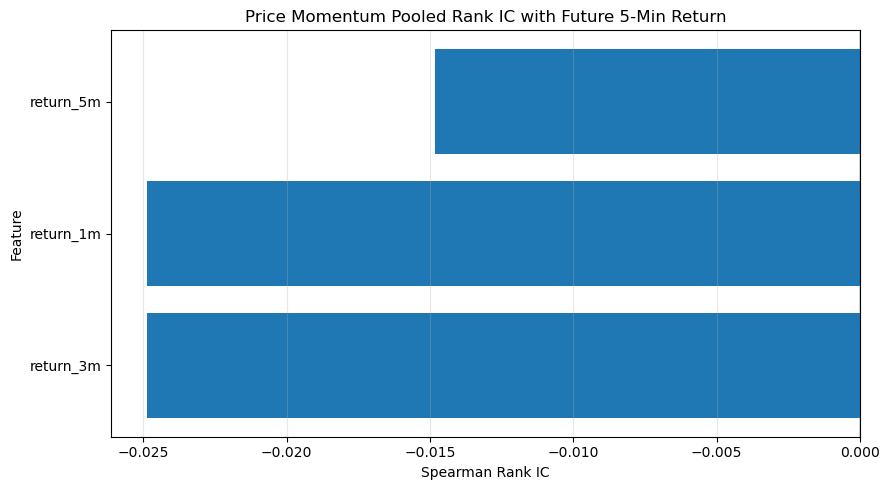

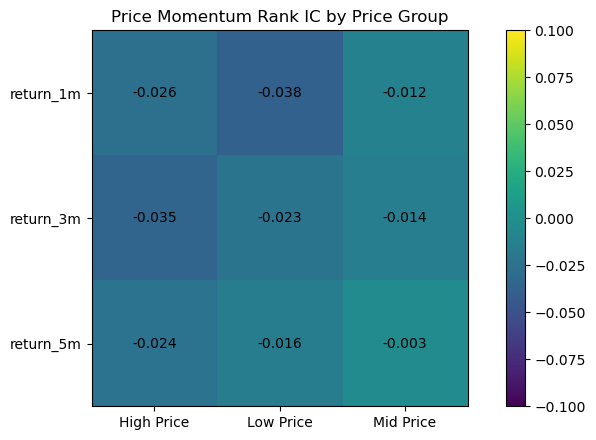

In [48]:
# ============================================================
# Momentum Feature IC Visualization
# ============================================================

plot_rank_ic_bar(
    momentum_eval["pooled_ic"],
    "Price Momentum Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    momentum_eval["price_group_ic_pivot"],
    "Price Momentum Rank IC by Price Group"
)

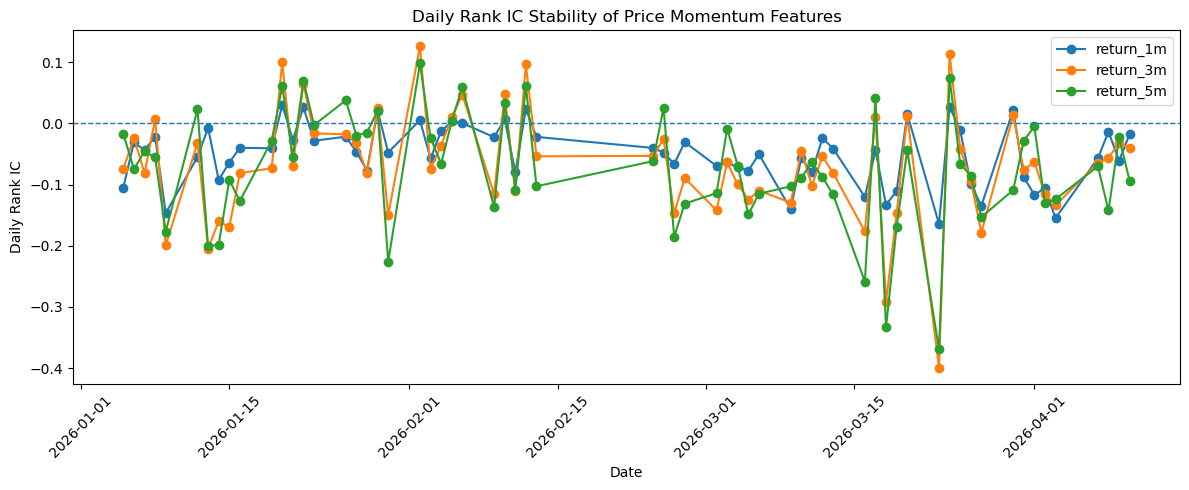

In [49]:
# ============================================================
# Daily Rank IC Stability of Momentum Features
# ============================================================

momentum_daily_ic = momentum_eval["daily_ic"]

plt.figure(figsize=(12, 5))

for feature in momentum_candidate_features:
    feature_ic = momentum_daily_ic[
        momentum_daily_ic["feature"] == feature
    ]

    plt.plot(
        feature_ic["date"],
        feature_ic["rank_ic"],
        marker="o",
        label=feature
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Daily Rank IC Stability of Price Momentum Features"
)

plt.xlabel("Date")
plt.ylabel("Daily Rank IC")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### 11.2 Momentum Reversal Quintile Analysis

The IC results indicate a negative relationship between recent price returns and future 5-minute returns.

To examine whether this relationship represents a systematic short-term reversal pattern, observations are sorted into quintiles based on `return_5m`.

```text
Q1 → Lowest past 5-minute returns
Q2
Q3
Q4
Q5 → Highest past 5-minute returns

In [50]:
# ============================================================
# Momentum Reversal Quintile Construction
# ============================================================

momentum_quintile_df = master_feature_df[
    [
        "code",
        "date",
        "minute",
        "price_group",
        "return_5m",
        "future_return_5m"
    ]
].dropna().copy()


def assign_daily_quintile(x):
    if x.nunique() < 5:
        return pd.Series(
            np.nan,
            index=x.index
        )

    return pd.qcut(
        x.rank(method="first"),
        q=5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
    )


momentum_quintile_df["momentum_quintile"] = (
    momentum_quintile_df
    .groupby("date")["return_5m"]
    .transform(assign_daily_quintile)
)

display(
    momentum_quintile_df.head(15)
)

display(
    momentum_quintile_df[
        "momentum_quintile"
    ].value_counts().sort_index()
)

,code,date,minute,price_group,return_5m,future_return_5m,momentum_quintile
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,Low Price,0.001509,-0.001507,Q3
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,Low Price,-0.001505,-0.001507,Q2
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,Low Price,0.001512,0.000000,Q3
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,Low Price,0.000000,0.000000,Q2
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,Low Price,0.000000,0.000000,Q2
10,000713.SZ,2026-01-05,2026-01-05 09:40:00,Low Price,-0.001507,0.000000,Q2
11,000713.SZ,2026-01-05,2026-01-05 09:41:00,Low Price,-0.001507,0.000000,Q2
12,000713.SZ,2026-01-05,2026-01-05 09:42:00,Low Price,0.000000,0.001509,Q2
13,000713.SZ,2026-01-05,2026-01-05 09:43:00,Low Price,0.000000,0.001509,Q2
14,000713.SZ,2026-01-05,2026-01-05 09:44:00,Low Price,0.000000,0.001509,Q2


momentum_quintile
Q1    10324
Q2    10291
Q3    10283
Q4    10291
Q5    10313
Name: count, dtype: int64

In [51]:
# ============================================================
# Momentum Quintile Future Return Summary
# ============================================================

momentum_quintile_summary = (
    momentum_quintile_df
    .groupby(
        "momentum_quintile",
        observed=True
    )
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_past_return=("return_5m", "mean"),
        avg_future_return=("future_return_5m", "mean"),
        median_future_return=("future_return_5m", "median"),
        positive_future_ratio=(
            "future_return_5m",
            lambda x: (x > 0).mean()
        )
    )
)

display(momentum_quintile_summary)

,n_obs,avg_past_return,avg_future_return,median_future_return,positive_future_ratio
momentum_quintile,,,,,
Q1,10324,-0.008955,0.000479,0.000237,0.506780
Q2,10291,-0.002802,0.000124,0.000000,0.457876
Q3,10283,-0.000283,-0.000157,0.000000,0.425946
Q4,10291,0.002404,-0.000234,-0.000072,0.414343
Q5,10313,0.009695,-0.000414,-0.000791,0.415980


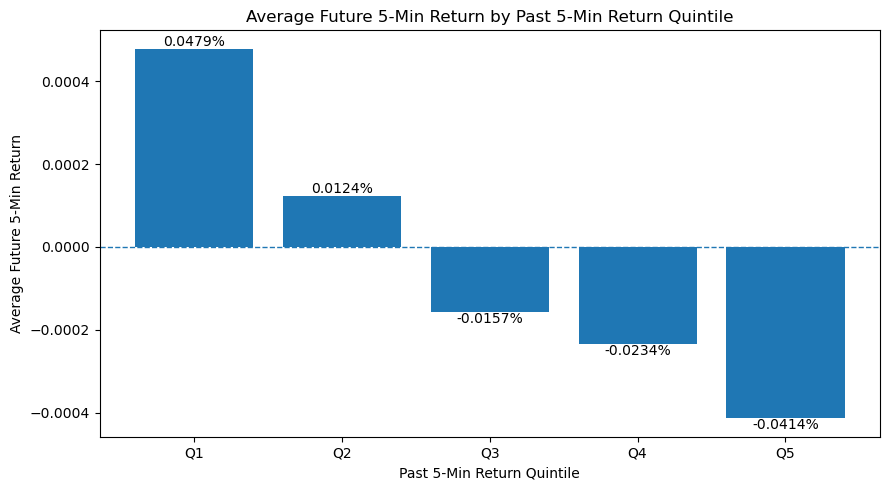

In [52]:
# ============================================================
# Momentum Quintile Grouped Return Plot
# ============================================================

plot_df = (
    momentum_quintile_summary
    .reset_index()
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["momentum_quintile"],
    plot_df["avg_future_return"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

for i, value in enumerate(
    plot_df["avg_future_return"]
):
    plt.text(
        i,
        value,
        f"{value:.4%}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.title(
    "Average Future 5-Min Return by Past 5-Min Return Quintile"
)

plt.xlabel("Past 5-Min Return Quintile")
plt.ylabel("Average Future 5-Min Return")

plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# Momentum Reversal Q1-Q5 Spread
# ============================================================

q1_return = momentum_quintile_summary.loc[
    "Q1",
    "avg_future_return"
]

q5_return = momentum_quintile_summary.loc[
    "Q5",
    "avg_future_return"
]

reversal_spread = q1_return - q5_return

print(
    f"Q1 Average Future Return: {q1_return:.4%}"
)

print(
    f"Q5 Average Future Return: {q5_return:.4%}"
)

print(
    f"Q1 - Q5 Reversal Spread: {reversal_spread:.4%}"
)

Q1 Average Future Return: 0.0479%
Q5 Average Future Return: -0.0414%
Q1 - Q5 Reversal Spread: 0.0893%


In [54]:
# ============================================================
# Momentum Quintile Analysis by Price Group
# ============================================================

price_group_quintile_summary = (
    momentum_quintile_df
    .groupby(
        [
            "price_group",
            "momentum_quintile"
        ],
        observed=True
    )
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_past_return=("return_5m", "mean"),
        avg_future_return=("future_return_5m", "mean")
    )
    .reset_index()
)

display(price_group_quintile_summary)

,price_group,momentum_quintile,n_obs,avg_past_return,avg_future_return
0,Low Price,Q1,3029,-0.008649,0.000543
1,Low Price,Q2,3416,-0.002726,0.000277
2,Low Price,Q3,3540,-0.000291,-0.000050
3,Low Price,Q4,3521,0.002475,-0.000004
4,Low Price,Q5,3088,0.009359,-0.000351
5,Mid Price,Q1,2953,-0.008394,0.000453
6,Mid Price,Q2,3469,-0.002758,0.000193
7,Mid Price,Q3,3812,-0.000289,-0.000093
8,Mid Price,Q4,3481,0.002328,-0.000274
9,Mid Price,Q5,3102,0.009350,-0.000268


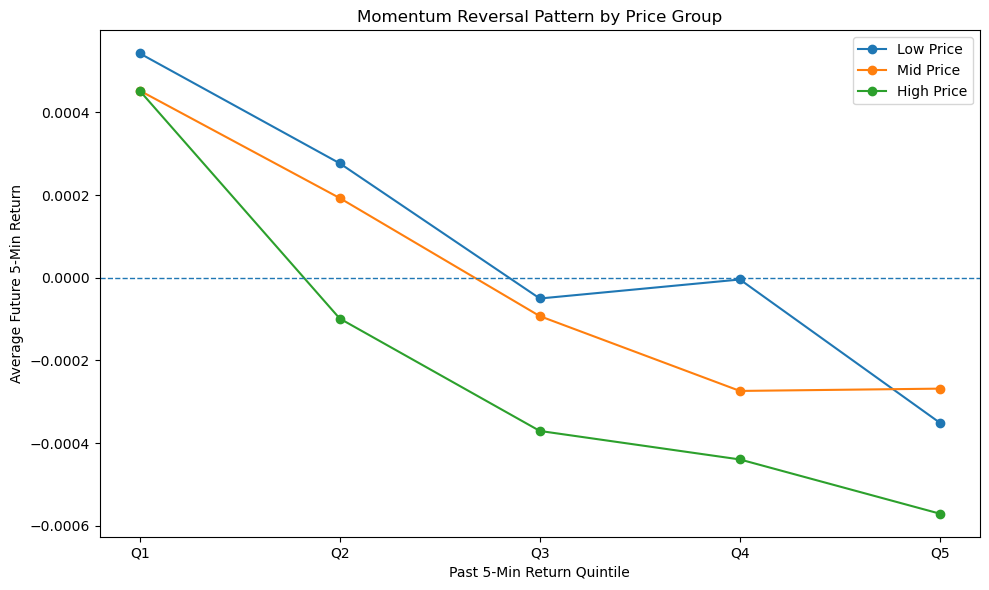

In [55]:
# ============================================================
# Momentum Reversal by Price Group
# ============================================================

plt.figure(figsize=(10, 6))

for price_group in [
    "Low Price",
    "Mid Price",
    "High Price"
]:
    sub = price_group_quintile_summary[
        price_group_quintile_summary[
            "price_group"
        ] == price_group
    ]

    plt.plot(
        sub["momentum_quintile"],
        sub["avg_future_return"],
        marker="o",
        label=price_group
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Momentum Reversal Pattern by Price Group"
)

plt.xlabel("Past 5-Min Return Quintile")
plt.ylabel("Average Future 5-Min Return")

plt.legend()
plt.tight_layout()
plt.show()

The economic structure of the reversal signal differs across price groups.

High Price stocks exhibit the clearest symmetric reversal pattern. Recent losers in Q1 realize an average future return of approximately +9.5 bps, while recent winners in Q5 realize approximately -10.7 bps, producing a spread of roughly 20.2 bps.

Mid Price stocks display a similar loser-rebound and winner-reversal pattern, with an approximate Q1-Q5 spread of 15.9 bps.

Low Price stocks also exhibit a monotonic relative reversal pattern, but the mechanism differs. Average future returns remain negative across all momentum quintiles. Recent losers subsequently decline less than recent winners rather than exhibiting an absolute rebound.

Therefore, price-level heterogeneity affects not only signal strength but also the economic form of short-term reversal.

#### Momentum Reversal Findings

Recent price movement exhibits the strongest and most economically interpretable single-factor relationship with future five-minute returns.

All three momentum horizons produce negative pooled and mean daily IC values. Depending on the lookback horizon, the negative relationship is observed on approximately 79%–83% of the 63 trading days, indicating a persistent short-horizon reversal pattern.

The quintile analysis provides a direct economic interpretation. Stocks in the lowest past five-minute return quintile subsequently realize an average return of approximately +5.45 bps, while stocks in the highest past-return quintile realize approximately -9.62 bps.

The resulting Q1-Q5 reversal spread is approximately 8.93 bps in the expanded sample.

The reversal pattern is visible across price groups, although the magnitude and upper-tail recovery differ across price levels.

**Predictive implication:** recent return is not simply a control variable. It represents a primary directional mechanism in the final prediction score.

## 12. Volatility Features

Volatility features measure the recent instability of prices and market liquidity.

Unlike price momentum, which captures the direction of recent price movements, volatility features focus on the magnitude and variability of short-term price changes.

The following features are constructed:

| Feature | Description |
|---|---|
| `volatility_1m` | Standard deviation of recent minute returns over a 1-minute window |
| `volatility_3m` | Standard deviation of recent minute returns over a 3-minute window |
| `volatility_5m` | Standard deviation of recent minute returns over a 5-minute window |
| `spread_change_1m` | One-minute change in relative bid-ask spread |

The objective is to test whether recent price or liquidity instability contains predictive information for future 5-minute returns.

In [56]:
# ============================================================
# Volatility Feature Construction
# ============================================================

master_feature_df = (
    master_feature_df
    .sort_values(["code", "date", "minute"])
    .copy()
)

group_keys = ["code", "date"]

# 1. Absolute 1-minute return
master_feature_df["abs_return_1m"] = (
    master_feature_df["return_1m"].abs()
)

# 2. Rolling return volatility
master_feature_df["volatility_3m"] = (
    master_feature_df
    .groupby(group_keys)["return_1m"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=3
        ).std()
    )
)

master_feature_df["volatility_5m"] = (
    master_feature_df
    .groupby(group_keys)["return_1m"]
    .transform(
        lambda x: x.rolling(
            window=5,
            min_periods=5
        ).std()
    )
)

# 3. One-minute relative spread change
master_feature_df["spread_change_1m"] = (
    master_feature_df
    .groupby(group_keys)["relative_spread"]
    .pct_change()
)

volatility_features = [
    "abs_return_1m",
    "volatility_3m",
    "volatility_5m",
    "spread_change_1m"
]

display(
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "return_1m",
            "abs_return_1m",
            "volatility_3m",
            "volatility_5m",
            "relative_spread",
            "spread_change_1m",
            "future_return_5m",
            "price_group"
        ]
    ].head(15)
)

,code,date,minute,return_1m,abs_return_1m,volatility_3m,volatility_5m,relative_spread,spread_change_1m,future_return_5m,price_group
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,NaN,NaN,NaN,NaN,0.001509,NaN,0.001509,Low Price
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,0.003019,0.003019,NaN,NaN,0.001505,-0.003010,-0.001505,Low Price
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,-0.004515,0.004515,NaN,NaN,0.001512,0.004535,0.001512,Low Price
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,0.001512,0.001512,0.003986,NaN,0.001509,-0.001509,0.000000,Low Price
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,0.000000,0.000000,0.003135,NaN,0.001509,0.000000,0.000000,Low Price
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,0.001509,0.001509,0.000872,0.002898,0.001507,-0.001507,-0.001507,Low Price
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,0.000000,0.000000,0.000871,0.002475,0.001507,0.000000,-0.001507,Low Price
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,-0.001507,0.001507,0.001508,0.001263,0.001509,0.001509,0.000000,Low Price
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,0.000000,0.000000,0.000870,0.001067,0.001509,0.000000,0.000000,Low Price
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,0.000000,0.000000,0.000870,0.001067,0.001509,0.000000,0.000000,Low Price


In [57]:
# ============================================================
# Volatility Feature Diagnostics
# ============================================================

display(
    master_feature_df[
        volatility_features
    ].describe().T
)

display(
    master_feature_df[
        volatility_features
    ]
    .isna()
    .mean()
    .rename("missing_rate")
    .to_frame()
)

,count,mean,std,min,25%,50%,75%,max
abs_return_1m,61529.0,0.002358,0.002755,0.000000,0.000610,0.001642,0.003118,0.057623
volatility_3m,56515.0,0.002647,0.002379,0.000000,0.001124,0.002006,0.003420,0.034606
volatility_5m,51502.0,0.002777,0.002096,0.000000,0.001384,0.002229,0.003546,0.029435
spread_change_1m,61529.0,inf,NaN,-1.996574,-0.014755,0.000000,0.005333,inf


,missing_rate
abs_return_1m,0.039195
volatility_3m,0.117491
volatility_5m,0.195771
spread_change_1m,0.039195


Recent volatility measures exhibit weak negative pooled relationships with future five-minute returns.

`volatility_5m`, `volatility_3m`, and `abs_return_1m` produce pooled Rank IC values of -0.0211, -0.0203, and -0.0177, respectively.

However, the corresponding daily IC statistics show limited directional persistence. Mean daily IC values remain close to zero, positive IC ratios are approximately 50%, and ICIR values are close to zero.

Therefore, recent volatility does not appear to provide a stable directional signal for future five-minute returns.

Rather than acting as standalone alpha factors, volatility measures are more appropriately interpreted as market-state variables that may modify the strength of other directional signals.

In [58]:
# ============================================================
# Volatility Feature Evaluation
# ============================================================

volatility_eval = evaluate_feature_family(
    master_feature_df,
    volatility_features,
    "Volatility"
)

print("Pooled IC:")
display(volatility_eval["pooled_ic"])

print("Daily IC Summary:")
display(volatility_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(volatility_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(volatility_eval["price_group_daily_summary"])

c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:

Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Volatility,volatility_5m,-0.017598,-0.045667,0.045667,51502,Negative
1,Volatility,volatility_3m,-0.018584,-0.041312,0.041312,56515,Negative
2,Volatility,abs_return_1m,-0.003451,-0.030806,0.030806,61529,Negative
3,Volatility,spread_change_1m,NaN,0.005833,0.005833,61529,Positive


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
volatility_5m,-0.032257,0.087370,0.317460,63,-0.369198,0.032257
volatility_3m,-0.030015,0.075225,0.333333,63,-0.399005,0.030015
abs_return_1m,-0.015774,0.058649,0.396825,63,-0.268953,0.015774
spread_change_1m,0.015281,0.027820,0.714286,63,0.549267,0.015281


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
abs_return_1m,-0.010584,-0.043542,-0.030633
spread_change_1m,-0.000532,0.019920,0.008539
volatility_3m,-0.022726,-0.054595,-0.039563
volatility_5m,-0.024756,-0.065512,-0.039228


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,abs_return_1m,0.000698,0.074017,0.507937,63,0.009432
1,High Price,spread_change_1m,0.000615,0.037315,0.492063,63,0.016473
2,High Price,volatility_3m,-0.015298,0.091188,0.380952,63,-0.167761
3,High Price,volatility_5m,-0.013714,0.112466,0.396825,63,-0.121935
4,Low Price,abs_return_1m,-0.023304,0.069473,0.301587,63,-0.335445
5,Low Price,spread_change_1m,0.047437,0.056797,0.809524,63,0.835205
6,Low Price,volatility_3m,-0.036427,0.099806,0.317460,63,-0.364982
7,Low Price,volatility_5m,-0.045984,0.121137,0.317460,63,-0.379607
8,Mid Price,abs_return_1m,-0.016885,0.090909,0.444444,63,-0.185738
9,Mid Price,spread_change_1m,0.024723,0.042169,0.666667,63,0.586297


The predictive relationship of `spread_change_1m` is concentrated primarily in Low Price stocks.

Within the Low Price group, `spread_change_1m` produces a mean daily IC of 0.0474 and an ICIR of 0.84. Positive IC is observed on approximately 81.0% of the 63 trading days.

This result is consistent with the earlier snapshot feature analysis. `microprice_deviation`, `depth_imbalance`, and `spread_change_1m` all exhibit stronger predictive relationships among Low Price stocks.

Collectively, these results suggest that short-horizon returns of lower-priced stocks are particularly sensitive to contemporaneous order-book and liquidity conditions.

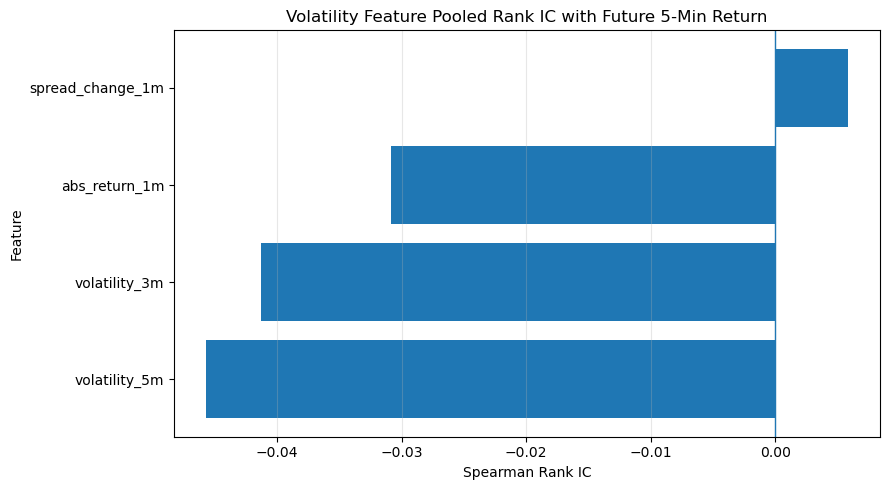

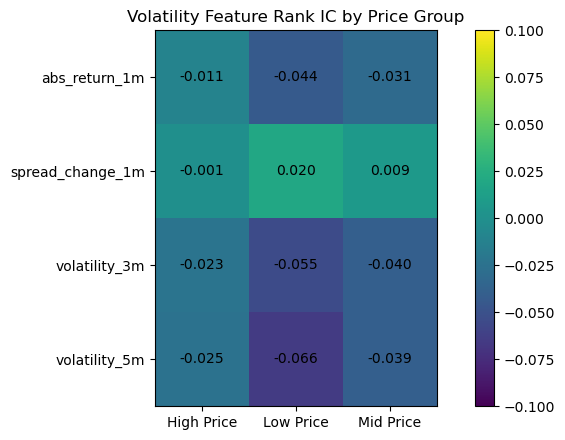

In [59]:
# ============================================================
# Volatility Feature IC Visualization
# ============================================================

plot_rank_ic_bar(
    volatility_eval["pooled_ic"],
    "Volatility Feature Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    volatility_eval["price_group_ic_pivot"],
    "Volatility Feature Rank IC by Price Group"
)

单纯的价格波动率对未来 5 分钟收益方向预测较弱；反而 spread 的短期变化出现了更稳定的预测关系，尤其是在 Low Price stocks。Spread change may capture a short-term liquidity state that contains predictive information, particularly among Low Price stocks.
Low Price stocks 更适合看 order-book / liquidity state；High Price stocks 的 recent price path，尤其 short-term reversal，更有预测力。

Short-horizon volatility measures exhibit weak and unstable standalone relationships with future return rankings.

Although three- and five-minute volatility produce negative pooled IC, the daily relationships are inconsistent and ICIR values remain close to zero.

In contrast, `spread_change_1m` has only a small pooled Rank IC but exhibits positive daily IC on approximately 77% of trading days, with an ICIR of 0.77.

**Predictive implication:** volatility is more useful as a market-state or interaction variable than as a direct directional predictor. Short-horizon spread adjustment provides a more persistent liquidity-state signal and is retained for multivariate modeling.

## 13. Feature Screening

In [60]:
candidate_features = (
    snapshot_candidate_features
    + trade_candidate_features
    + signed_pressure_features
    + momentum_candidate_features
    + volatility_features
)

screening_rows = []

candidate_features = list(dict.fromkeys(candidate_features))

available_features = [
    feature
    for feature in candidate_features
    if feature in master_feature_df.columns
]

missing_features = [
    feature
    for feature in candidate_features
    if feature not in master_feature_df.columns
]

for feature in available_features:
    valid = master_feature_df[
        [feature, "future_return_5m"]
    ].dropna()

    if len(valid) < 100:
        continue

    pearson_ic = valid[feature].corr(
        valid["future_return_5m"],
        method="pearson"
    )

    rank_ic = valid[feature].corr(
        valid["future_return_5m"],
        method="spearman"
    )

    daily_ic = (
        master_feature_df
        .dropna(subset=[feature, "future_return_5m"])
        .groupby("date")
        .apply(
            lambda x: x[feature].corr(
                x["future_return_5m"],
                method="spearman"
            )
        )
        .dropna()
    )

    screening_rows.append({
        "feature": feature,
        "n_obs": len(valid),
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "abs_rank_ic": abs(rank_ic),
        "mean_daily_ic": daily_ic.mean(),
        "ic_std": daily_ic.std(),
        "icir": (
            daily_ic.mean() / daily_ic.std()
            if daily_ic.std() != 0
            else np.nan
        ),
        "positive_ic_ratio": (daily_ic > 0).mean()
    })

feature_screening = (
    pd.DataFrame(screening_rows)
    .sort_values("abs_rank_ic", ascending=False)
)

display(feature_screening)

C:\Users\work\AppData\Local\Temp\ipykernel_24260\3354105133.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\work\AppData\Local\Temp\ipykernel_24260\3354105133.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\work\AppData\Local\Temp\ipykernel_24260\3354105133.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

,feature,n_obs,pearson_ic,rank_ic,abs_rank_ic,mean_daily_ic,ic_std,icir,positive_ic_ratio
17,volatility_5m,51502,-0.017598,-0.045667,0.045667,-0.032257,0.087370,-0.369198,0.317460
16,volatility_3m,56515,-0.018584,-0.041312,0.041312,-0.030015,0.075225,-0.399005,0.333333
15,abs_return_1m,61529,-0.003451,-0.030806,0.030806,-0.015774,0.058649,-0.268953,0.396825
3,microprice_deviation,64039,0.015133,0.026245,0.026245,0.034788,0.042335,0.821714,0.809524
13,return_3m,56515,-0.022609,-0.024875,0.024875,-0.069081,0.090957,-0.759491,0.206349
12,return_1m,61529,-0.021150,-0.024863,0.024863,-0.050655,0.048925,-1.035347,0.174603
2,depth_imbalance,64039,0.018358,0.024645,0.024645,0.032885,0.040054,0.821026,0.793651
1,log_top_depth,64039,0.019383,0.024564,0.024564,0.020512,0.077835,0.263528,0.619048
5,trade_sign_proxy,64039,0.015502,0.019603,0.019603,0.015044,0.029525,0.509556,0.682540
9,signed_volume_imbalance_1m,61533,0.018375,0.017307,0.017307,0.013650,0.034510,0.395545,0.619048


In [61]:
# ============================================================
# 13.1 Direction-Aware Feature Screening
# ============================================================

feature_screening["dominant_direction"] = np.where(
    feature_screening["mean_daily_ic"] >= 0,
    "Positive",
    "Negative"
)

feature_screening["direction_consistency"] = np.where(
    feature_screening["mean_daily_ic"] >= 0,
    feature_screening["positive_ic_ratio"],
    1 - feature_screening["positive_ic_ratio"]
)

feature_screening["abs_mean_daily_ic"] = (
    feature_screening["mean_daily_ic"].abs()
)

feature_screening["abs_icir"] = (
    feature_screening["icir"].abs()
)

feature_screening = feature_screening.sort_values(
    [
        "direction_consistency",
        "abs_mean_daily_ic",
        "abs_rank_ic"
    ],
    ascending=False
)

display(
    feature_screening[
        [
            "feature",
            "rank_ic",
            "mean_daily_ic",
            "dominant_direction",
            "direction_consistency",
            "icir",
            "abs_rank_ic"
        ]
    ]
)

,feature,rank_ic,mean_daily_ic,dominant_direction,direction_consistency,icir,abs_rank_ic
12,return_1m,-0.024863,-0.050655,Negative,0.825397,-1.035347,0.024863
3,microprice_deviation,0.026245,0.034788,Positive,0.809524,0.821714,0.026245
14,return_5m,-0.014831,-0.073924,Negative,0.793651,-0.783641,0.014831
13,return_3m,-0.024875,-0.069081,Negative,0.793651,-0.759491,0.024875
2,depth_imbalance,0.024645,0.032885,Positive,0.793651,0.821026,0.024645
18,spread_change_1m,0.005833,0.015281,Positive,0.714286,0.549267,0.005833
17,volatility_5m,-0.045667,-0.032257,Negative,0.682540,-0.369198,0.045667
5,trade_sign_proxy,0.019603,0.015044,Positive,0.682540,0.509556,0.019603
16,volatility_3m,-0.041312,-0.030015,Negative,0.666667,-0.399005,0.041312
1,log_top_depth,0.024564,0.020512,Positive,0.619048,0.263528,0.024564


In [62]:
# ============================================================
# 13.2 Composite Feature Screening Score
# ============================================================

screening_score_df = feature_screening.copy()

metrics_to_rank = {
    "abs_rank_ic": True,
    "abs_mean_daily_ic": True,
    "abs_icir": True,
    "direction_consistency": True
}

for metric, ascending_strength in metrics_to_rank.items():

    screening_score_df[f"{metric}_score"] = (
        screening_score_df[metric]
        .rank(pct=True)
    )

screening_score_df["screening_score"] = (
    0.30 * screening_score_df["abs_rank_ic_score"]
    + 0.30 * screening_score_df["abs_mean_daily_ic_score"]
    + 0.20 * screening_score_df["abs_icir_score"]
    + 0.20 * screening_score_df["direction_consistency_score"]
)

screening_score_df = screening_score_df.sort_values(
    "screening_score",
    ascending=False
)

display(
    screening_score_df[
        [
            "feature",
            "dominant_direction",
            "rank_ic",
            "mean_daily_ic",
            "direction_consistency",
            "icir",
            "screening_score"
        ]
    ]
)

,feature,dominant_direction,rank_ic,mean_daily_ic,direction_consistency,icir,screening_score
12,return_1m,Negative,-0.024863,-0.050655,0.825397,-1.035347,0.889474
3,microprice_deviation,Positive,0.026245,0.034788,0.809524,0.821714,0.884211
13,return_3m,Negative,-0.024875,-0.069081,0.793651,-0.759491,0.852632
2,depth_imbalance,Positive,0.024645,0.032885,0.793651,0.821026,0.778947
14,return_5m,Negative,-0.014831,-0.073924,0.793651,-0.783641,0.768421
17,volatility_5m,Negative,-0.045667,-0.032257,0.682540,-0.369198,0.747368
16,volatility_3m,Negative,-0.041312,-0.030015,0.666667,-0.399005,0.731579
15,abs_return_1m,Negative,-0.030806,-0.015774,0.603175,-0.268953,0.589474
5,trade_sign_proxy,Positive,0.019603,0.015044,0.682540,0.509556,0.584211
1,log_top_depth,Positive,0.024564,0.020512,0.619048,0.263528,0.542105


In [63]:
# ============================================================
# 13.3 Preliminary Feature Selection
# ============================================================

top_n = 12

preliminary_features = (
    screening_score_df
    .head(top_n)["feature"]
    .tolist()
)

print("Preliminary selected features:")
for i, feature in enumerate(preliminary_features, 1):
    print(f"{i:2d}. {feature}")

Preliminary selected features:
 1. return_1m
 2. microprice_deviation
 3. return_3m
 4. depth_imbalance
 5. return_5m
 6. volatility_5m
 7. volatility_3m
 8. abs_return_1m
 9. trade_sign_proxy
10. log_top_depth
11. spread_change_1m
12. signed_volume_imbalance_1m


## 14. Correlation Screening


Preliminary features:
['return_1m', 'microprice_deviation', 'return_3m', 'depth_imbalance', 'return_5m', 'volatility_5m', 'volatility_3m', 'abs_return_1m', 'trade_sign_proxy', 'log_top_depth']


,return_1m,microprice_deviation,return_3m,depth_imbalance,return_5m,volatility_5m,volatility_3m,abs_return_1m,trade_sign_proxy,log_top_depth
return_1m,1.000000,-0.106590,0.491230,-0.102165,0.365916,-0.007606,0.011850,-0.024083,-0.030485,-0.017402
microprice_deviation,-0.106590,1.000000,-0.086329,0.911806,-0.077866,-0.003959,-0.003661,-0.001200,0.102550,0.018113
return_3m,0.491230,-0.086329,1.000000,-0.081925,0.687008,0.038490,0.078766,0.025080,0.010784,-0.008998
depth_imbalance,-0.102165,0.911806,-0.081925,1.000000,-0.075134,-0.005029,-0.007162,-0.002011,0.102487,0.014736
return_5m,0.365916,-0.077866,0.687008,-0.075134,1.000000,0.079505,0.071872,0.024765,0.017248,-0.006961
volatility_5m,-0.007606,-0.003959,0.038490,-0.005029,0.079505,1.000000,0.809822,0.540150,0.011215,-0.148779
volatility_3m,0.011850,-0.003661,0.078766,-0.007162,0.071872,0.809822,1.000000,0.567087,0.010962,-0.128009
abs_return_1m,-0.024083,-0.001200,0.025080,-0.002011,0.024765,0.540150,0.567087,1.000000,0.016380,-0.137667
trade_sign_proxy,-0.030485,0.102550,0.010784,0.102487,0.017248,0.011215,0.010962,0.016380,1.000000,0.004648
log_top_depth,-0.017402,0.018113,-0.008998,0.014736,-0.006961,-0.148779,-0.128009,-0.137667,0.004648,1.000000


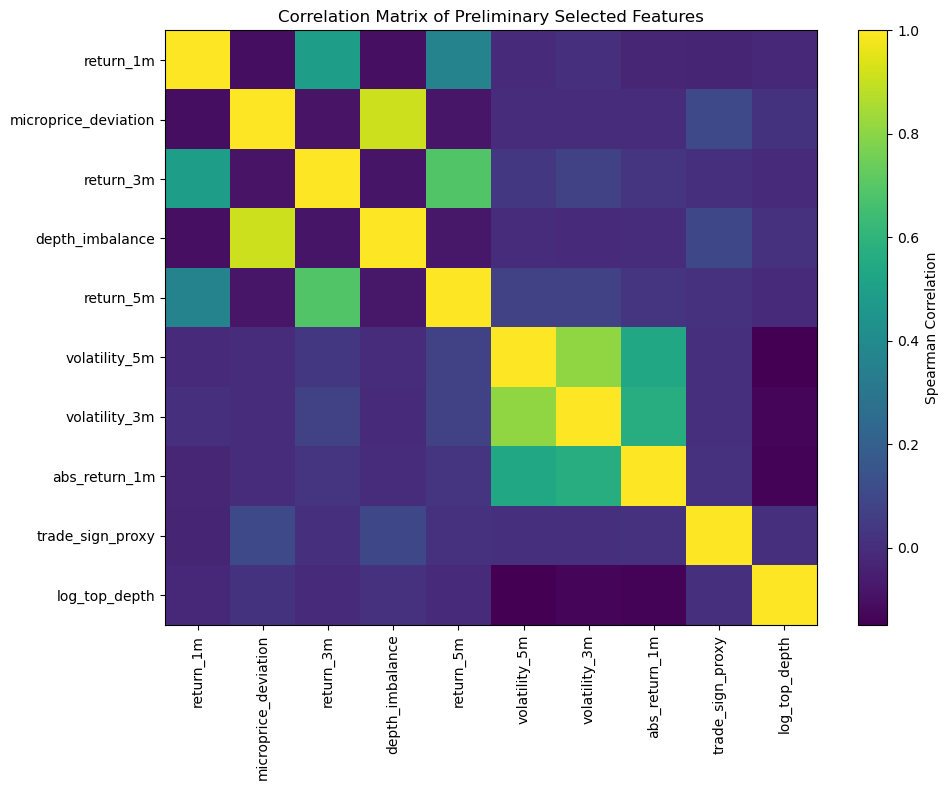

In [64]:
preliminary_features = (
    screening_score_df
    .query("screening_score >= 0.50")
    ["feature"]
    .tolist()
)

print("Preliminary features:")
print(preliminary_features)

corr_matrix = master_feature_df[preliminary_features].corr(method="spearman")

display(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Spearman Correlation")
plt.xticks(range(len(preliminary_features)), preliminary_features, rotation=90)
plt.yticks(range(len(preliminary_features)), preliminary_features)
plt.title("Correlation Matrix of Preliminary Selected Features")
plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# 14.1 Highly Correlated Feature Pairs
# ============================================================

corr_threshold = 0.80

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        f1 = corr_matrix.columns[i]
        f2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) >= corr_threshold:
            high_corr_pairs.append({
                "feature_1": f1,
                "feature_2": f2,
                "spearman_corr": corr_value,
                "abs_corr": abs(corr_value)
            })

high_corr_pairs = (
    pd.DataFrame(high_corr_pairs)
    .sort_values("abs_corr", ascending=False)
)

display(high_corr_pairs)

,feature_1,feature_2,spearman_corr,abs_corr
0,microprice_deviation,depth_imbalance,0.911806,0.911806
1,volatility_5m,volatility_3m,0.809822,0.809822


In [66]:
# ============================================================
# 14.2 Family-Aware Redundancy Removal
# ============================================================

score_map = screening_score_df.set_index("feature")["screening_score"].to_dict()

features_ranked = (
    screening_score_df[
        screening_score_df["feature"].isin(preliminary_features)
    ]
    .sort_values("screening_score", ascending=False)
    ["feature"]
    .tolist()
)

final_features = []

for feature in features_ranked:
    keep = True

    for kept_feature in final_features:
        corr_value = abs(corr_matrix.loc[feature, kept_feature])

        if corr_value >= corr_threshold:
            keep = False
            print(
                f"Drop {feature} because corr({feature}, {kept_feature}) = {corr_value:.3f}; "
                f"keep {kept_feature} with higher screening score."
            )
            break

    if keep:
        final_features.append(feature)

print("\nFinal selected features:")
for i, feature in enumerate(final_features, 1):
    print(f"{i}. {feature}")

Drop depth_imbalance because corr(depth_imbalance, microprice_deviation) = 0.912; keep microprice_deviation with higher screening score.
Drop volatility_3m because corr(volatility_3m, volatility_5m) = 0.810; keep volatility_5m with higher screening score.

Final selected features:
1. return_1m
2. microprice_deviation
3. return_3m
4. return_5m
5. volatility_5m
6. abs_return_1m
7. trade_sign_proxy
8. log_top_depth


In [67]:
return_corr = master_feature_df[
    ["return_1m", "return_3m", "return_5m"]
].corr(method="spearman")

display(return_corr)

,return_1m,return_3m,return_5m
return_1m,1.000000,0.491230,0.365916
return_3m,0.491230,1.000000,0.687008
return_5m,0.365916,0.687008,1.000000


Correlation screening shows that several individually predictive features capture highly overlapping market mechanisms.

microprice_deviation and depth_imbalance have a Spearman correlation of 0.924. Both features describe top-of-book order pressure, suggesting that their predictive information largely originates from the same order-book imbalance mechanism. microprice_deviation is retained because it has stronger Rank IC and Daily IC stability.

The signed trading-pressure family also contains substantial redundancy. signed_volume_1m and signed_volume_imbalance_1m have a Spearman correlation of 1.00, indicating identical ranking information in the current sample. Both variables are also highly correlated with trade_sign_proxy, with correlations around 0.89. Therefore, trade_sign_proxy is retained as the representative signed trading-pressure feature.

In contrast, the multi-horizon return features are correlated but not redundant. The Spearman correlation between return_1m and return_3m is 0.508, between return_3m and return_5m is 0.698, and between return_1m and return_5m is only 0.377.

Combined with the consistently negative IC observed for all three return horizons, this result suggests that short-term reversal is present across multiple time scales. However, each return window may capture a different stage of short-term price adjustment: return_1m reflects immediate price correction, return_3m captures intermediate reversal dynamics, and return_5m represents broader short-horizon mean reversion.

Therefore, all three return features are retained for the baseline model. Their moderate correlation motivates the use of a regularized linear model rather than treating them as fully independent signals.

After redundancy removal, the final feature set represents four broader microstructure mechanisms:

Order-Book Pressure
    → microprice_deviation

Multi-Horizon Price Reversal
    → return_1m
    → return_3m
    → return_5m

Signed Trading Pressure
    → trade_sign_proxy

Liquidity State
    → spread_change_1m
    → log_top_depth

The final feature set is therefore designed to preserve predictive information from economically distinct market mechanisms while removing highly redundant representations of the same underlying signal.

## 15. Linear Model Diagnosis

This section uses a controlled sequence of linear models to identify why a direct multi-factor return regression is weak. All models use the same chronological train/test split and are compared on identical observations.

1. **Raw-Feature / Return-Target Ridge** tests a conventional additive return model.
2. **Cross-Sectional Feature / Return-Target Ridge** removes persistent stock-level scale differences.
3. **Cross-Sectional Feature / Rank-Target Ridge** aligns the training objective with cross-sectional ranking.

Because the selected feature set includes one-, three- and five-minute rolling variables, this section is a **post-open benchmark** whose earliest valid prediction time is approximately 09:35. The strict 09:30 forecast remains a separate model in Section 21.


### 15.1 Clean Raw-Feature Ridge Baseline


In [68]:
# ============================================================
# 15.1 Clean Raw-Feature / Return-Target Ridge
# ============================================================
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TARGET_COL = "future_return_5m"
model_columns = list(dict.fromkeys(
    ["code", "date", "minute", "price_group", TARGET_COL] + final_features
))

model_df = master_feature_df[model_columns].copy()
model_df[final_features] = model_df[final_features].apply(pd.to_numeric, errors="coerce")
model_df[TARGET_COL] = pd.to_numeric(model_df[TARGET_COL], errors="coerce")
model_df[final_features + [TARGET_COL]] = (
    model_df[final_features + [TARGET_COL]].replace([np.inf, -np.inf], np.nan)
)

# Missing rolling features mean that the required history is not observable.
# They are not filled with zero or a median.
model_df = model_df.dropna(subset=final_features + [TARGET_COL]).copy()
model_df["date"] = pd.to_datetime(model_df["date"]).dt.normalize()
model_df["minute"] = pd.to_datetime(model_df["minute"])

dates = sorted(model_df["date"].dropna().unique())
split_idx = int(len(dates) * 0.70)
train_dates = pd.DatetimeIndex(dates[:split_idx]).normalize()
test_dates = pd.DatetimeIndex(dates[split_idx:]).normalize()

train_df = model_df[model_df["date"].isin(train_dates)].copy()
test_df = model_df[model_df["date"].isin(test_dates)].copy()

assert len(train_df) > 0 and len(test_df) > 0
assert train_df["date"].max() < test_df["date"].min()

# Clip with training-period thresholds only.
train_lower = train_df[final_features].quantile(0.01)
train_upper = train_df[final_features].quantile(0.99)
train_df.loc[:, final_features] = train_df[final_features].clip(train_lower, train_upper, axis=1)
test_df.loc[:, final_features] = test_df[final_features].clip(train_lower, train_upper, axis=1)

X_train, X_test = train_df[final_features], test_df[final_features]
y_train, y_test = train_df[TARGET_COL], test_df[TARGET_COL]

assert np.isfinite(X_train.to_numpy(dtype=float)).all()
assert np.isfinite(X_test.to_numpy(dtype=float)).all()

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
ridge_model.fit(X_train, y_train)
test_df["pred_return_5m"] = ridge_model.predict(X_test)

coef_df = pd.DataFrame({
    "feature": final_features,
    "coefficient": ridge_model.named_steps["model"].coef_
}).assign(abs_coefficient=lambda x: x["coefficient"].abs()).sort_values(
    "abs_coefficient", ascending=False
)

print("Clean model observations:", len(model_df))
print("Earliest prediction time:", model_df["minute"].min())
print("Train:", train_dates.min().date(), "to", train_dates.max().date())
print("Test:", test_dates.min().date(), "to", test_dates.max().date())
display(coef_df)


Clean model observations: 51502
Earliest prediction time: 2026-01-05 09:35:00
Train: 2026-01-05 to 2026-03-13
Test: 2026-03-16 to 2026-04-10


,feature,coefficient,abs_coefficient
7,log_top_depth,0.000246,0.000246
4,volatility_5m,-0.000148,0.000148
0,return_1m,-0.000130,0.000130
1,microprice_deviation,0.000120,0.000120
6,trade_sign_proxy,0.000116,0.000116
3,return_5m,0.000100,0.000100
5,abs_return_1m,0.000071,0.000071
2,return_3m,-0.000046,0.000046


In [69]:
# ============================================================
# Common cross-sectional evaluation helpers
# ============================================================
QUINTILE_ORDER = ["Q1 - Lowest", "Q2", "Q3", "Q4", "Q5 - Highest"]

def date_minute_ic_series(df, prediction_col, target_col=TARGET_COL):
    def one_ic(x):
        if len(x) < 5 or x[prediction_col].nunique() < 2 or x[target_col].nunique() < 2:
            return np.nan
        return x[prediction_col].corr(x[target_col], method="spearman")
    return df.groupby(["date", "minute"]).apply(
        one_ic, include_groups=False
    ).dropna()

def evaluate_ranking_model(df, prediction_col, model_name, target_col=TARGET_COL):
    temp = df.copy()
    cs_ic = date_minute_ic_series(temp, prediction_col, target_col)
    daily_ic = cs_ic.groupby(level="date").mean()
    temp["score_percentile"] = temp.groupby(["date", "minute"])[prediction_col].rank(
        pct=True, method="first"
    )
    temp["prediction_quintile"] = pd.cut(
        temp["score_percentile"],
        bins=[0, .2, .4, .6, .8, 1], labels=QUINTILE_ORDER, include_lowest=True
    )
    q = temp.groupby("prediction_quintile", observed=True)[target_col].mean().reindex(QUINTILE_ORDER)
    q5_q1 = q.iloc[-1] - q.iloc[0]
    monotonicity = pd.Series(range(1, 6), index=QUINTILE_ORDER, dtype=float).corr(
        q, method="spearman"
    )
    return {
        "Model": model_name,
        "n_obs": len(temp),
        "Pooled Rank IC": temp[prediction_col].corr(temp[target_col], method="spearman"),
        "Mean Date-Minute IC": cs_ic.mean(),
        "Positive IC Ratio": (cs_ic > 0).mean(),
        "Mean Daily IC": daily_ic.mean(),
        "Positive Daily IC Ratio": (daily_ic > 0).mean(),
        "Q5-Q1 Spread (bps)": q5_q1 * 10000,
        "Quintile Monotonicity": monotonicity,
    }, q, temp

raw_metrics, raw_quintile_return, raw_eval_df = evaluate_ranking_model(
    test_df, "pred_return_5m", "Raw-Feature / Return-Target Ridge"
)

point_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [
        mean_absolute_error(y_test, test_df["pred_return_5m"]),
        mean_squared_error(y_test, test_df["pred_return_5m"]) ** 0.5,
        r2_score(y_test, test_df["pred_return_5m"]),
    ]
})
display(point_summary)
display(pd.DataFrame([raw_metrics]))


,Metric,Value
0,MAE,0.004051
1,RMSE,0.005799
2,R2,-0.004328


,Model,n_obs,Pooled Rank IC,Mean Date-Minute IC,Positive IC Ratio,Mean Daily IC,Positive Daily IC Ratio,Q5-Q1 Spread (bps),Quintile Monotonicity
0,Raw-Feature / Return-Target Ridge,15459,0.025401,0.016025,0.561404,0.016025,0.684211,0.709229,0.7


### 15.2 Cross-Sectionally Standardized Ridge

Raw microstructure variables contain persistent differences in price level, depth and trading activity across stocks. Each selected feature is therefore standardized within its own `date-minute` cross-section before fitting the second Ridge model.


In [70]:
# ============================================================
# Cross-sectional feature standardization
# ============================================================
def add_cross_sectional_zscores(df, features):
    result = df.copy()
    cs_names = []
    for feature in features:
        mean = result.groupby(["date", "minute"])[feature].transform("mean")
        std = result.groupby(["date", "minute"])[feature].transform("std").replace(0, np.nan)
        name = f"{feature}_cs_z"
        result[name] = (result[feature] - mean) / std
        cs_names.append(name)
    return result, cs_names

model_df_cs, cs_features = add_cross_sectional_zscores(model_df, final_features)
model_df_cs[cs_features] = model_df_cs[cs_features].replace([np.inf, -np.inf], np.nan)
model_df_cs = model_df_cs.dropna(subset=cs_features + [TARGET_COL]).copy()

cs_train_df = model_df_cs[model_df_cs["date"].isin(train_dates)].copy()
cs_test_df = model_df_cs[model_df_cs["date"].isin(test_dates)].copy()

X_cs_train, X_cs_test = cs_train_df[cs_features], cs_test_df[cs_features]
y_cs_train, y_cs_test = cs_train_df[TARGET_COL], cs_test_df[TARGET_COL]

assert len(cs_train_df) > 0 and len(cs_test_df) > 0
assert np.isfinite(X_cs_train.to_numpy(dtype=float)).all()
assert np.isfinite(X_cs_test.to_numpy(dtype=float)).all()

cs_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
cs_ridge_model.fit(X_cs_train, y_cs_train)
cs_test_df["pred_return_5m"] = cs_ridge_model.predict(X_cs_test)

print("CS train observations:", len(cs_train_df))
print("CS test observations:", len(cs_test_df))


CS train observations: 36043
CS test observations: 15459


### 15.3 Cross-Sectional Rank-Target Ridge

The third model retains cross-sectionally standardized features but replaces the raw return target with the percentile rank of future five-minute return within each `date-minute` cross-section. The realized raw return remains the economic evaluation target.


In [71]:
# ============================================================
# Cross-sectional rank target
# ============================================================
model_df_cs["future_return_rank"] = model_df_cs.groupby(
    ["date", "minute"]
)[TARGET_COL].rank(pct=True, method="average")

rank_train_df = model_df_cs[
    model_df_cs["date"].isin(train_dates)
].dropna(subset=cs_features + ["future_return_rank"]).copy()

rank_test_df = model_df_cs[
    model_df_cs["date"].isin(test_dates)
].dropna(subset=cs_features + ["future_return_rank", TARGET_COL]).copy()

rank_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
rank_ridge_model.fit(rank_train_df[cs_features], rank_train_df["future_return_rank"])
rank_test_df["pred_rank_score"] = rank_ridge_model.predict(rank_test_df[cs_features])

print("Rank-target train observations:", len(rank_train_df))
print("Rank-target test observations:", len(rank_test_df))


Rank-target train observations: 36043
Rank-target test observations: 15459


### 15.4 Fair Three-Model Comparison


In [72]:
# ============================================================
# Compare all three Ridge specifications on identical observations
# ============================================================
KEYS = ["code", "date", "minute"]

common_sample = (
    test_df[KEYS + [TARGET_COL, "pred_return_5m"]]
    .rename(columns={"pred_return_5m": "raw_ridge_prediction"})
    .merge(
        cs_test_df[KEYS + ["pred_return_5m"]].rename(
            columns={"pred_return_5m": "cs_ridge_prediction"}
        ), on=KEYS, how="inner", validate="one_to_one"
    )
    .merge(
        rank_test_df[KEYS + ["pred_rank_score"]],
        on=KEYS, how="inner", validate="one_to_one"
    )
)

comparison_rows = []
for pred_col, name in [
    ("raw_ridge_prediction", "Raw-Feature / Return-Target Ridge"),
    ("cs_ridge_prediction", "CS-Feature / Return-Target Ridge"),
    ("pred_rank_score", "CS-Feature / Rank-Target Ridge"),
]:
    metrics, _, _ = evaluate_ranking_model(common_sample, pred_col, name)
    comparison_rows.append(metrics)

three_model_comparison = pd.DataFrame(comparison_rows)
display(three_model_comparison)

# Canonical inputs used by all subsequent nonlinear models.
ranking_model_df = model_df_cs.copy()
model_features = cs_features.copy()
rank_target_pred = rank_test_df.copy()
ridge_common = rank_test_df.copy()

assert "future_return_rank" in ranking_model_df.columns
assert ranking_model_df[model_features].notna().all().all()
print("Nonlinear modeling observations:", len(ranking_model_df))
print("Nonlinear model features:", model_features)


,Model,n_obs,Pooled Rank IC,Mean Date-Minute IC,Positive IC Ratio,Mean Daily IC,Positive Daily IC Ratio,Q5-Q1 Spread (bps),Quintile Monotonicity
0,Raw-Feature / Return-Target Ridge,15459,0.025401,0.016025,0.561404,0.016025,0.684211,0.709229,0.7
1,CS-Feature / Return-Target Ridge,15459,0.020162,0.024679,0.568922,0.024679,0.684211,2.261899,0.4
2,CS-Feature / Rank-Target Ridge,15459,0.032334,0.043460,0.596491,0.043460,0.789474,2.441713,0.7


Nonlinear modeling observations: 51502
Nonlinear model features: ['return_1m_cs_z', 'microprice_deviation_cs_z', 'return_3m_cs_z', 'return_5m_cs_z', 'volatility_5m_cs_z', 'abs_return_1m_cs_z', 'trade_sign_proxy_cs_z', 'log_top_depth_cs_z']


### 15.5 Linear Model Conclusion

Cross-sectional feature normalization improves pooled ranking performance, indicating that raw microstructure features contain persistent stock-level scale effects. Aligning the prediction objective with the cross-sectional ranking task produces a further improvement in pooled Rank IC, mean date-minute IC and positive-IC frequency.

However, the rank-target Ridge still provides weak extreme-tail separation and limited quintile monotonicity. The linear model therefore captures broad ranking information but does not consistently represent threshold effects or feature interactions. It is retained as a transparent benchmark rather than used for return calibration.

This diagnosis motivates nonlinear ranking models trained with the same cross-sectional features and rank target.


## 18. Nonlinear Ranking Model

The linear-model diagnostics suggest that the remaining prediction problem is not primarily explained by sample size or pooled price-group coefficients.

Instead, feature effects may depend on the surrounding microstructure state. Short-term reversal may vary with volatility and trading pressure, while order-book signals may depend on spread and depth conditions.

Random Forest is introduced as a controlled nonlinear extension. The feature set, cross-sectional rank target, and 10-day rolling estimation window remain unchanged.

Therefore, the comparison isolates one modeling change:

> **linear additive specification → nonlinear threshold and interaction structure**

### 18.1 Rolling Random Forest

In [73]:
# ============================================================
# 18.1 Rolling Random Forest Rank Model
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rolling_window = ROLLING_WINDOW

all_dates = sorted(
    ranking_model_df["date"]
    .drop_duplicates()
    .tolist()
)

rf_predictions = []
rf_feature_importance_rows = []

for i in range(rolling_window, len(all_dates)):

    test_date = all_dates[i]
    train_dates = all_dates[i - rolling_window:i]

    print(f"Training Random Forest for test date: {test_date}")

    train_part = ranking_model_df[
        ranking_model_df["date"].isin(train_dates)
    ].copy()

    test_part = ranking_model_df[
        ranking_model_df["date"] == test_date
    ].copy()

    train_part = train_part.dropna(
        subset=model_features + ["future_return_rank"]
    )

    test_part = test_part.dropna(
        subset=model_features + [
            "future_return_rank",
            "future_return_5m"
        ]
    )

    if len(train_part) == 0 or len(test_part) == 0:
        continue

    rf_model = RandomForestRegressor(**CFG.RF_PARAMS)

    rf_model.fit(
        train_part[model_features],
        train_part["future_return_rank"]
    )

    test_part["pred_rank_score"] = rf_model.predict(
        test_part[model_features]
    )

    test_part["model_type"] = "Rolling Random Forest"

    rf_predictions.append(test_part)

    for feature, importance in zip(
        model_features,
        rf_model.feature_importances_
    ):
        rf_feature_importance_rows.append({
            "test_date": test_date,
            "feature": feature,
            "importance": importance
        })

rf_rank_pred = pd.concat(
    rf_predictions,
    ignore_index=True
)

rf_feature_importance = pd.DataFrame(
    rf_feature_importance_rows
)

print("RF prediction observations:", len(rf_rank_pred))
print(
    "Prediction dates:",
    rf_rank_pred["date"].min(),
    "to",
    rf_rank_pred["date"].max()
)


Training Random Forest for test date: 2026-02-02 00:00:00
Training Random Forest for test date: 2026-02-03 00:00:00
Training Random Forest for test date: 2026-02-04 00:00:00
Training Random Forest for test date: 2026-02-05 00:00:00
Training Random Forest for test date: 2026-02-06 00:00:00
Training Random Forest for test date: 2026-02-09 00:00:00
Training Random Forest for test date: 2026-02-10 00:00:00
Training Random Forest for test date: 2026-02-11 00:00:00
Training Random Forest for test date: 2026-02-12 00:00:00
Training Random Forest for test date: 2026-02-13 00:00:00
Training Random Forest for test date: 2026-02-24 00:00:00
Training Random Forest for test date: 2026-02-25 00:00:00
Training Random Forest for test date: 2026-02-26 00:00:00
Training Random Forest for test date: 2026-02-27 00:00:00
Training Random Forest for test date: 2026-03-02 00:00:00
Training Random Forest for test date: 2026-03-03 00:00:00
Training Random Forest for test date: 2026-03-04 00:00:00
Training Rando

In [74]:
# ============================================================
# 18.2 Random Forest Ranking Evaluation
# ============================================================

rf_prediction_ic = (
    rf_rank_pred["pred_rank_score"]
    .corr(
        rf_rank_pred["future_return_5m"],
        method="spearman"
    )
)

rf_daily_ic = (
    rf_rank_pred
    .groupby("date")
    .apply(
        lambda x: x["pred_rank_score"].corr(
            x["future_return_5m"],
            method="spearman"
        )
    )
    .dropna()
)

rf_eval_summary = pd.DataFrame({
    "Metric": [
        "Prediction Rank IC",
        "Mean Daily IC",
        "Daily IC Std",
        "ICIR"
    ],
    "Value": [
        rf_prediction_ic,
        rf_daily_ic.mean(),
        rf_daily_ic.std(),
        rf_daily_ic.mean() / rf_daily_ic.std()
    ]
})

display(rf_eval_summary)

C:\Users\work\AppData\Local\Temp\ipykernel_24260\2823329229.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Metric,Value
0,Prediction Rank IC,0.051211
1,Mean Daily IC,0.052296
2,Daily IC Std,0.066338
3,ICIR,0.788319


,n_obs,avg_realized_return,positive_ratio
prediction_quintile,,,
Q1 - Lowest,6871,-0.000264,0.433125
Q2,7065,-0.000266,0.431281
Q3,7027,-0.000223,0.436317
Q4,7065,-0.000002,0.445860
Q5 - Highest,7103,0.000250,0.445305


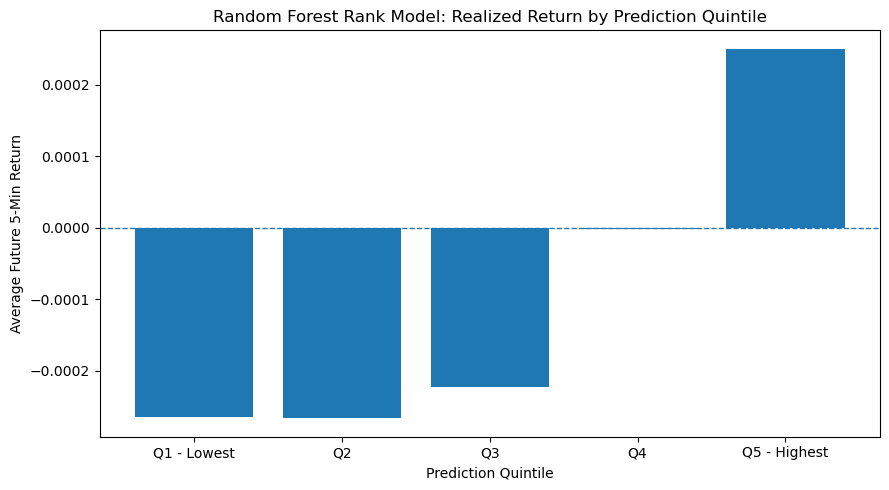

In [75]:
# ============================================================
# 18.3 Random Forest Prediction Quintiles
# ============================================================

rf_rank_pred["pred_score_rank"] = (
    rf_rank_pred
    .groupby(["date", "minute"])["pred_rank_score"]
    .rank(pct=True)
)

rf_rank_pred["prediction_quintile"] = pd.cut(
    rf_rank_pred["pred_score_rank"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 - Highest"
    ],
    include_lowest=True
)

rf_quintile_summary = (
    rf_rank_pred
    .groupby("prediction_quintile", observed=True)
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_realized_return=("future_return_5m", "mean"),
        positive_ratio=("future_return_5m", lambda x: (x > 0).mean())
    )
)

display(rf_quintile_summary)

plt.figure(figsize=(9, 5))

plt.bar(
    rf_quintile_summary.index.astype(str),
    rf_quintile_summary["avg_realized_return"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title(
    "Random Forest Rank Model: Realized Return by Prediction Quintile"
)

plt.xlabel("Prediction Quintile")
plt.ylabel("Average Future 5-Min Return")

plt.tight_layout()
plt.show()

### 18.1.1 Out-of-Sample Daily Spread and Cumulative Diagnostic

The model is evaluated not only by average Q1-Q5 separation but also by its path through time.

The daily long-short diagnostic is defined as:

```text
daily spread = average return of Q5 − average return of Q1
```

Because adjacent five-minute labels overlap, the cumulative series below is a **signal-stability diagnostic**, not a transaction-cost-adjusted trading P&L.


prediction_quintile,Q1 - Lowest,Q2,Q3,Q4,Q5 - Highest,q5_minus_q1,cumulative_spread
date,,,,,,,
2026-02-02,-0.001221,-0.002158,-0.002126,-0.001136,-0.001108,0.000113,0.000113
2026-02-03,0.001259,0.000717,0.001439,-0.000018,0.000086,-0.001173,-0.001060
2026-02-04,0.000801,-0.000116,0.000817,-0.000422,0.000496,-0.000305,-0.001365
2026-02-05,-0.003330,-0.001267,-0.000258,0.000322,0.000198,0.003528,0.002163
2026-02-06,-0.000014,0.000468,0.001021,0.000727,0.001276,0.001290,0.003453
2026-02-09,0.001624,0.000488,0.000368,0.000171,0.000318,-0.001305,0.002148
2026-02-10,-0.001095,0.000947,0.000194,0.000141,0.000278,0.001372,0.003520
2026-02-11,0.000819,0.000326,0.000527,0.000653,0.001136,0.000317,0.003837
2026-02-12,-0.001848,0.001364,0.000129,0.000215,-0.000232,0.001616,0.005453


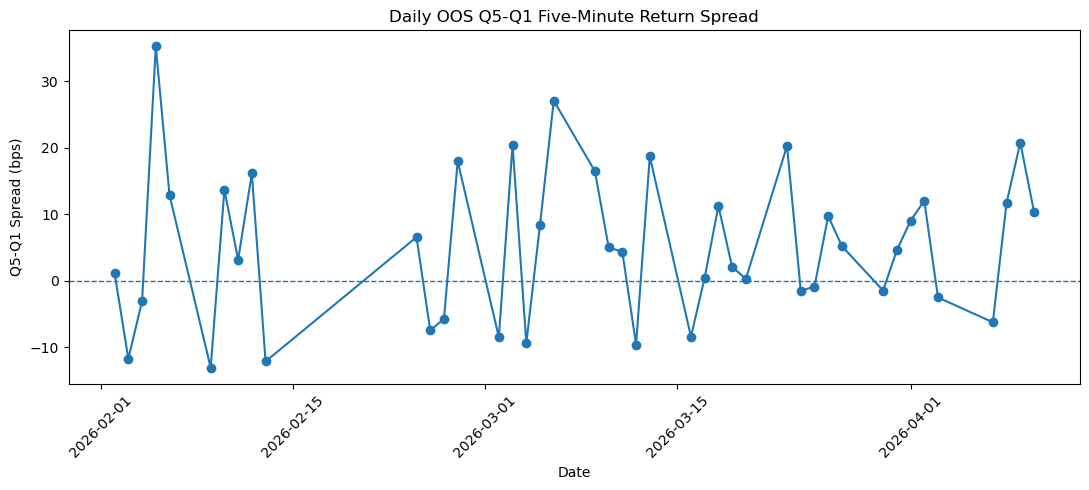

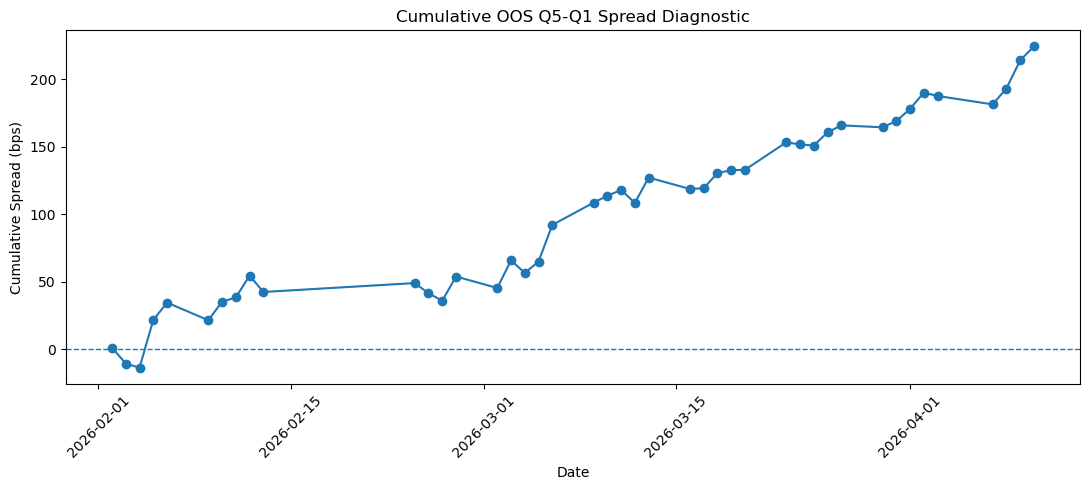

In [76]:
# ============================================================
# OOS Daily Q5-Q1 Spread
# ============================================================

daily_quintile_return = (
    rf_rank_pred
    .groupby(["date", "prediction_quintile"], observed=True)["future_return_5m"]
    .mean()
    .unstack()
)

daily_quintile_return["q5_minus_q1"] = (
    daily_quintile_return["Q5 - Highest"]
    - daily_quintile_return["Q1 - Lowest"]
)

daily_quintile_return["cumulative_spread"] = (
    daily_quintile_return["q5_minus_q1"]
    .fillna(0)
    .cumsum()
)

display(daily_quintile_return)

plt.figure(figsize=(11, 5))
plt.plot(
    daily_quintile_return.index,
    daily_quintile_return["q5_minus_q1"] * 10000,
    marker="o",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Daily OOS Q5-Q1 Five-Minute Return Spread")
plt.xlabel("Date")
plt.ylabel("Q5-Q1 Spread (bps)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(
    daily_quintile_return.index,
    daily_quintile_return["cumulative_spread"] * 10000,
    marker="o",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Cumulative OOS Q5-Q1 Spread Diagnostic")
plt.xlabel("Date")
plt.ylabel("Cumulative Spread (bps)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [77]:
# ============================================================
# 18.4 Rank-Target Ridge vs Random Forest
# ============================================================

common_dates = sorted(
    set(rank_target_pred["date"])
    & set(rf_rank_pred["date"])
)

ridge_common = rank_target_pred[
    rank_target_pred["date"].isin(common_dates)
].copy()

rf_common = rf_rank_pred[
    rf_rank_pred["date"].isin(common_dates)
].copy()


def evaluate_rank_model(df, score_col):

    pred_ic = df[score_col].corr(
        df["future_return_5m"],
        method="spearman"
    )

    daily_ic = (
        df
        .groupby("date")
        .apply(
            lambda x: x[score_col].corr(
                x["future_return_5m"],
                method="spearman"
            )
        )
        .dropna()
    )

    temp = df.copy()

    temp["pred_score_rank"] = (
        temp
        .groupby(["date", "minute"])[score_col]
        .rank(pct=True)
    )

    q1 = temp.loc[
        temp["pred_score_rank"] <= 0.2,
        "future_return_5m"
    ].mean()

    q5 = temp.loc[
        temp["pred_score_rank"] > 0.8,
        "future_return_5m"
    ].mean()

    return {
        "Prediction Rank IC": pred_ic,
        "Mean Daily IC": daily_ic.mean(),
        "Daily IC Std": daily_ic.std(),
        "ICIR": daily_ic.mean() / daily_ic.std(),
        "Q1 Return": q1,
        "Q5 Return": q5,
        "Q1-Q5 Spread": q5 - q1
    }


model_compare = pd.DataFrame({
    "Rank-Target Ridge": evaluate_rank_model(
        ridge_common,
        "pred_rank_score"
    ),
    "Random Forest": evaluate_rank_model(
        rf_common,
        "pred_rank_score"
    )
})

display(model_compare)

C:\Users\work\AppData\Local\Temp\ipykernel_24260\3131264343.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\work\AppData\Local\Temp\ipykernel_24260\3131264343.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Rank-Target Ridge,Random Forest
Prediction Rank IC,0.032334,0.042472
Mean Daily IC,0.034332,0.047420
Daily IC Std,0.043192,0.051157
ICIR,0.794862,0.926958
Q1 Return,-0.000327,-0.000453
Q5 Return,-0.000083,0.000034
Q1-Q5 Spread,0.000244,0.000487


,avg_importance,std_importance
feature,,
volatility_5m_cs_z,0.153459,0.055196
return_5m_cs_z,0.152410,0.030131
log_top_depth_cs_z,0.148213,0.063161
return_3m_cs_z,0.144783,0.039158
return_1m_cs_z,0.128270,0.018935
microprice_deviation_cs_z,0.110520,0.027450
abs_return_1m_cs_z,0.094553,0.013325
trade_sign_proxy_cs_z,0.067793,0.009411


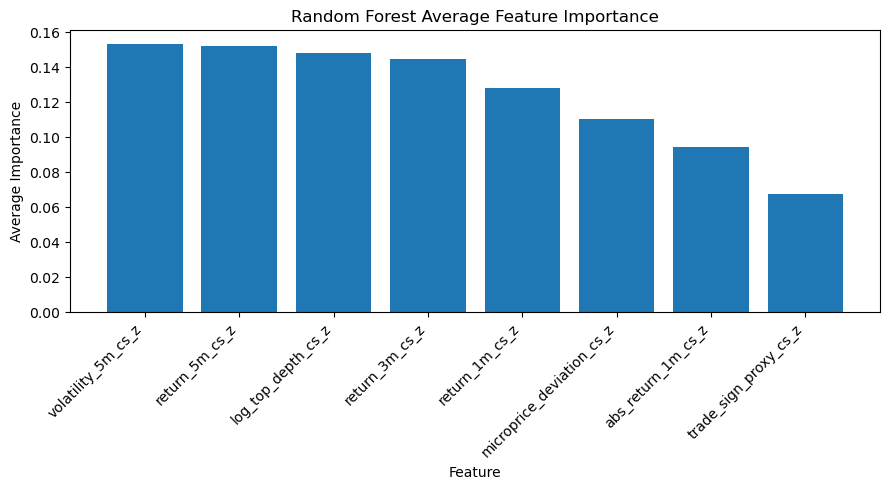

In [78]:
# ============================================================
# 18.5 Random Forest Feature Importance
# ============================================================

rf_importance_summary = (
    rf_feature_importance
    .groupby("feature")
    .agg(
        avg_importance=("importance", "mean"),
        std_importance=("importance", "std")
    )
    .sort_values("avg_importance", ascending=False)
)

display(rf_importance_summary)

plt.figure(figsize=(9, 5))

plt.bar(
    rf_importance_summary.index,
    rf_importance_summary["avg_importance"]
)

plt.title("Random Forest Average Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Average Importance")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 18.1.2 Rolling Feature-Importance Stability

Average feature importance can hide changing model dependence through time. The following heatmap tracks Random Forest importance for each rolling test date.


feature,abs_return_1m_cs_z,log_top_depth_cs_z,microprice_deviation_cs_z,return_1m_cs_z,return_3m_cs_z,return_5m_cs_z,trade_sign_proxy_cs_z,volatility_5m_cs_z
test_date,,,,,,,,
2026-02-02,0.091226,0.111151,0.137055,0.123580,0.166814,0.150274,0.062295,0.157604
2026-02-03,0.109995,0.108069,0.129197,0.119124,0.146942,0.130496,0.072048,0.184129
2026-02-04,0.100283,0.093207,0.143331,0.121377,0.144437,0.126297,0.081236,0.189832
2026-02-05,0.100632,0.099875,0.126156,0.115034,0.125114,0.134215,0.073326,0.225648
2026-02-06,0.116846,0.106398,0.104553,0.113559,0.127198,0.131557,0.065314,0.234575
2026-02-09,0.110546,0.111525,0.091520,0.104367,0.124815,0.139610,0.065043,0.252573
2026-02-10,0.103396,0.122074,0.081568,0.106454,0.136224,0.135847,0.055138,0.259300
2026-02-11,0.098656,0.142492,0.081103,0.105408,0.135678,0.131100,0.050385,0.255178
2026-02-12,0.112437,0.151202,0.086419,0.107196,0.100139,0.150837,0.053976,0.237795


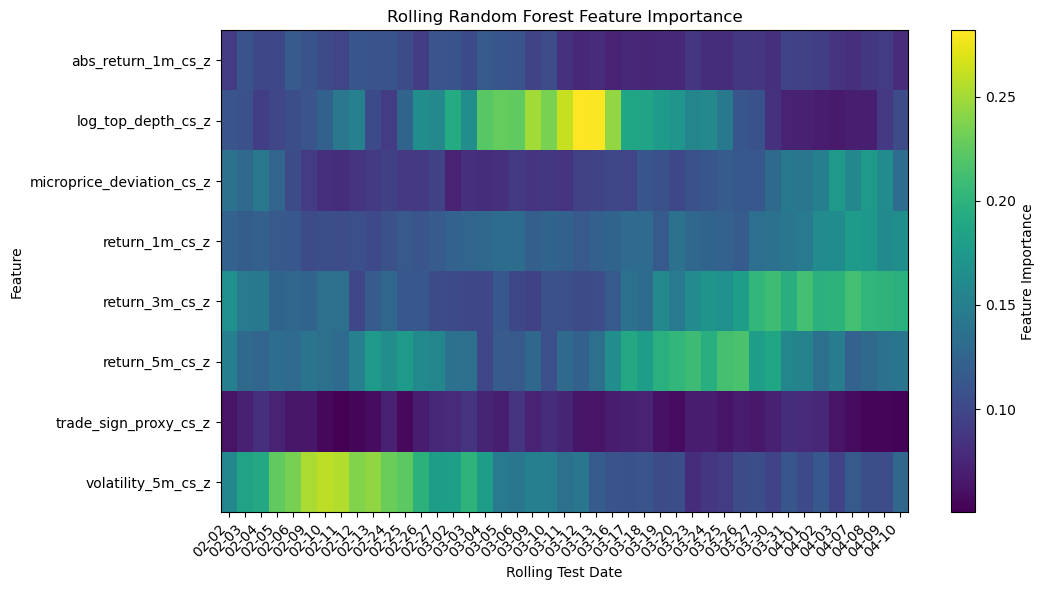

In [79]:
# ============================================================
# Rolling Feature Importance Heatmap
# ============================================================

rolling_importance_matrix = (
    rf_feature_importance
    .pivot(
        index="test_date",
        columns="feature",
        values="importance",
    )
    .sort_index()
)

display(rolling_importance_matrix)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(
    rolling_importance_matrix.T.values,
    aspect="auto",
)

ax.set_xticks(range(len(rolling_importance_matrix.index)))
ax.set_xticklabels(
    pd.to_datetime(rolling_importance_matrix.index).strftime("%m-%d"),
    rotation=45,
    ha="right",
)

ax.set_yticks(range(len(rolling_importance_matrix.columns)))
ax.set_yticklabels(rolling_importance_matrix.columns)

ax.set_xlabel("Rolling Test Date")
ax.set_ylabel("Feature")
ax.set_title("Rolling Random Forest Feature Importance")

plt.colorbar(im, ax=ax, label="Feature Importance")
plt.tight_layout()
plt.show()


### 18.1.3 Optional SHAP Interpretation

SHAP is used as a complementary interpretation tool for the final rolling-window Random Forest. It explains the direction and magnitude of feature contributions for the final test window.

This is an illustrative final-window diagnostic rather than an average explanation across every rolling model.


In [80]:
pip install shap

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


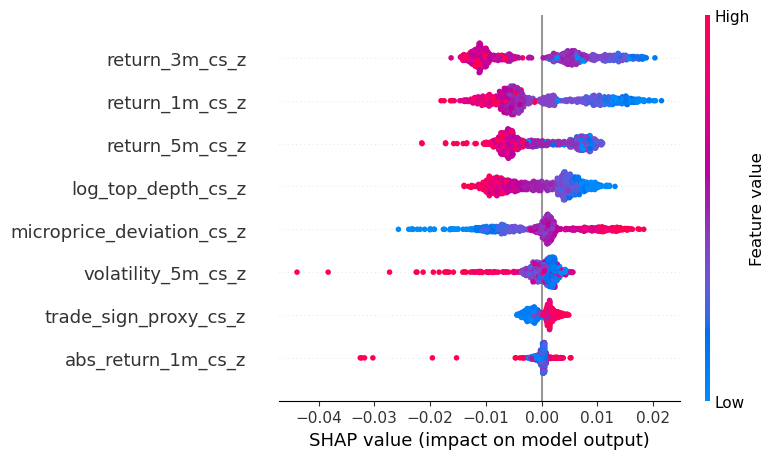

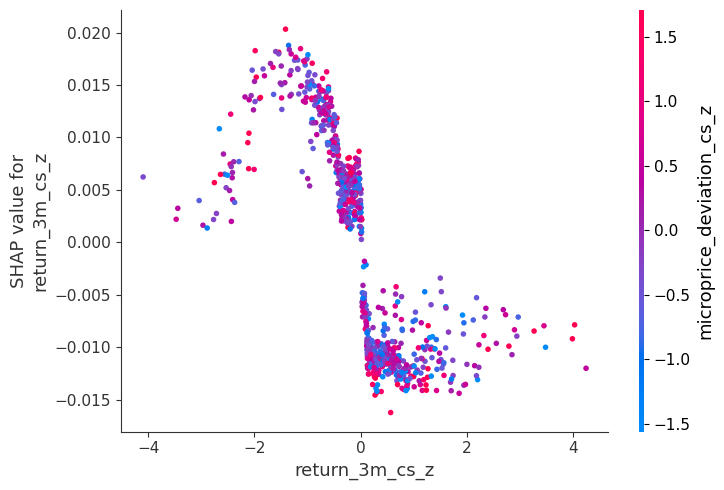

In [81]:
# ============================================================
# Optional SHAP Summary and Dependence Diagnostics
# ============================================================

try:
    import shap

    shap_test = test_part.dropna(subset=model_features).copy()
    shap_sample = shap_test.sample(
        n=min(1000, len(shap_test)),
        random_state=RANDOM_STATE,
    )

    shap_explainer = shap.TreeExplainer(rf_model)
    shap_values = shap_explainer.shap_values(
        shap_sample[model_features]
    )

    shap.summary_plot(
        shap_values,
        shap_sample[model_features],
        feature_names=model_features,
        show=False,
    )
    plt.tight_layout()
    plt.show()

    shap.dependence_plot(
        "return_3m_cs_z",
        shap_values,
        shap_sample[model_features],
        interaction_index="microprice_deviation_cs_z",
        show=False,
    )
    plt.tight_layout()
    plt.show()

except ImportError:
    print(
        "SHAP is optional and is not installed. "
        "Run `pip install shap` in the project environment to enable this section."
    )


The Rolling Random Forest improves cross-sectional ranking performance relative to the Rank-Target Ridge benchmark.

On the common expanded-sample evaluation, Prediction Rank IC increases from 0.0323 for Rank-Target Ridge to 0.0425 for Random Forest. Mean daily IC improves from 0.0343 to 0.0474, while ICIR rises from 0.79 to 0.93. The Q5-minus-Q1 realized-return spread increases from 2.44 bps to 4.87 bps.

The Q1-Q5 realized return spread also increases from 5.74 bps under Ridge to 6.95 bps under Random Forest. The improvement is primarily driven by stronger identification of future underperformers: the average Q1 return declines from -3.80 bps to -5.21 bps, while Q5 returns remain broadly similar.

Prediction quintiles are not perfectly monotonic, with Q4 underperforming Q3. Therefore, the Random Forest should not be interpreted as producing a fully ordered return forecast. However, the stronger extreme-group separation and higher ICIR indicate improved ranking quality and stability.

Feature importance suggests that the nonlinear model is not simply reproducing the short-term reversal signal. `microprice_deviation` is the most important feature, while 1-minute, 3-minute, and 5-minute returns jointly remain important. `log_top_depth` and `spread_change_1m` also contribute materially.

In contrast, `trade_sign_proxy` receives relatively low importance once price-path and order-book-state variables are included.

**Conclusion:** relaxing the globally additive linear specification improves ranking performance. The evidence supports the hypothesis that short-horizon return predictability depends on nonlinear microstructure states rather than a single stable linear factor relationship.

# Part II. Strict 09:25 → 09:30 Opening-Price Research

File 4 constructs auction and order-size features. File 5 only loads those features, constructs the strict first-quote target, and performs OOS evaluation.


In [82]:
# ============================================================
# 21.2 Construct Strict 09:30 Opening Sample
# ============================================================

OPENING_TIME = "09:30:00"

opening_feature_candidates = [
    "relative_spread",
    "log_top_depth",
    "depth_imbalance",
    "microprice_deviation"
]

opening_features = [
    feature
    for feature in opening_feature_candidates
    if feature in master_feature_df.columns
]

missing_opening_features = [
    feature
    for feature in opening_feature_candidates
    if feature not in master_feature_df.columns
]

print(
    "Opening features:",
    opening_features
)

print(
    "Missing opening features:",
    missing_opening_features
)

opening_model_df = (
    master_feature_df
    .copy()
)

opening_model_df["date"] = pd.to_datetime(
    opening_model_df["date"]
)

opening_model_df["minute"] = pd.to_datetime(
    opening_model_df["minute"]
)

opening_model_df = (
    opening_model_df[
        opening_model_df["minute"]
        .dt.strftime("%H:%M:%S")
        .eq(OPENING_TIME)
    ]
    .dropna(
        subset=(
            opening_features
            + [
                "future_return_5m",
                "mid_price"
            ]
        )
    )
    .copy()
)

opening_model_df[
    "future_return_rank"
] = (
    opening_model_df
    .groupby(
        "date"
    )["future_return_5m"]
    .rank(
        pct=True,
        method="average"
    )
)

print(
    "Opening observations:",
    len(opening_model_df)
)

print(
    "Opening dates:",
    opening_model_df["date"].nunique()
)

print(
    "Opening stocks:",
    opening_model_df["code"].nunique()
)

display(
    opening_model_df[
        [
            "date",
            "minute",
            "code",
            "mid_price"
        ]
        + opening_features
        + [
            "future_return_5m",
            "future_return_rank"
        ]
    ].head()
)

Opening features: ['relative_spread', 'log_top_depth', 'depth_imbalance', 'microprice_deviation']
Missing opening features: []
Opening observations: 2506
Opening dates: 63
Opening stocks: 40


,date,minute,code,mid_price,relative_spread,log_top_depth,depth_imbalance,microprice_deviation,future_return_5m,future_return_rank
0,2026-01-05,2026-01-05 09:30:00,000713.SZ,6.625,0.001509,11.515931,0.154536,0.000117,0.001509,0.525000
26,2026-01-06,2026-01-06 09:30:00,000713.SZ,6.675,0.001498,12.163170,-0.219207,-0.000164,0.005993,0.625000
52,2026-01-07,2026-01-07 09:30:00,000713.SZ,6.745,0.001483,10.034560,0.508772,0.000377,0.000000,0.435897
77,2026-01-08,2026-01-08 09:30:00,000713.SZ,6.725,0.001487,10.138599,0.976285,0.000726,0.004461,0.512821
102,2026-01-09,2026-01-09 09:30:00,000713.SZ,6.745,0.001483,11.388960,-0.760018,-0.000563,0.002965,0.475000


In [86]:
# ============================================================
# 22.1 Load File 4 Auction Feature Table
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

AUCTION_FEATURE_CANDIDATES = [
    # 优先读取File4最后导出的完整表
    Path("04_auction_feature_table.csv"),
    Path("../notebooks/04_auction_feature_table.csv"),

    # 旧版本只作为fallback
    Path("../notebooks/auction_features_prediction_ready.csv"),

    Path(
        r"C:\Users\work\OneDrive\Documents"
        r"\level2-research\notebooks\04_auction_feature_table.csv"
    ),
]

AUCTION_FEATURE_PATH = next(
    (path for path in AUCTION_FEATURE_CANDIDATES if path.exists()),
    None,
)
if AUCTION_FEATURE_PATH is None:
    raise FileNotFoundError(
        "Run the organized File 4 export first, then update AUCTION_FEATURE_CANDIDATES."
    )

auction_feature_df = pd.read_csv(AUCTION_FEATURE_PATH)

# Standardize primary keys
auction_feature_df["code"] = (
    auction_feature_df["code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

auction_feature_df["date"] = (
    pd.to_datetime(
        auction_feature_df["date"],
        errors="coerce"
    )
    .dt.normalize()
)

# Columns that should not be forcibly converted to numeric
NON_NUMERIC_COLUMNS = {
    "code",
    "date",
    "auction_price_consistent"
}

# Define numeric feature columns directly from the CSV
auction_numeric_cols = [
    column
    for column in auction_feature_df.columns
    if column not in NON_NUMERIC_COLUMNS
]

# Convert File 4 features to numeric
auction_feature_df[auction_numeric_cols] = (
    auction_feature_df[auction_numeric_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# Convert boolean consistency flag separately
if "auction_price_consistent" in auction_feature_df.columns:
    auction_feature_df["auction_price_consistent"] = (
        auction_feature_df["auction_price_consistent"]
        .astype(str)
        .str.lower()
        .map({
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0
        })
    )

# Primary-key validation
duplicate_keys = auction_feature_df.duplicated(
    ["code", "date"]
).sum()

print("Auction feature shape:", auction_feature_df.shape)
print("Auction stocks:", auction_feature_df["code"].nunique())
print("Auction dates:", auction_feature_df["date"].nunique())
print("Duplicate code-date rows:", duplicate_keys)

assert duplicate_keys == 0, (
    "File 4 contains duplicate code-date rows."
)

# Required fields for boss-directed analysis
required_auction_columns = [
    "code",
    "date",
    "auction_price",
    "auction_trade_volume",
    "auction_trade_amount",
    "prev_day_return"
]

missing_required_columns = [
    column
    for column in required_auction_columns
    if column not in auction_feature_df.columns
]

assert not missing_required_columns, (
    "Missing required File 4 columns: "
    f"{missing_required_columns}"
)

# Price-scale check
auction_price_summary = (
    auction_feature_df["auction_price"]
    .describe()
    .to_frame("auction_price")
)

display(auction_price_summary)

median_auction_price = (
    auction_feature_df["auction_price"]
    .median()
)

assert median_auction_price < 1000, (
    "auction_price appears to remain in raw QKNOCK units."
)

preview_columns = [
    "code",
    "date",
    "auction_price",
    "auction_trade_volume",
    "auction_trade_amount",
    "prev_day_return",
    "has_auction_execution",
    "large_order_amount_share",
    "large_order_imbalance",
    "post920_large_order_imbalance"
]

preview_columns = [
    column
    for column in preview_columns
    if column in auction_feature_df.columns
]

print("Loaded file:", AUCTION_FEATURE_PATH.resolve())
print("Loaded columns:", len(auction_feature_df.columns))

display(
    auction_feature_df[
        preview_columns
    ].head(10)
)

Auction feature shape: (2520, 81)
Auction stocks: 40
Auction dates: 63
Duplicate code-date rows: 0


,auction_price
count,2504.000000
mean,32.596554
std,40.214437
min,3.090000
25%,10.085000
50%,16.200000
75%,39.782500
max,271.970000


Loaded file: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04_auction_feature_table.csv
Loaded columns: 81


,code,date,auction_price,auction_trade_volume,auction_trade_amount,prev_day_return,has_auction_execution,large_order_amount_share,large_order_imbalance,post920_large_order_imbalance
0,000713.SZ,2026-01-05,6.63,27900.0,184977.0,NaN,1,0.297778,-1.000000,-1.0
1,000713.SZ,2026-01-06,6.70,24200.0,162140.0,0.009063,1,0.404593,-1.000000,-1.0
2,000713.SZ,2026-01-07,6.73,24800.0,166904.0,0.010479,1,0.295135,-0.727842,1.0
3,000713.SZ,2026-01-08,6.74,36240.0,244257.6,-0.001481,1,0.367789,-1.000000,0.0
4,000713.SZ,2026-01-09,6.73,54700.0,368131.0,0.002967,1,0.305438,-1.000000,0.0
5,000713.SZ,2026-01-12,6.77,58600.0,396722.0,0.002959,1,0.279774,-1.000000,-1.0
6,000713.SZ,2026-01-13,6.83,143300.0,978739.0,0.008850,1,0.210196,-0.808953,-1.0
7,000713.SZ,2026-01-14,6.80,50500.0,343400.0,-0.005848,1,0.318621,-0.835717,-1.0
8,000713.SZ,2026-01-15,6.77,60800.0,411616.0,-0.007353,1,0.435075,-1.000000,-1.0
9,000713.SZ,2026-01-16,6.82,26300.0,179366.0,0.005926,1,0.373856,-0.850613,-1.0


In [87]:
# ============================================================
# 22.2 Select Economically Distinct Auction Features
# ============================================================

auction_feature_candidates = [
    # --------------------------------------------------------
    # mechanism 1: auction price overreaction
    # --------------------------------------------------------
    "auction_price",
    "auction_vwap",
    "auction_min_price",
    "auction_max_price",
    "auction_price_consistent",

    # --------------------------------------------------------
    # Directional order pressure
    # --------------------------------------------------------
    "submit_imbalance",
    "post920_submit_imbalance",
    "last_minute_submit_imbalance",
    "final_depth_imbalance",
    "net_pressure_to_depth",
    "pressure_intensity_to_depth",

    # --------------------------------------------------------
    # Auction updating and cancellation
    # --------------------------------------------------------
    "post920_volume_share",
    "imbalance_shift",
    "imbalance_reversal",
    "cancel_volume_ratio",
    "cancel_rate_by_order",

    # --------------------------------------------------------
    # Belief divergence
    # --------------------------------------------------------
    "buy_price_divergence",
    "sell_price_divergence",
    "buy_sell_divergence_gap",

    # --------------------------------------------------------
    # Order-size concentration proxies
    # 注意：只能解释为 institutional-like proxy
    # --------------------------------------------------------
    "largest_order_share",
    "order_size_hhi",
    "large_order_amount_share",
    "large_order_count_share",
    "large_order_imbalance",
    "small_order_imbalance",
    "post920_large_order_imbalance",
    "top5_order_amount_share",
    "order_amount_hhi",
    "max_submit_size",
    "avg_submit_size",

    # --------------------------------------------------------
    # Auction price discovery
    # --------------------------------------------------------
    "auction_price_range",
    "auction_price_volatility",
    "last_minute_price_change",
    "price_reversal_rate",
    "n_price_revisions",
    "convergence_speed",
    "price_path_smoothness",

    # --------------------------------------------------------
    # Actual auction execution
    # --------------------------------------------------------
    "auction_trade_count",
    "auction_trade_volume",
    "auction_trade_amount",
    "has_auction_execution",

    # --------------------------------------------------------
    # Historical controls from File 4
    # --------------------------------------------------------
    "prev_day_return",
    "prev_day_amount",
    "rolling_5d_vol",
    "rolling_5d_amount"
]

auction_features = [
    feature
    for feature in auction_feature_candidates
    if feature in auction_feature_df.columns
]

missing_auction_features = [
    feature
    for feature in auction_feature_candidates
    if feature not in auction_feature_df.columns
]

print("Available auction features:", len(auction_features))
print(auction_features)

print("\nMissing candidate features:")
print(missing_auction_features)

assert "auction_price" in auction_features

Available auction features: 45
['auction_price', 'auction_vwap', 'auction_min_price', 'auction_max_price', 'auction_price_consistent', 'submit_imbalance', 'post920_submit_imbalance', 'last_minute_submit_imbalance', 'final_depth_imbalance', 'net_pressure_to_depth', 'pressure_intensity_to_depth', 'post920_volume_share', 'imbalance_shift', 'imbalance_reversal', 'cancel_volume_ratio', 'cancel_rate_by_order', 'buy_price_divergence', 'sell_price_divergence', 'buy_sell_divergence_gap', 'largest_order_share', 'order_size_hhi', 'large_order_amount_share', 'large_order_count_share', 'large_order_imbalance', 'small_order_imbalance', 'post920_large_order_imbalance', 'top5_order_amount_share', 'order_amount_hhi', 'max_submit_size', 'avg_submit_size', 'auction_price_range', 'auction_price_volatility', 'last_minute_price_change', 'price_reversal_rate', 'n_price_revisions', 'convergence_speed', 'price_path_smoothness', 'auction_trade_count', 'auction_trade_volume', 'auction_trade_amount', 'has_auction

In [88]:
# ============================================================
# Merge File 4 Auction Features into the Strict Opening Sample
# ============================================================
opening_model_df["date"] = pd.to_datetime(opening_model_df["date"]).dt.normalize()
auction_feature_df["date"] = pd.to_datetime(auction_feature_df["date"]).dt.normalize()

opening_auction_df = opening_model_df.merge(
    auction_feature_df,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
    indicator=True,
)
merge_coverage = opening_auction_df["_merge"].eq("both").mean()
print("Auction merge coverage:", f"{merge_coverage:.2%}")
assert merge_coverage > 0.90
opening_auction_df = opening_auction_df.drop(columns="_merge")


Auction merge coverage: 100.00%


In [89]:
# ============================================================
# Boss-Directed, Leakage-Safe Feature Engineering
# ============================================================
opening_auction_df = opening_auction_df.sort_values(["code", "date"]).copy()
opening_auction_df["auction_return"] = (
    opening_auction_df["auction_price"] / opening_auction_df["pre_close"] - 1
)
opening_auction_df["abs_auction_return"] = opening_auction_df["auction_return"].abs()
opening_auction_df["auction_return_squared"] = opening_auction_df["auction_return"] ** 2

for raw_col, prefix_name in [
    ("auction_trade_volume", "auction_volume"),
    ("auction_trade_amount", "auction_amount"),
]:
    prior_mean = opening_auction_df.groupby("code")[raw_col].transform(
        lambda s: s.shift(1).rolling(5, min_periods=3).mean()
    )
    prior_std = opening_auction_df.groupby("code")[raw_col].transform(
        lambda s: s.shift(1).rolling(5, min_periods=3).std()
    )
    opening_auction_df[f"{prefix_name}_ratio_5d"] = safe_divide(
        opening_auction_df[raw_col], prior_mean
    )
    opening_auction_df[f"{prefix_name}_zscore_5d"] = safe_divide(
        opening_auction_df[raw_col] - prior_mean, prior_std
    )

for feature in [
    "auction_volume_ratio_5d", "final_depth_imbalance",
    "post920_submit_imbalance", "large_order_imbalance",
    "post920_large_order_imbalance",
]:
    if feature in opening_auction_df.columns:
        opening_auction_df[f"auction_return_x_{feature}"] = (
            opening_auction_df["auction_return"] * opening_auction_df[feature]
        )


In [90]:
# ============================================================
# Construct Strict 09:30 First-Quote Anchor
# Must run after qtick has been loaded
# ============================================================

assert "qtick" in globals(), (
    "qtick is not defined. Run the qtick loading cells first."
)

strict_open_ticks = qtick.copy()

# ------------------------------------------------------------
# Create datetime if necessary
# ------------------------------------------------------------

if "datetime" not in strict_open_ticks.columns:

    date_string = (
        pd.to_datetime(
            strict_open_ticks["date"],
            errors="coerce"
        )
        .dt.strftime("%Y-%m-%d")
    )

    time_string = (
        strict_open_ticks["time"]
        .astype(str)
        .str.replace("1970-01-01 ", "", regex=False)
        .str.replace("1900-01-01 ", "", regex=False)
    )

    strict_open_ticks["datetime"] = pd.to_datetime(
        date_string + " " + time_string,
        errors="coerce"
    )

# ------------------------------------------------------------
# Normalize key columns
# ------------------------------------------------------------

strict_open_ticks["date"] = (
    pd.to_datetime(
        strict_open_ticks["date"],
        errors="coerce"
    )
    .dt.normalize()
)

strict_open_ticks["code"] = (
    strict_open_ticks["code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# ------------------------------------------------------------
# Build valid midpoint
# ------------------------------------------------------------

strict_open_ticks["bp0"] = (
    pd.to_numeric(
        strict_open_ticks["bp0"],
        errors="coerce"
    )
    .replace(0, np.nan)
)

strict_open_ticks["ap0"] = (
    pd.to_numeric(
        strict_open_ticks["ap0"],
        errors="coerce"
    )
    .replace(0, np.nan)
)

strict_open_ticks["strict_open_mid_price"] = (
    strict_open_ticks["bp0"]
    + strict_open_ticks["ap0"]
) / 2

# ------------------------------------------------------------
# Select 09:30:00–09:30:59
# ------------------------------------------------------------

open_start_timestamp = (
    strict_open_ticks["date"]
    + pd.Timedelta(hours=9, minutes=30)
)

open_end_timestamp = (
    strict_open_ticks["date"]
    + pd.Timedelta(hours=9, minutes=31)
)

strict_open_ticks = strict_open_ticks[
    strict_open_ticks["datetime"].ge(open_start_timestamp)
    & strict_open_ticks["datetime"].lt(open_end_timestamp)
    & strict_open_ticks["strict_open_mid_price"].notna()
    & strict_open_ticks["strict_open_mid_price"].gt(0)
].copy()

# ------------------------------------------------------------
# First valid quote for every stock-date
# ------------------------------------------------------------

strict_open_anchor = (
    strict_open_ticks
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date"], as_index=False)
    .first()[
        [
            "code",
            "date",
            "datetime",
            "strict_open_mid_price"
        ]
    ]
    .rename(
        columns={
            "datetime": "strict_open_timestamp"
        }
    )
)

strict_open_anchor["seconds_after_0930"] = (
    strict_open_anchor["strict_open_timestamp"]
    - (
        strict_open_anchor["date"]
        + pd.Timedelta(hours=9, minutes=30)
    )
).dt.total_seconds()

print("strict_open_anchor created:", "strict_open_anchor" in globals())
print("Shape:", strict_open_anchor.shape)
print("Stocks:", strict_open_anchor["code"].nunique())
print("Dates:", strict_open_anchor["date"].nunique())

display(strict_open_anchor.head(10))

display(
    strict_open_anchor["seconds_after_0930"]
    .describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)

strict_open_anchor created: True
Shape: (2514, 5)
Stocks: 40
Dates: 63


,code,date,strict_open_timestamp,strict_open_mid_price,seconds_after_0930
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.635,0.0
1,000713.SZ,2026-01-06,2026-01-06 09:30:00,6.695,0.0
2,000713.SZ,2026-01-07,2026-01-07 09:30:00,6.745,0.0
3,000713.SZ,2026-01-08,2026-01-08 09:30:00,6.745,0.0
4,000713.SZ,2026-01-09,2026-01-09 09:30:00,6.735,0.0
5,000713.SZ,2026-01-12,2026-01-12 09:30:00,6.775,0.0
6,000713.SZ,2026-01-13,2026-01-13 09:30:00,6.855,0.0
7,000713.SZ,2026-01-14,2026-01-14 09:30:00,6.815,0.0
8,000713.SZ,2026-01-15,2026-01-15 09:30:00,6.765,0.0
9,000713.SZ,2026-01-16,2026-01-16 09:30:00,6.855,0.0


count    2514.000000
mean        0.798329
std         1.221370
min         0.000000
50%         0.000000
90%         3.000000
95%         3.000000
99%         5.000000
max         7.000000
Name: seconds_after_0930, dtype: float64

In [95]:
# ============================================================
# Merge Strict First Quote and Build the 09:25 -> 09:30 Target
# ============================================================
auction_open_df = opening_auction_df.drop(
    columns=["strict_open_timestamp", "strict_open_mid_price", "seconds_after_0930"],
    errors="ignore",
).merge(
    strict_open_anchor,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)

MAX_OPEN_DELAY_SECONDS = 10
auction_open_df = auction_open_df.loc[
    auction_open_df["strict_open_mid_price"].notna()
    & auction_open_df["seconds_after_0930"].between(0, MAX_OPEN_DELAY_SECONDS)
].copy()
auction_open_df["actual_open_price"] = auction_open_df["strict_open_mid_price"]
auction_open_df["target_auction_to_open_return"] = (
    auction_open_df["actual_open_price"] / auction_open_df["auction_price"] - 1
)
print("Strict opening sample:", auction_open_df.shape)


Strict opening sample: (2506, 163)


In [96]:
# ============================================================
# Reusable Strict-Opening Single-Factor Evaluation
# ============================================================

def evaluate_opening_factors(
    data,
    features,
    target="target_auction_to_open_return"
):
    rows = []

    available_features = [
        feature
        for feature in dict.fromkeys(features)
        if feature in data.columns
    ]

    for feature in available_features:

        factor_df = (
            data[
                [
                    "date",
                    "code",
                    feature,
                    target
                ]
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .dropna()
            .copy()
        )

        if (
            factor_df.empty
            or factor_df[feature].nunique() < 2
        ):
            continue

        def calculate_daily_ic(day_df):

            if (
                day_df[feature].nunique() < 2
                or day_df[target].nunique() < 2
            ):
                return np.nan

            return day_df[feature].corr(
                day_df[target],
                method="spearman"
            )

        daily_ic = (
            factor_df
            .groupby("date")
            .apply(
                calculate_daily_ic,
                include_groups=False
            )
            .dropna()
        )

        factor_df["daily_percentile"] = (
            factor_df
            .groupby("date")[feature]
            .rank(
                pct=True,
                method="average"
            )
        )

        bottom_return = factor_df.loc[
            factor_df["daily_percentile"] <= 0.20,
            target
        ].mean()

        top_return = factor_df.loc[
            factor_df["daily_percentile"] >= 0.80,
            target
        ].mean()

        daily_ic_std = daily_ic.std()

        rows.append({
            "feature": feature,
            "n_obs": len(factor_df),
            "n_dates": factor_df["date"].nunique(),

            "pooled_rank_ic": (
                factor_df[feature]
                .corr(
                    factor_df[target],
                    method="spearman"
                )
            ),

            "mean_daily_ic": daily_ic.mean(),

            "icir": (
                daily_ic.mean() / daily_ic_std
                if daily_ic_std > 0
                else np.nan
            ),

            "positive_daily_ic_ratio": (
                (daily_ic > 0).mean()
            ),

            "top_bottom_spread_bps": (
                top_return
                - bottom_return
            ) * 10000
        })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    return (
        result
        .sort_values(
            "mean_daily_ic",
            key=lambda series: series.abs(),
            ascending=False
        )
        .reset_index(drop=True)
    )

In [97]:
# ============================================================
# Auction-Mechanism Single-Factor Evaluation
# ============================================================

auction_mechanism_feature_candidates = [
    # Auction-price deviation
    "auction_return",
    "positive_auction_gap",
    "negative_auction_gap",
    "abs_auction_gap",
    "auction_gap_squared",

    # Nonlinear auction-price deviation
    "auction_high_1pct",
    "auction_high_2pct",
    "auction_high_3pct",
    "auction_excess_above_1pct",
    "auction_excess_above_2pct",
    "auctionauction_excess_above_3pct",

    # Historical relative participation
    "auction_volume_ratio_5d",
    "auction_volume_zscore_5d",
    "auction_amount_ratio_5d",
    "auction_amount_zscore_5d",

    # Order-book support
    "post920_submit_imbalance",
    "final_depth_imbalance",

    # Auction gap × order-book support
    "positive_gap_x_post920_submit_imbalance",
    "positive_gap_x_final_depth_imbalance",
    "high3pct_x_post920_submit_imbalance",
    "high3pct_x_final_depth_imbalance",

    # Large-order proxies
    "large_order_amount_share",
    "large_order_count_share",
    "large_order_imbalance",
    "small_order_imbalance",
    "post920_large_order_imbalance",
    "top5_order_amount_share",
    "order_amount_hhi"
]

auction_mechanism_features = [
    feature
    for feature in auction_mechanism_feature_candidates
    if feature in auction_open_df.columns
]

missing_auction_mechanism_features = [
    feature
    for feature in auction_mechanism_feature_candidates
    if feature not in auction_open_df.columns
]

print(
    "Available auction-mechanism features:",
    auction_mechanism_features
)

print(
    "\nUnavailable auction-mechanism features:",
    missing_auction_mechanism_features
)

auction_mechanism_factor_summary = (
    evaluate_opening_factors(
        data=auction_open_df,
        features=auction_mechanism_features,
        target="target_auction_to_open_return"
    )
)

display(auction_mechanism_factor_summary)

Available auction-mechanism features: ['auction_return', 'auction_volume_ratio_5d', 'auction_volume_zscore_5d', 'auction_amount_ratio_5d', 'auction_amount_zscore_5d', 'post920_submit_imbalance', 'final_depth_imbalance', 'large_order_amount_share', 'large_order_count_share', 'large_order_imbalance', 'small_order_imbalance', 'post920_large_order_imbalance', 'top5_order_amount_share', 'order_amount_hhi']

Unavailable auction-mechanism features: ['positive_auction_gap', 'negative_auction_gap', 'abs_auction_gap', 'auction_gap_squared', 'auction_high_1pct', 'auction_high_2pct', 'auction_high_3pct', 'auction_excess_above_1pct', 'auction_excess_above_2pct', 'auctionauction_excess_above_3pct', 'positive_gap_x_post920_submit_imbalance', 'positive_gap_x_final_depth_imbalance', 'high3pct_x_post920_submit_imbalance', 'high3pct_x_final_depth_imbalance']


,feature,n_obs,n_dates,pooled_rank_ic,mean_daily_ic,icir,positive_daily_ic_ratio,top_bottom_spread_bps
0,post920_submit_imbalance,2490,63,0.324664,0.293107,1.788926,0.968254,33.630591
1,final_depth_imbalance,2490,63,0.270458,0.259519,1.827216,0.952381,22.458416
2,small_order_imbalance,2490,63,0.255348,0.231740,1.227179,0.873016,25.166056
3,auction_return,2490,63,-0.078183,-0.216567,-1.156178,0.111111,-30.411935
4,post920_large_order_imbalance,2490,63,0.133134,0.119045,0.748544,0.793651,18.381669
5,large_order_imbalance,2490,63,0.091416,0.069076,0.412985,0.666667,12.266316
6,large_order_amount_share,2490,63,0.044413,0.051990,0.310894,0.619048,3.431226
7,order_amount_hhi,2490,63,-0.048301,-0.046134,-0.276879,0.412698,-5.057969
8,top5_order_amount_share,2490,63,-0.046894,-0.045130,-0.271381,0.412698,-5.632510
9,auction_volume_ratio_5d,2370,60,0.018860,0.030771,0.178829,0.566667,3.158916


In [98]:
# ============================================================
# Strict 09:30 Target Validation
# ============================================================

strict_target_check = pd.DataFrame({
    "metric": [
        "n_observations",
        "n_stocks",
        "n_dates",
        "open_delay_mean_seconds",
        "open_delay_median_seconds",
        "open_delay_p95_seconds",
        "open_delay_max_seconds",
        "auction_return_mean_bps",
        "target_return_mean_bps",
        "target_return_std_bps"
    ],
    "value": [
        len(auction_open_df),
        auction_open_df["code"].nunique(),
        auction_open_df["date"].nunique(),
        auction_open_df["seconds_after_0930"].mean(),
        auction_open_df["seconds_after_0930"].median(),
        auction_open_df["seconds_after_0930"].quantile(0.95),
        auction_open_df["seconds_after_0930"].max(),
        auction_open_df["auction_return"].mean() * 10000,
        auction_open_df[
            "target_auction_to_open_return"
        ].mean() * 10000,
        auction_open_df[
            "target_auction_to_open_return"
        ].std() * 10000
    ]
})

display(strict_target_check)

display(
    auction_open_df[
        [
            "auction_return",
            "target_auction_to_open_return",
            "seconds_after_0930"
        ]
    ].describe(
        percentiles=[
            0.01, 0.05, 0.10, 0.50,
            0.90, 0.95, 0.99
        ]
    ).T
)

,metric,value
0,n_observations,2506.000000
1,n_stocks,40.000000
2,n_dates,63.000000
3,open_delay_mean_seconds,0.797686
4,open_delay_median_seconds,0.000000
5,open_delay_p95_seconds,3.000000
6,open_delay_max_seconds,7.000000
7,auction_return_mean_bps,-3.193783
8,target_return_mean_bps,2.679187
9,target_return_std_bps,42.790429


,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
auction_return,2490.0,-0.000319,0.013897,-0.135360,-0.038569,-0.020373,-0.014420,0.000000,0.015550,0.021519,0.039029,0.089680
target_auction_to_open_return,2490.0,0.000268,0.004279,-0.032609,-0.012910,-0.005914,-0.003825,0.000337,0.004469,0.006617,0.012476,0.038354
seconds_after_0930,2506.0,0.797686,1.222612,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,5.000000,7.000000


In [99]:
# ============================================================
# Rebuild Nonlinear Auction Features on Strict Sample
# ============================================================

auction_open_df["positive_auction_gap"] = (
    auction_open_df["auction_return"]
    .clip(lower=0)
)

auction_open_df["negative_auction_gap"] = (
    (-auction_open_df["auction_return"])
    .clip(lower=0)
)

auction_open_df["abs_auction_gap"] = (
    auction_open_df["auction_return"].abs()
)

auction_open_df["auction_gap_squared"] = (
    auction_open_df["auction_return"] ** 2
)

for threshold in [0.01, 0.02, 0.03]:

    threshold_pct = int(threshold * 100)

    auction_open_df[
        f"auction_high_{threshold_pct}pct"
    ] = (
        auction_open_df["auction_return"]
        .ge(threshold)
        .astype(int)
    )

    auction_open_df[
        f"auction_excess_above_{threshold_pct}pct"
    ] = (
        auction_open_df["auction_return"]
        - threshold
    ).clip(lower=0)

support_features = [
    feature
    for feature in [
        "auction_volume_ratio_5d",
        "auction_amount_ratio_5d",
        "auction_volume_zscore_5d",
        "auction_amount_zscore_5d",
        "final_depth_imbalance",
        "post920_submit_imbalance",
        "largest_order_share",
        "order_size_hhi"
    ]
    if feature in auction_open_df.columns
]

for feature in support_features:

    auction_open_df[
        f"positive_gap_x_{feature}"
    ] = (
        auction_open_df["positive_auction_gap"]
        * auction_open_df[feature]
    )

    auction_open_df[
        f"high3pct_x_{feature}"
    ] = (
        auction_open_df["auction_high_3pct"]
        * auction_open_df[feature]
    )

print("Support features:", support_features)

Support features: ['auction_volume_ratio_5d', 'auction_amount_ratio_5d', 'auction_volume_zscore_5d', 'auction_amount_zscore_5d', 'final_depth_imbalance', 'post920_submit_imbalance', 'largest_order_share', 'order_size_hhi']


In [100]:
# ============================================================
# Strict 09:30 Single-Factor Evaluation
# ============================================================

strict_factor_features = [
    # Main auction gap
    "auction_return",
    "positive_auction_gap",
    "negative_auction_gap",

    # Nonlinear thresholds
    "auction_high_1pct",
    "auction_high_2pct",
    "auction_high_3pct",
    "auction_excess_above_1pct",
    "auction_excess_above_2pct",
    "auction_excess_above_3pct",

    # Funding support
    "auction_volume_ratio_5d",
    "auction_amount_ratio_5d",
    "auction_volume_zscore_5d",
    "auction_amount_zscore_5d",

    # Order-book support
    "final_depth_imbalance",
    "post920_submit_imbalance",

    # Main interactions
    "positive_gap_x_auction_volume_ratio_5d",
    "positive_gap_x_auction_amount_ratio_5d",
    "positive_gap_x_final_depth_imbalance",
    "positive_gap_x_post920_submit_imbalance",
    "high3pct_x_auction_volume_ratio_5d",
    "high3pct_x_auction_amount_ratio_5d",
    "high3pct_x_final_depth_imbalance",
    "high3pct_x_post920_submit_imbalance"
]

strict_factor_features = [
    feature
    for feature in strict_factor_features
    if feature in auction_open_df.columns
]

strict_open_factor_summary = evaluate_opening_factors(
    data=auction_open_df,
    features=strict_factor_features,
    target="target_auction_to_open_return"
)

display(strict_open_factor_summary)

,feature,n_obs,n_dates,pooled_rank_ic,mean_daily_ic,icir,positive_daily_ic_ratio,top_bottom_spread_bps
0,post920_submit_imbalance,2490,63,0.324664,0.293107,1.788926,0.968254,33.630591
1,final_depth_imbalance,2490,63,0.270458,0.259519,1.827216,0.952381,22.458416
2,auction_return,2490,63,-0.078183,-0.216567,-1.156178,0.111111,-30.411935
3,positive_gap_x_post920_submit_imbalance,2490,63,0.181510,0.208169,1.301553,0.903226,27.332312
4,negative_auction_gap,2490,63,0.064928,0.169011,0.898851,0.790323,29.149225
5,positive_auction_gap,2490,63,-0.054675,-0.168636,-0.876383,0.177419,-30.826494
6,positive_gap_x_final_depth_imbalance,2490,63,0.165086,0.164178,1.116939,0.854839,21.148858
7,positive_gap_x_auction_amount_ratio_5d,2370,60,-0.056476,-0.157957,-0.769288,0.220339,-30.253474
8,positive_gap_x_auction_volume_ratio_5d,2370,60,-0.056154,-0.157941,-0.772529,0.220339,-30.614603
9,high3pct_x_post920_submit_imbalance,2490,63,0.084454,0.123607,0.716686,0.806452,81.184869


In [101]:
# ============================================================
# Strict 09:30 OOS Model Feature Sets
# ============================================================

gap_features = [
    "auction_return",
    "positive_auction_gap",
    "negative_auction_gap",
    "auction_high_1pct",
    "auction_high_2pct",
    "auction_high_3pct",
    "auction_excess_above_1pct",
    "auction_excess_above_2pct",
    "auction_excess_above_3pct"
]

order_support_features = [
    "post920_submit_imbalance",
    "final_depth_imbalance",
    "positive_gap_x_post920_submit_imbalance",
    "positive_gap_x_final_depth_imbalance",
    "high3pct_x_post920_submit_imbalance",
    "high3pct_x_final_depth_imbalance"
]

participation_features = [
    "auction_volume_ratio_5d",
    "auction_amount_ratio_5d",
    "auction_volume_zscore_5d",
    "auction_amount_zscore_5d",
    "positive_gap_x_auction_volume_ratio_5d",
    "positive_gap_x_auction_amount_ratio_5d",
    "high3pct_x_auction_volume_ratio_5d",
    "high3pct_x_auction_amount_ratio_5d"
]

def available_features(features, data=auction_open_df):
    return list(dict.fromkeys([
        feature
        for feature in features
        if feature in data.columns
    ]))


open_price_feature_sets = {
    # Simple economic baseline
    "Auction Gap Only": available_features(
        gap_features
    ),

    # Main boss mechanism
    "Gap + Order Support": available_features(
        gap_features
        + order_support_features
    ),

    # Full available mechanism
    "Gap + Order + Participation": available_features(
        gap_features
        + order_support_features
        + participation_features
    )
}

for model_name, features in open_price_feature_sets.items():
    print(
        model_name,
        "—",
        len(features),
        "features"
    )
    print(features)
    print()

Auction Gap Only — 9 features
['auction_return', 'positive_auction_gap', 'negative_auction_gap', 'auction_high_1pct', 'auction_high_2pct', 'auction_high_3pct', 'auction_excess_above_1pct', 'auction_excess_above_2pct', 'auction_excess_above_3pct']

Gap + Order Support — 15 features
['auction_return', 'positive_auction_gap', 'negative_auction_gap', 'auction_high_1pct', 'auction_high_2pct', 'auction_high_3pct', 'auction_excess_above_1pct', 'auction_excess_above_2pct', 'auction_excess_above_3pct', 'post920_submit_imbalance', 'final_depth_imbalance', 'positive_gap_x_post920_submit_imbalance', 'positive_gap_x_final_depth_imbalance', 'high3pct_x_post920_submit_imbalance', 'high3pct_x_final_depth_imbalance']

Gap + Order + Participation — 23 features
['auction_return', 'positive_auction_gap', 'negative_auction_gap', 'auction_high_1pct', 'auction_high_2pct', 'auction_high_3pct', 'auction_excess_above_1pct', 'auction_excess_above_2pct', 'auction_excess_above_3pct', 'post920_submit_imbalance', 'f

In [102]:
# ============================================================
# Rolling OOS Open-Price Model
# ============================================================

from sklearn.ensemble import RandomForestRegressor

OPEN_TARGET = "target_auction_to_open_return"
OPEN_ROLLING_WINDOW = 20

OPEN_RF_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "min_samples_leaf": 15,
    "max_features": 0.7,
    "random_state": 42,
    "n_jobs": -1
}


def run_rolling_open_price_model(
    data,
    features,
    target=OPEN_TARGET,
    rolling_window=OPEN_ROLLING_WINDOW
):
    model_df = data.copy()

    model_df["date"] = pd.to_datetime(
        model_df["date"]
    ).dt.normalize()

    features = [
        feature
        for feature in features
        if feature in model_df.columns
    ]

    required_columns = [
        "code",
        "date",
        "auction_price",
        "actual_open_price",
        target
    ]

    model_df = model_df.dropna(
        subset=required_columns
    ).copy()

    model_dates = sorted(
        model_df["date"]
        .drop_duplicates()
        .tolist()
    )

    prediction_parts = []
    importance_rows = []

    for date_index in range(
        rolling_window,
        len(model_dates)
    ):
        test_date = model_dates[date_index]

        train_dates = model_dates[
            date_index - rolling_window:
            date_index
        ]

        train_df = model_df[
            model_df["date"].isin(train_dates)
        ].copy()

        test_df = model_df[
            model_df["date"].eq(test_date)
        ].copy()

        if len(train_df) == 0 or len(test_df) == 0:
            continue

        train_X = (
            train_df[features]
            .apply(pd.to_numeric, errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
        )

        test_X = (
            test_df[features]
            .apply(pd.to_numeric, errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
        )

        train_y = pd.to_numeric(
            train_df[target],
            errors="coerce"
        )

        valid_target = train_y.notna()

        train_X = train_X.loc[valid_target]
        train_y = train_y.loc[valid_target]

        # Training-window-only imputation
        train_medians = train_X.median()

        valid_features = [
            feature
            for feature in features
            if pd.notna(train_medians.get(feature))
        ]

        if len(valid_features) == 0:
            continue

        train_X = (
            train_X[valid_features]
            .fillna(train_medians[valid_features])
        )

        test_X = (
            test_X[valid_features]
            .fillna(train_medians[valid_features])
        )

        model = RandomForestRegressor(
            **OPEN_RF_PARAMS
        )

        model.fit(train_X, train_y)

        test_df["predicted_open_return"] = (
            model.predict(test_X)
        )

        # Convert predicted return back to price
        test_df["predicted_open_price"] = (
            test_df["auction_price"]
            * (
                1
                + test_df["predicted_open_return"]
            )
        )

        # Naive benchmark: auction price is opening-price forecast
        test_df["naive_open_price"] = (
            test_df["auction_price"]
        )

        test_df["model_test_date"] = test_date
        test_df["n_training_dates"] = len(train_dates)
        test_df["n_model_features"] = len(valid_features)

        prediction_parts.append(test_df)

        for feature, importance in zip(
            valid_features,
            model.feature_importances_
        ):
            importance_rows.append({
                "test_date": test_date,
                "feature": feature,
                "importance": importance
            })

    if not prediction_parts:
        return pd.DataFrame(), pd.DataFrame()

    predictions = pd.concat(
        prediction_parts,
        ignore_index=True
    )

    importance_df = pd.DataFrame(
        importance_rows
    )

    return predictions, importance_df

In [103]:
# ============================================================
# Open-Price Prediction Evaluation
# ============================================================

def evaluate_open_price_predictions(predictions):

    evaluation_df = predictions.dropna(
        subset=[
            "predicted_open_return",
            OPEN_TARGET,
            "predicted_open_price",
            "actual_open_price",
            "auction_price"
        ]
    ).copy()

    evaluation_df["return_error"] = (
        evaluation_df["predicted_open_return"]
        - evaluation_df[OPEN_TARGET]
    )

    evaluation_df["model_price_error"] = (
        evaluation_df["predicted_open_price"]
        - evaluation_df["actual_open_price"]
    )

    evaluation_df["naive_price_error"] = (
        evaluation_df["auction_price"]
        - evaluation_df["actual_open_price"]
    )

    evaluation_df["model_abs_error_bps"] = (
        evaluation_df["model_price_error"].abs()
        / evaluation_df["actual_open_price"]
        * 10000
    )

    evaluation_df["naive_abs_error_bps"] = (
        evaluation_df["naive_price_error"].abs()
        / evaluation_df["actual_open_price"]
        * 10000
    )

    # Daily cross-sectional IC
    daily_ic = (
        evaluation_df
        .groupby("date")
        .apply(
            lambda x: x[
                "predicted_open_return"
            ].corr(
                x[OPEN_TARGET],
                method="spearman"
            )
            if (
                x["predicted_open_return"].nunique() > 1
                and x[OPEN_TARGET].nunique() > 1
            )
            else np.nan,
            include_groups=False
        )
        .dropna()
    )

    actual_direction = np.sign(
        evaluation_df[OPEN_TARGET]
    )

    predicted_direction = np.sign(
        evaluation_df["predicted_open_return"]
    )

    direction_accuracy = (
        actual_direction.eq(predicted_direction)
    ).mean()

    result = {
        "n_obs": len(evaluation_df),
        "n_dates": evaluation_df["date"].nunique(),

        "return_mae_bps": (
            evaluation_df["return_error"]
            .abs()
            .mean()
            * 10000
        ),

        "return_rmse_bps": (
            np.sqrt(
                np.mean(
                    evaluation_df["return_error"] ** 2
                )
            )
            * 10000
        ),

        "pooled_rank_ic": (
            evaluation_df[
                "predicted_open_return"
            ]
            .corr(
                evaluation_df[OPEN_TARGET],
                method="spearman"
            )
        ),

        "mean_daily_ic": daily_ic.mean(),

        "icir": (
            daily_ic.mean() / daily_ic.std()
            if daily_ic.std() > 0
            else np.nan
        ),

        "positive_daily_ic_ratio": (
            daily_ic > 0
        ).mean(),

        "direction_accuracy": direction_accuracy,

        "model_price_mae_bps": (
            evaluation_df[
                "model_abs_error_bps"
            ].mean()
        ),

        "naive_price_mae_bps": (
            evaluation_df[
                "naive_abs_error_bps"
            ].mean()
        )
    }

    result["price_mae_improvement_bps"] = (
        result["naive_price_mae_bps"]
        - result["model_price_mae_bps"]
    )

    result["price_mae_improvement_ratio"] = (
        result["price_mae_improvement_bps"]
        / result["naive_price_mae_bps"]
        if result["naive_price_mae_bps"] > 0
        else np.nan
    )

    return result

In [104]:
# ============================================================
# Rolling OOS Model Comparison
# ============================================================

open_price_model_results = []
open_price_predictions = {}
open_price_importances = {}

for model_name, model_features in (
    open_price_feature_sets.items()
):

    predictions, importance = (
        run_rolling_open_price_model(
            data=auction_open_df,
            features=model_features,
            target=OPEN_TARGET,
            rolling_window=OPEN_ROLLING_WINDOW
        )
    )

    if predictions.empty:
        print(
            model_name,
            "returned no predictions."
        )
        continue

    result = evaluate_open_price_predictions(
        predictions
    )

    result["model"] = model_name
    result["n_features"] = len(model_features)

    open_price_model_results.append(result)
    open_price_predictions[model_name] = predictions
    open_price_importances[model_name] = importance


open_price_model_comparison = (
    pd.DataFrame(open_price_model_results)
    .set_index("model")
)

display(
    open_price_model_comparison[
        [
            "n_features",
            "n_obs",
            "n_dates",
            "return_mae_bps",
            "return_rmse_bps",
            "pooled_rank_ic",
            "mean_daily_ic",
            "icir",
            "positive_daily_ic_ratio",
            "direction_accuracy",
            "model_price_mae_bps",
            "naive_price_mae_bps",
            "price_mae_improvement_bps",
            "price_mae_improvement_ratio"
        ]
    ]
)

,n_features,n_obs,n_dates,return_mae_bps,return_rmse_bps,pooled_rank_ic,mean_daily_ic,icir,positive_daily_ic_ratio,direction_accuracy,model_price_mae_bps,naive_price_mae_bps,price_mae_improvement_bps,price_mae_improvement_ratio
model,,,,,,,,,,,,,,
Auction Gap Only,9,1696,43,29.476176,42.330337,0.067008,0.160618,0.837630,0.813953,0.491745,29.471376,28.789379,-0.681997,-0.023689
Gap + Order Support,15,1696,43,26.786619,39.741820,0.354901,0.363390,2.282666,0.953488,0.654481,26.780726,28.789379,2.008653,0.069771
Gap + Order + Participation,23,1696,43,26.861386,39.756966,0.359609,0.368799,2.422319,0.976744,0.648585,26.855856,28.789379,1.933523,0.067161


In [105]:
# ============================================================
# Daily Paired MAE Improvement
# Best Model versus Naive Auction-Price Forecast
# ============================================================

BEST_OPEN_MODEL = "Gap + Order Support"

best_open_predictions = (
    open_price_predictions[BEST_OPEN_MODEL]
    .copy()
)

best_open_predictions["model_abs_error_bps"] = (
    (
        best_open_predictions["predicted_open_price"]
        - best_open_predictions["actual_open_price"]
    )
    .abs()
    / best_open_predictions["actual_open_price"]
    * 10000
)

best_open_predictions["naive_abs_error_bps"] = (
    (
        best_open_predictions["auction_price"]
        - best_open_predictions["actual_open_price"]
    )
    .abs()
    / best_open_predictions["actual_open_price"]
    * 10000
)

daily_open_error = (
    best_open_predictions
    .groupby("date")
    .agg(
        n_obs=("code", "size"),
        model_mae_bps=(
            "model_abs_error_bps",
            "mean"
        ),
        naive_mae_bps=(
            "naive_abs_error_bps",
            "mean"
        )
    )
)

daily_open_error["improvement_bps"] = (
    daily_open_error["naive_mae_bps"]
    - daily_open_error["model_mae_bps"]
)

daily_error_summary = pd.DataFrame({
    "n_dates": [len(daily_open_error)],

    "mean_model_mae_bps": [
        daily_open_error["model_mae_bps"].mean()
    ],

    "mean_naive_mae_bps": [
        daily_open_error["naive_mae_bps"].mean()
    ],

    "mean_improvement_bps": [
        daily_open_error["improvement_bps"].mean()
    ],

    "median_improvement_bps": [
        daily_open_error["improvement_bps"].median()
    ],

    "positive_improvement_ratio": [
        (
            daily_open_error["improvement_bps"] > 0
        ).mean()
    ],

    "improvement_t_stat": [
        (
            daily_open_error["improvement_bps"].mean()
            / (
                daily_open_error["improvement_bps"].std()
                / np.sqrt(len(daily_open_error))
            )
        )
        if (
            len(daily_open_error) > 1
            and daily_open_error[
                "improvement_bps"
            ].std() > 0
        )
        else np.nan
    ]
})

display(daily_error_summary)
display(daily_open_error.head(10))

,n_dates,mean_model_mae_bps,mean_naive_mae_bps,mean_improvement_bps,median_improvement_bps,positive_improvement_ratio,improvement_t_stat
0,43,26.765229,28.777306,2.012077,3.124978,0.790698,4.177025


,n_obs,model_mae_bps,naive_mae_bps,improvement_bps
date,,,,
2026-02-02,39,40.186417,41.528365,1.341948
2026-02-03,40,32.818599,32.440012,-0.378587
2026-02-04,40,22.149789,23.916883,1.767094
2026-02-05,40,29.870758,33.926666,4.055908
2026-02-06,40,27.338140,30.684833,3.346692
2026-02-09,38,28.980860,27.039047,-1.941814
2026-02-10,38,23.822801,27.650300,3.827499
2026-02-11,39,27.661565,31.782222,4.120657
2026-02-12,40,26.127019,29.251997,3.124978


In [106]:
# ============================================================
# Best Open-Price Model Feature Importance
# ============================================================

best_importance_df = (
    open_price_importances[BEST_OPEN_MODEL]
    .copy()
)

importance_summary = (
    best_importance_df
    .groupby("feature")
    .agg(
        mean_importance=("importance", "mean"),
        median_importance=("importance", "median"),
        importance_std=("importance", "std"),
        n_test_dates=("test_date", "nunique")
    )
    .sort_values(
        "mean_importance",
        ascending=False
    )
)

importance_summary["importance_share"] = (
    importance_summary["mean_importance"]
    / importance_summary["mean_importance"].sum()
)

display(importance_summary)

,mean_importance,median_importance,importance_std,n_test_dates,importance_share
feature,,,,,
post920_submit_imbalance,0.301679,0.314888,0.068561,43,0.301679
final_depth_imbalance,0.200662,0.197228,0.060718,43,0.200662
positive_gap_x_post920_submit_imbalance,0.157900,0.132850,0.075062,43,0.157900
auction_return,0.142081,0.138206,0.024265,43,0.142081
negative_auction_gap,0.112278,0.110123,0.022303,43,0.112278
positive_gap_x_final_depth_imbalance,0.047835,0.039187,0.027994,43,0.047835
positive_auction_gap,0.024117,0.023391,0.005770,43,0.024117
auction_excess_above_1pct,0.011013,0.010558,0.004732,43,0.011013
auction_excess_above_2pct,0.001955,0.001141,0.002015,43,0.001955


In [107]:
# ============================================================
# OOS Predicted Opening Prices
# ============================================================

open_price_prediction_output = (
    best_open_predictions[
        [
            "code",
            "date",
            "strict_open_timestamp",
            "pre_close",
            "auction_price",
            "auction_return",
            "predicted_open_return",
            "predicted_open_price",
            "actual_open_price"
        ]
    ]
    .copy()
)

open_price_prediction_output["prediction_error_bps"] = (
    (
        open_price_prediction_output[
            "predicted_open_price"
        ]
        / open_price_prediction_output[
            "actual_open_price"
        ]
        - 1
    )
    * 10000
)

open_price_prediction_output["naive_error_bps"] = (
    (
        open_price_prediction_output[
            "auction_price"
        ]
        / open_price_prediction_output[
            "actual_open_price"
        ]
        - 1
    )
    * 10000
)

display(open_price_prediction_output.head(20))

,code,date,strict_open_timestamp,pre_close,auction_price,auction_return,predicted_open_return,predicted_open_price,actual_open_price,prediction_error_bps,naive_error_bps
0,000713.SZ,2026-02-02,2026-02-02 09:30:00,7.38,7.18,-2.710027e-02,0.002147,7.195417,7.155,56.487320,34.940601
1,000782.SZ,2026-02-02,2026-02-02 09:30:00,5.89,5.90,1.697793e-03,-0.001374,5.891892,5.795,167.199941,181.190682
2,000816.SZ,2026-02-02,2026-02-02 09:30:00,4.03,3.92,-2.729529e-02,0.002944,3.931539,3.935,-8.795752,-38.119441
3,000863.SZ,2026-02-02,2026-02-02 09:30:00,6.71,6.71,2.220446e-16,0.001025,6.716875,6.755,-56.439801,-66.617321
4,001215.SZ,2026-02-02,2026-02-02 09:30:00,46.00,46.19,4.130435e-03,-0.000342,46.174181,46.140,7.408175,10.836584
5,002240.SZ,2026-02-02,2026-02-02 09:30:00,35.55,34.48,-3.009845e-02,0.006633,34.708722,34.845,-39.109779,-104.749605
6,002278.SZ,2026-02-02,2026-02-02 09:30:00,13.00,12.50,-3.846154e-02,0.006429,12.580364,12.495,68.318181,4.001601
7,002438.SZ,2026-02-02,2026-02-02 09:30:00,17.23,17.10,-7.544980e-03,0.000169,17.102882,17.075,16.329346,14.641288
8,002441.SZ,2026-02-02,2026-02-02 09:30:00,9.77,9.79,2.047083e-03,-0.000034,9.789668,9.810,-20.725776,-20.387360
9,002451.SZ,2026-02-02,2026-02-02 09:30:00,10.25,10.37,1.170732e-02,0.000432,10.374482,10.405,-29.329821,-33.637674


In [108]:
# ============================================================
# Parsimonious Economic-Mechanism Model
# ============================================================

parsimonious_open_features = [
    "auction_return",
    "positive_auction_gap",
    "negative_auction_gap",
    "post920_submit_imbalance",
    "final_depth_imbalance",
    "positive_gap_x_post920_submit_imbalance",
    "positive_gap_x_final_depth_imbalance"
]

parsimonious_open_features = [
    feature
    for feature in parsimonious_open_features
    if feature in auction_open_df.columns
]

parsimonious_predictions, parsimonious_importance = (
    run_rolling_open_price_model(
        data=auction_open_df,
        features=parsimonious_open_features,
        target=OPEN_TARGET,
        rolling_window=OPEN_ROLLING_WINDOW
    )
)

parsimonious_result = evaluate_open_price_predictions(
    parsimonious_predictions
)

parsimonious_result["model"] = (
    "Parsimonious Gap + Order Support"
)

parsimonious_result["n_features"] = len(
    parsimonious_open_features
)

parsimonious_result_df = (
    pd.DataFrame([parsimonious_result])
    .set_index("model")
)

comparison_columns = [
    "n_features",
    "n_obs",
    "n_dates",
    "return_mae_bps",
    "return_rmse_bps",
    "pooled_rank_ic",
    "mean_daily_ic",
    "icir",
    "positive_daily_ic_ratio",
    "direction_accuracy",
    "model_price_mae_bps",
    "naive_price_mae_bps",
    "price_mae_improvement_bps",
    "price_mae_improvement_ratio"
]

final_open_model_comparison = pd.concat(
    [
        open_price_model_comparison,
        parsimonious_result_df
    ],
    axis=0
)

display(
    final_open_model_comparison[
        comparison_columns
    ]
)

,n_features,n_obs,n_dates,return_mae_bps,return_rmse_bps,pooled_rank_ic,mean_daily_ic,icir,positive_daily_ic_ratio,direction_accuracy,model_price_mae_bps,naive_price_mae_bps,price_mae_improvement_bps,price_mae_improvement_ratio
model,,,,,,,,,,,,,,
Auction Gap Only,9,1696,43,29.476176,42.330337,0.067008,0.160618,0.837630,0.813953,0.491745,29.471376,28.789379,-0.681997,-0.023689
Gap + Order Support,15,1696,43,26.786619,39.741820,0.354901,0.363390,2.282666,0.953488,0.654481,26.780726,28.789379,2.008653,0.069771
Gap + Order + Participation,23,1696,43,26.861386,39.756966,0.359609,0.368799,2.422319,0.976744,0.648585,26.855856,28.789379,1.933523,0.067161
Parsimonious Gap + Order Support,7,1696,43,26.796699,39.751713,0.353297,0.366426,2.329421,0.953488,0.652712,26.790803,28.789379,1.998576,0.069421


In [109]:
open_price_predictions[
    "Parsimonious Gap + Order Support"
] = parsimonious_predictions

open_price_importances[
    "Parsimonious Gap + Order Support"
] = parsimonious_importance

严格以9:30后第一条有效盘口midpoint作为预测目标后，集合竞价涨幅与9:25至9:30价格修正呈稳定负相关，mean daily IC为-0.217。仅使用竞价价格偏离不能改善开盘价格点预测，但加入9:20后委托不平衡和最终盘口深度后，滚动OOS预测方向准确率达到65.45%，mean daily IC达到0.363。模型开盘价格MAE为26.78 bps，相对直接使用竞价价格的28.79 bps降低6.98%。该改善在79.1%的OOS交易日出现，日度配对t统计量为4.18。结果表明，竞价高开是否回落不能只看高开幅度，还需要判断不可撤单阶段及最终盘口是否提供持续买盘支持。

当竞价价格偏高时，相对过去5天的竞价volume是否能区分“真实资金支持”和“缺乏资金支持的虚高”？

In [110]:
# ============================================================
# Question 2:
# Auction Volume Relative to Prior 5 Trading Days
# ============================================================

volume_analysis_columns = [
    "code",
    "date",
    "auction_return",
    "target_auction_to_open_return",
    "auction_trade_volume",
    "auction_trade_amount",
    "auction_volume_ratio_5d",
    "auction_amount_ratio_5d",
    "post920_submit_imbalance",
    "final_depth_imbalance"
]

volume_analysis_columns = [
    column
    for column in volume_analysis_columns
    if column in auction_open_df.columns
]

auction_volume_df = (
    auction_open_df[volume_analysis_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "auction_return",
            "target_auction_to_open_return",
            "auction_volume_ratio_5d"
        ]
    )
    .copy()
)

display(
    auction_volume_df[
        [
            "auction_volume_ratio_5d",
            "auction_amount_ratio_5d",
            "auction_return",
            "target_auction_to_open_return"
        ]
    ].describe(
        percentiles=[
            0.01, 0.05, 0.10, 0.25,
            0.50, 0.75, 0.90, 0.95, 0.99
        ]
    ).T
)

print("Correlation between volume ratio and amount ratio:")

display(
    auction_volume_df[
        [
            "auction_volume_ratio_5d",
            "auction_amount_ratio_5d"
        ]
    ].corr(method="spearman")
)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
auction_volume_ratio_5d,2370.0,1.456107,3.881602,0.009653,0.055152,0.128830,0.198046,0.370313,0.746854,1.430408,2.737664,4.094678,10.941131,96.529833
auction_amount_ratio_5d,2370.0,1.497795,4.324972,0.009342,0.054790,0.127685,0.197060,0.368402,0.744292,1.426343,2.756870,4.090107,11.774998,106.692973
auction_return,2370.0,-0.000434,0.014076,-0.135360,-0.039534,-0.020491,-0.014739,-0.006768,0.000000,0.004829,0.015708,0.021597,0.039191,0.089680
target_auction_to_open_return,2370.0,0.000268,0.004338,-0.032609,-0.013089,-0.006024,-0.003948,-0.001556,0.000334,0.002132,0.004545,0.006738,0.012647,0.038354


Correlation between volume ratio and amount ratio:


,auction_volume_ratio_5d,auction_amount_ratio_5d
auction_volume_ratio_5d,1.000000,0.999138
auction_amount_ratio_5d,0.999138,1.000000


In [111]:
# ============================================================
# High Auction Gap and Volume-Support Categories
# ============================================================

HIGH_AUCTION_GAP = 0.01

auction_volume_df["high_auction_gap"] = (
    auction_volume_df["auction_return"]
    .ge(HIGH_AUCTION_GAP)
)

volume_ratio_bins = [
    -np.inf,
    0.50,
    1.00,
    2.00,
    np.inf
]

volume_ratio_labels = [
    "< 0.5x",
    "0.5x–1.0x",
    "1.0x–2.0x",
    ">= 2.0x"
]

auction_volume_df["volume_support_group"] = pd.cut(
    auction_volume_df["auction_volume_ratio_5d"],
    bins=volume_ratio_bins,
    labels=volume_ratio_labels,
    right=False
)

print(
    "High-gap observations:",
    auction_volume_df["high_auction_gap"].sum()
)

display(
    auction_volume_df[
        "volume_support_group"
    ].value_counts(
        sort=False,
        dropna=False
    ).rename("n_obs").to_frame()
)

High-gap observations: 372


,n_obs
volume_support_group,
< 0.5x,825
0.5x–1.0x,648
1.0x–2.0x,516
>= 2.0x,381


In [112]:
# ============================================================
# High-Gap Reversal Conditional on Volume Support
# ============================================================

high_gap_volume_df = auction_volume_df.loc[
    auction_volume_df["high_auction_gap"]
].copy()

high_gap_volume_summary = (
    high_gap_volume_df
    .groupby(
        "volume_support_group",
        observed=True
    )
    .agg(
        n_obs=(
            "target_auction_to_open_return",
            "size"
        ),
        n_stocks=(
            "code",
            "nunique"
        ),
        n_dates=(
            "date",
            "nunique"
        ),
        mean_auction_return=(
            "auction_return",
            "mean"
        ),
        mean_open_correction=(
            "target_auction_to_open_return",
            "mean"
        ),
        median_open_correction=(
            "target_auction_to_open_return",
            "median"
        ),
        reversal_ratio=(
            "target_auction_to_open_return",
            lambda x: (x < 0).mean()
        ),
        mean_post920_imbalance=(
            "post920_submit_imbalance",
            "mean"
        ),
        mean_final_depth_imbalance=(
            "final_depth_imbalance",
            "mean"
        )
    )
    .reindex(volume_ratio_labels)
)

for column in [
    "mean_auction_return",
    "mean_open_correction",
    "median_open_correction"
]:
    high_gap_volume_summary[
        f"{column}_bps"
    ] = (
        high_gap_volume_summary[column]
        * 10000
    )

display(
    high_gap_volume_summary[
        [
            "n_obs",
            "n_stocks",
            "n_dates",
            "mean_auction_return_bps",
            "mean_open_correction_bps",
            "median_open_correction_bps",
            "reversal_ratio",
            "mean_post920_imbalance",
            "mean_final_depth_imbalance"
        ]
    ]
)

,n_obs,n_stocks,n_dates,mean_auction_return_bps,mean_open_correction_bps,median_open_correction_bps,reversal_ratio,mean_post920_imbalance,mean_final_depth_imbalance
volume_support_group,,,,,,,,,
< 0.5x,55,23,28,174.429556,-15.364287,2.609603,0.418182,-0.068459,0.075095
0.5x–1.0x,92,32,33,188.592377,-7.708987,0.931872,0.478261,-0.074693,0.016428
1.0x–2.0x,111,37,33,191.134676,0.186790,5.555556,0.396396,0.001100,0.018805
>= 2.0x,114,39,45,266.644475,-1.337561,5.865377,0.464912,-0.128724,-0.027037


In [113]:
# ============================================================
# Controlled Volume-Support Regression
# ============================================================

import statsmodels.api as sm

volume_regression_features = [
    "auction_return",
    "auction_volume_ratio_5d",
    "post920_submit_imbalance",
    "final_depth_imbalance"
]

volume_regression_df = (
    high_gap_volume_df[
        volume_regression_features
        + ["target_auction_to_open_return"]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

# Winsorize volume ratio to prevent a few extreme days dominating
volume_regression_df[
    "auction_volume_ratio_5d_w"
] = (
    volume_regression_df["auction_volume_ratio_5d"]
    .clip(
        lower=volume_regression_df[
            "auction_volume_ratio_5d"
        ].quantile(0.01),
        upper=volume_regression_df[
            "auction_volume_ratio_5d"
        ].quantile(0.99)
    )
)

volume_regression_df[
    "auction_return_x_volume"
] = (
    volume_regression_df["auction_return"]
    * volume_regression_df[
        "auction_volume_ratio_5d_w"
    ]
)

regression_X = volume_regression_df[
    [
        "auction_return",
        "auction_volume_ratio_5d_w",
        "auction_return_x_volume",
        "post920_submit_imbalance",
        "final_depth_imbalance"
    ]
]

regression_X = sm.add_constant(regression_X)

regression_y = volume_regression_df[
    "target_auction_to_open_return"
]

volume_support_model = sm.OLS(
    regression_y,
    regression_X
).fit(
    cov_type="HC3"
)

display(
    pd.DataFrame({
        "coefficient": volume_support_model.params,
        "t_stat": volume_support_model.tvalues,
        "p_value": volume_support_model.pvalues
    })
)

,coefficient,t_stat,p_value
const,0.001511,1.405942,1.597413e-01
auction_return,-0.100703,-1.793876,7.283291e-02
auction_volume_ratio_5d_w,0.000043,0.180535,8.567326e-01
auction_return_x_volume,0.005977,0.848193,3.963304e-01
post920_submit_imbalance,0.004609,5.507978,3.629790e-08
final_depth_imbalance,0.000672,0.352032,7.248143e-01


## Large-Order / Small-Order Proxy Analysis

These variables describe order-size structure and direction. They do not identify investor accounts.


In [114]:
# ============================================================
# Large-Order Proxy Diagnostics (File 4 features only)
# ============================================================
large_order_features = [
    "large_order_amount_share", "large_order_count_share",
    "large_order_imbalance", "small_order_imbalance",
    "post920_large_order_imbalance", "top5_order_amount_share",
    "order_amount_hhi",
]
available_large_order_features = [
    feature for feature in large_order_features if feature in auction_open_df.columns
]
missing_large_order_features = sorted(
    set(large_order_features).difference(available_large_order_features)
)
print("Available large-order proxies:", available_large_order_features)
print("Missing large-order proxies:", missing_large_order_features)
if available_large_order_features:
    large_order_factor_summary = evaluate_opening_factors(
        auction_open_df,
        available_large_order_features,
        target="target_auction_to_open_return",
    )
    display(large_order_factor_summary)


Available large-order proxies: ['large_order_amount_share', 'large_order_count_share', 'large_order_imbalance', 'small_order_imbalance', 'post920_large_order_imbalance', 'top5_order_amount_share', 'order_amount_hhi']
Missing large-order proxies: []


,feature,n_obs,n_dates,pooled_rank_ic,mean_daily_ic,icir,positive_daily_ic_ratio,top_bottom_spread_bps
0,small_order_imbalance,2490,63,0.255348,0.231740,1.227179,0.873016,25.166056
1,post920_large_order_imbalance,2490,63,0.133134,0.119045,0.748544,0.793651,18.381669
2,large_order_imbalance,2490,63,0.091416,0.069076,0.412985,0.666667,12.266316
3,large_order_amount_share,2490,63,0.044413,0.051990,0.310894,0.619048,3.431226
4,order_amount_hhi,2490,63,-0.048301,-0.046134,-0.276879,0.412698,-5.057969
5,top5_order_amount_share,2490,63,-0.046894,-0.045130,-0.271381,0.412698,-5.632510
6,large_order_count_share,2490,63,0.007739,0.011517,0.068806,0.539683,-0.752369


In [115]:
# ============================================================
# High Auction Gap × Large-Order Direction
# ============================================================

large_direction_df = auction_open_df[
    [
        "code",
        "date",
        "auction_return",
        "target_auction_to_open_return",
        "large_order_count",
        "large_order_amount_share",
        "large_order_count_share",
        "large_order_imbalance",
        "small_order_imbalance",
        "post920_large_order_imbalance",
        "post920_submit_imbalance",
        "final_depth_imbalance"
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
).copy()

# 只研究确实存在大单的样本
large_direction_df = large_direction_df.loc[
    large_direction_df["large_order_count"].gt(0)
].copy()

# 老板关注高开后的资金支持
large_direction_df = large_direction_df.loc[
    large_direction_df["auction_return"].ge(0.01)
].copy()

large_direction_df["large_order_direction"] = pd.cut(
    large_direction_df["large_order_imbalance"],
    bins=[-np.inf, -0.20, 0.20, np.inf],
    labels=[
        "Large Sell Pressure",
        "Large Balanced",
        "Large Buy Pressure"
    ],
    right=True
)

large_direction_order = [
    "Large Sell Pressure",
    "Large Balanced",
    "Large Buy Pressure"
]

large_direction_summary = (
    large_direction_df
    .groupby(
        "large_order_direction",
        observed=True
    )
    .agg(
        n_obs=(
            "target_auction_to_open_return",
            "size"
        ),
        n_stocks=(
            "code",
            "nunique"
        ),
        n_dates=(
            "date",
            "nunique"
        ),
        mean_auction_return=(
            "auction_return",
            "mean"
        ),
        mean_open_correction=(
            "target_auction_to_open_return",
            "mean"
        ),
        median_open_correction=(
            "target_auction_to_open_return",
            "median"
        ),
        reversal_ratio=(
            "target_auction_to_open_return",
            lambda x: (x < 0).mean()
        ),
        mean_large_amount_share=(
            "large_order_amount_share",
            "mean"
        ),
        mean_post920_imbalance=(
            "post920_submit_imbalance",
            "mean"
        )
    )
    .reindex(large_direction_order)
)

for column in [
    "mean_auction_return",
    "mean_open_correction",
    "median_open_correction"
]:
    large_direction_summary[
        f"{column}_bps"
    ] = large_direction_summary[column] * 10000

display(
    large_direction_summary[
        [
            "n_obs",
            "n_stocks",
            "n_dates",
            "mean_auction_return_bps",
            "mean_open_correction_bps",
            "median_open_correction_bps",
            "reversal_ratio",
            "mean_large_amount_share",
            "mean_post920_imbalance"
        ]
    ]
)

,n_obs,n_stocks,n_dates,mean_auction_return_bps,mean_open_correction_bps,median_open_correction_bps,reversal_ratio,mean_large_amount_share,mean_post920_imbalance
large_order_direction,,,,,,,,,
Large Sell Pressure,173,38,47,189.563073,-10.068061,1.021033,0.479769,0.265421,-0.192208
Large Balanced,73,28,36,233.254174,-3.763858,3.551136,0.397260,0.287677,0.002791
Large Buy Pressure,111,33,41,236.309711,7.002287,10.921366,0.360360,0.284988,0.079611


In [116]:
# ============================================================
# Order-Direction Feature Correlation
# ============================================================

order_direction_features = [
    "post920_submit_imbalance",
    "final_depth_imbalance",
    "small_order_imbalance",
    "large_order_imbalance",
    "post920_large_order_imbalance"
]

order_direction_features = [
    feature
    for feature in order_direction_features
    if feature in auction_open_df.columns
]

display(
    auction_open_df[
        order_direction_features
    ].corr(method="spearman")
)

,post920_submit_imbalance,final_depth_imbalance,small_order_imbalance,large_order_imbalance,post920_large_order_imbalance
post920_submit_imbalance,1.000000,0.285894,0.611026,0.329706,0.502540
final_depth_imbalance,0.285894,1.000000,0.161761,0.086235,0.153383
small_order_imbalance,0.611026,0.161761,1.000000,0.217857,0.169952
large_order_imbalance,0.329706,0.086235,0.217857,1.000000,0.462198
post920_large_order_imbalance,0.502540,0.153383,0.169952,0.462198,1.000000


In [117]:
# ============================================================
# Incremental OOS Test for Order-Size Direction
# ============================================================

base_mechanism_features = (
    parsimonious_open_features.copy()
)

order_direction_model_sets = {
    "Core Auction Mechanism": (
        base_mechanism_features
    ),

    "Core + Small-Order Direction": (
        base_mechanism_features
        + [
            "small_order_imbalance"
        ]
    ),

    "Core + Late Large-Order Direction": (
        base_mechanism_features
        + [
            "post920_large_order_imbalance"
        ]
    ),

    "Core + Small + Late Large Direction": (
        base_mechanism_features
        + [
            "small_order_imbalance",
            "post920_large_order_imbalance"
        ]
    ),

    "Core + All Order-Size Direction": (
        base_mechanism_features
        + [
            "small_order_imbalance",
            "large_order_imbalance",
            "post920_large_order_imbalance"
        ]
    )
}

order_direction_results = []
order_direction_predictions = {}

for model_name, features in (
    order_direction_model_sets.items()
):

    features = list(dict.fromkeys([
        feature
        for feature in features
        if feature in auction_open_df.columns
    ]))

    predictions, importance = (
        run_rolling_open_price_model(
            data=auction_open_df,
            features=features,
            target=OPEN_TARGET,
            rolling_window=OPEN_ROLLING_WINDOW
        )
    )

    result = evaluate_open_price_predictions(
        predictions
    )

    result["model"] = model_name
    result["n_features"] = len(features)

    order_direction_results.append(result)
    order_direction_predictions[
        model_name
    ] = predictions

order_direction_comparison = (
    pd.DataFrame(order_direction_results)
    .set_index("model")
)

display(
    order_direction_comparison[
        [
            "n_features",
            "n_obs",
            "n_dates",
            "return_mae_bps",
            "return_rmse_bps",
            "mean_daily_ic",
            "icir",
            "positive_daily_ic_ratio",
            "direction_accuracy",
            "model_price_mae_bps",
            "price_mae_improvement_ratio"
        ]
    ]
)

,n_features,n_obs,n_dates,return_mae_bps,return_rmse_bps,mean_daily_ic,icir,positive_daily_ic_ratio,direction_accuracy,model_price_mae_bps,price_mae_improvement_ratio
model,,,,,,,,,,,
Core Auction Mechanism,7,1696,43,26.796699,39.751713,0.366426,2.329421,0.953488,0.652712,26.790803,0.069421
Core + Small-Order Direction,8,1696,43,26.708402,39.666961,0.366360,2.267296,0.976744,0.654481,26.702680,0.072482
Core + Late Large-Order Direction,8,1696,43,26.787132,39.757010,0.359251,2.264186,0.953488,0.652712,26.781297,0.069751
Core + Small + Late Large Direction,9,1696,43,26.736268,39.689725,0.361363,2.192898,0.953488,0.653302,26.730497,0.071515
Core + All Order-Size Direction,10,1696,43,26.734475,39.694271,0.366500,2.205671,0.953488,0.653302,26.728756,0.071576


In [118]:
# ============================================================
# Daily Paired Incremental Test:
# Core versus Core + Small-Order Direction
# ============================================================

core_prediction_df = (
    order_direction_predictions[
        "Core Auction Mechanism"
    ][
        [
            "code",
            "date",
            "actual_open_price",
            "predicted_open_price"
        ]
    ]
    .rename(
        columns={
            "predicted_open_price":
            "core_predicted_open_price"
        }
    )
)

small_prediction_df = (
    order_direction_predictions[
        "Core + Small-Order Direction"
    ][
        [
            "code",
            "date",
            "predicted_open_price"
        ]
    ]
    .rename(
        columns={
            "predicted_open_price":
            "small_predicted_open_price"
        }
    )
)

paired_prediction_df = core_prediction_df.merge(
    small_prediction_df,
    on=["code", "date"],
    how="inner",
    validate="one_to_one"
)

paired_prediction_df["core_abs_error_bps"] = (
    (
        paired_prediction_df[
            "core_predicted_open_price"
        ]
        - paired_prediction_df[
            "actual_open_price"
        ]
    )
    .abs()
    / paired_prediction_df[
        "actual_open_price"
    ]
    * 10000
)

paired_prediction_df["small_abs_error_bps"] = (
    (
        paired_prediction_df[
            "small_predicted_open_price"
        ]
        - paired_prediction_df[
            "actual_open_price"
        ]
    )
    .abs()
    / paired_prediction_df[
        "actual_open_price"
    ]
    * 10000
)

# Positive means adding small-order direction improved prediction
paired_prediction_df["small_increment_bps"] = (
    paired_prediction_df["core_abs_error_bps"]
    - paired_prediction_df["small_abs_error_bps"]
)

daily_small_increment = (
    paired_prediction_df
    .groupby("date")
    .agg(
        n_obs=("code", "size"),
        core_mae_bps=(
            "core_abs_error_bps",
            "mean"
        ),
        small_mae_bps=(
            "small_abs_error_bps",
            "mean"
        ),
        incremental_improvement_bps=(
            "small_increment_bps",
            "mean"
        )
    )
)

increment_std = daily_small_increment[
    "incremental_improvement_bps"
].std()

increment_t_stat = (
    daily_small_increment[
        "incremental_improvement_bps"
    ].mean()
    / (
        increment_std
        / np.sqrt(len(daily_small_increment))
    )
    if increment_std > 0
    else np.nan
)

small_increment_summary = pd.DataFrame({
    "n_dates": [
        len(daily_small_increment)
    ],

    "mean_increment_bps": [
        daily_small_increment[
            "incremental_improvement_bps"
        ].mean()
    ],

    "median_increment_bps": [
        daily_small_increment[
            "incremental_improvement_bps"
        ].median()
    ],

    "positive_increment_ratio": [
        (
            daily_small_increment[
                "incremental_improvement_bps"
            ] > 0
        ).mean()
    ],

    "increment_t_stat": [
        increment_t_stat
    ]
})

display(small_increment_summary)
display(daily_small_increment.head(10))

,n_dates,mean_increment_bps,median_increment_bps,positive_increment_ratio,increment_t_stat
0,43,0.089294,0.03103,0.534884,1.201179


,n_obs,core_mae_bps,small_mae_bps,incremental_improvement_bps
date,,,,
2026-02-02,39,40.345388,40.532003,-0.186615
2026-02-03,40,32.793380,33.566421,-0.773041
2026-02-04,40,22.359551,22.559489,-0.199937
2026-02-05,40,30.094913,30.453377,-0.358465
2026-02-06,40,27.233748,26.753468,0.480280
2026-02-09,38,28.836913,28.634025,0.202887
2026-02-10,38,23.755285,23.790268,-0.034983
2026-02-11,39,27.675078,26.940228,0.734851
2026-02-12,40,25.911809,25.953337,-0.041528


订单规模结构具有经济解释力，但没有提供稳定的OOS预测增量。高开样本中，大单买压组相对大单卖压组的开盘修正高约17 bps，说明大单方向可以解释高开是否获得资金支持。但大单及小单方向与9:20后总体委托不平衡存在信息重叠。小单方向加入模型后，日度MAE平均仅改善0.089 bps，改善日期占53.5%，配对t统计量为1.20。因此最终模型保留总体委托不平衡和最终盘口深度，不加入订单规模变量。

In [119]:
# ============================================================
# Board-Level OOS Robustness
# ============================================================

FINAL_OPEN_MODEL = "Parsimonious Gap + Order Support"

board_prediction_df = (
    open_price_predictions[
        FINAL_OPEN_MODEL
    ]
    .copy()
)

# Construct board classification if not already available
if "board" not in board_prediction_df.columns:

    def classify_board(code):
        code = str(code).upper()

        if code.startswith(("300", "301")):
            return "ChiNext"

        if code.startswith("688"):
            return "STAR"

        if code.endswith(".SH"):
            return "SH Main"

        if code.endswith(".SZ"):
            return "SZ Main"

        return "Other"

    board_prediction_df["board"] = (
        board_prediction_df["code"]
        .map(classify_board)
    )

display(
    board_prediction_df["board"]
    .value_counts()
    .rename("n_obs")
    .to_frame()
)

,n_obs
board,
SZ Main,509
SH Main,508
STAR,340
ChiNext,339


In [120]:
# ============================================================
# Board-Level Prediction Evaluation
# ============================================================

def evaluate_open_model_subgroup(
    data,
    group_column,
    target=OPEN_TARGET
):
    rows = []

    for subgroup, subgroup_df in data.groupby(
        group_column
    ):
        evaluation_df = subgroup_df.dropna(
            subset=[
                "date",
                "predicted_open_return",
                target,
                "predicted_open_price",
                "actual_open_price",
                "auction_price"
            ]
        ).copy()

        if len(evaluation_df) < 30:
            continue

        daily_ic = (
            evaluation_df
            .groupby("date")
            .apply(
                lambda day_df: (
                    day_df[
                        "predicted_open_return"
                    ].corr(
                        day_df[target],
                        method="spearman"
                    )
                    if (
                        len(day_df) >= 5
                        and day_df[
                            "predicted_open_return"
                        ].nunique() > 1
                        and day_df[target].nunique() > 1
                    )
                    else np.nan
                ),
                include_groups=False
            )
            .dropna()
        )

        evaluation_df["model_abs_error_bps"] = (
            (
                evaluation_df[
                    "predicted_open_price"
                ]
                - evaluation_df[
                    "actual_open_price"
                ]
            )
            .abs()
            / evaluation_df[
                "actual_open_price"
            ]
            * 10000
        )

        evaluation_df["naive_abs_error_bps"] = (
            (
                evaluation_df[
                    "auction_price"
                ]
                - evaluation_df[
                    "actual_open_price"
                ]
            )
            .abs()
            / evaluation_df[
                "actual_open_price"
            ]
            * 10000
        )

        model_mae = evaluation_df[
            "model_abs_error_bps"
        ].mean()

        naive_mae = evaluation_df[
            "naive_abs_error_bps"
        ].mean()

        actual_direction = np.sign(
            evaluation_df[target]
        )

        predicted_direction = np.sign(
            evaluation_df[
                "predicted_open_return"
            ]
        )

        rows.append({
            "subgroup": subgroup,
            "n_obs": len(evaluation_df),
            "n_stocks": evaluation_df[
                "code"
            ].nunique(),
            "n_dates": evaluation_df[
                "date"
            ].nunique(),

            "pooled_rank_ic": (
                evaluation_df[
                    "predicted_open_return"
                ]
                .corr(
                    evaluation_df[target],
                    method="spearman"
                )
            ),

            "mean_daily_ic": daily_ic.mean(),

            "icir": (
                daily_ic.mean()
                / daily_ic.std()
                if daily_ic.std() > 0
                else np.nan
            ),

            "positive_daily_ic_ratio": (
                (daily_ic > 0).mean()
            ),

            "direction_accuracy": (
                actual_direction
                .eq(predicted_direction)
                .mean()
            ),

            "model_mae_bps": model_mae,
            "naive_mae_bps": naive_mae,

            "mae_improvement_bps": (
                naive_mae - model_mae
            ),

            "mae_improvement_ratio": (
                (naive_mae - model_mae)
                / naive_mae
                if naive_mae > 0
                else np.nan
            )
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "mean_daily_ic",
            ascending=False
        )
    )


board_oos_summary = evaluate_open_model_subgroup(
    data=board_prediction_df,
    group_column="board"
)

display(board_oos_summary)

,subgroup,n_obs,n_stocks,n_dates,pooled_rank_ic,mean_daily_ic,icir,positive_daily_ic_ratio,direction_accuracy,model_mae_bps,naive_mae_bps,mae_improvement_bps,mae_improvement_ratio
1,SH Main,508,12,43,0.419909,0.441140,1.840970,0.953488,0.700787,18.813775,20.560251,1.746475,0.084944
2,STAR,340,8,43,0.472165,0.419158,1.253955,0.860465,0.702941,31.010055,34.218562,3.208507,0.093765
3,SZ Main,509,12,43,0.295129,0.301984,1.106753,0.837209,0.620825,27.253181,29.149614,1.896433,0.065059
0,ChiNext,339,8,43,0.240699,0.266334,0.690574,0.720930,0.578171,33.818629,35.134851,1.316222,0.037462


基于40只股票、63个交易日的集合竞价与Level2数据，本研究预测9:25竞价价格到9:30后第一条有效盘口midpoint的价格修正。竞价价格相对昨收越高，开盘阶段越容易向下修正；但9:20后委托不平衡和最终盘口深度能够显著区分高开是否获得真实订单支持。加入这两个机制后，滚动OOS方向准确率达到65.45%，开盘价格MAE相对直接使用竞价价格下降6.98%，且79.1%的测试日期实现改善。Volume和amount本身没有稳定独立作用，大单、小单方向具有经济解释力，但未提供稳定OOS增量。模型在SH主板、SZ主板、科创板和创业板均实现正IC及MAE改善，说明结果并非由单一板块驱动；其中SH主板和科创板表现最佳，创业板效果较弱但仍为正。

In [121]:
auction_mechanism_features_5m = [
    # Auction price deviation
    "auction_return",
    "positive_auction_gap",
    "negative_auction_gap",

    # Order support
    "post920_submit_imbalance",
    "final_depth_imbalance",

    # Supported versus unsupported auction gap
    "positive_gap_x_post920_submit_imbalance",
    "positive_gap_x_final_depth_imbalance",

    # Relative participation
    "auction_volume_ratio_5d",

    # Order-size direction
    "small_order_imbalance",
    "large_order_imbalance",
    "post920_large_order_imbalance"
]

In [123]:
# ============================================================
# Construct Market-Adjusted 09:30–09:35 Return Target
# ============================================================

assert "future_return_5m" in auction_open_df.columns, (
    "future_return_5m is missing from auction_open_df."
)

auction_open_df["opening_market_return_5m"] = (
    auction_open_df
    .groupby("date")["future_return_5m"]
    .transform("mean")
)

auction_open_df["future_opening_excess_return_5m"] = (
    auction_open_df["future_return_5m"]
    - auction_open_df["opening_market_return_5m"]
)

auction_open_df["future_opening_excess_rank"] = (
    auction_open_df
    .groupby("date")[
        "future_opening_excess_return_5m"
    ]
    .rank(
        pct=True,
        method="average"
    )
)

target_check = pd.DataFrame({
    "metric": [
        "n_observations",
        "n_dates",
        "raw_return_mean_bps",
        "raw_return_std_bps",
        "excess_return_mean_bps",
        "excess_return_std_bps"
    ],
    "value": [
        auction_open_df[
            "future_opening_excess_return_5m"
        ].notna().sum(),

        auction_open_df["date"].nunique(),

        auction_open_df[
            "future_return_5m"
        ].mean() * 10000,

        auction_open_df[
            "future_return_5m"
        ].std() * 10000,

        auction_open_df[
            "future_opening_excess_return_5m"
        ].mean() * 10000,

        auction_open_df[
            "future_opening_excess_return_5m"
        ].std() * 10000
    ]
})

display(target_check)

display(
    auction_open_df[
        [
            "future_return_5m",
            "opening_market_return_5m",
            "future_opening_excess_return_5m",
            "future_opening_excess_rank"
        ]
    ].describe().T
)

,metric,value
0,n_observations,2506.000000
1,n_dates,63.000000
2,raw_return_mean_bps,3.672427
3,raw_return_std_bps,114.272782
4,excess_return_mean_bps,0.000000
5,excess_return_std_bps,108.129051


,count,mean,std,min,25%,50%,75%,max
future_return_5m,2506.0,0.000367,0.011427,-0.053876,-0.005245,0.000000,0.005394,0.086697
opening_market_return_5m,2506.0,0.000367,0.003696,-0.012711,-0.001472,0.000647,0.002449,0.009241
future_opening_excess_return_5m,2506.0,0.000000,0.010813,-0.051703,-0.005342,-0.000475,0.004547,0.081207
future_opening_excess_rank,2506.0,0.512570,0.288628,0.025000,0.256410,0.512821,0.769231,1.000000


In [124]:
# ============================================================
# Auction Mechanisms versus 09:30–09:35 Excess Return
# ============================================================

five_minute_mechanism_features = [
    # Auction price deviation
    "auction_return",
    "positive_auction_gap",
    "negative_auction_gap",

    # Order-book support
    "post920_submit_imbalance",
    "final_depth_imbalance",

    # Supported versus unsupported gap
    "positive_gap_x_post920_submit_imbalance",
    "positive_gap_x_final_depth_imbalance",

    # Historical relative participation
    "auction_volume_ratio_5d",

    # Order-size direction
    "small_order_imbalance",
    "large_order_imbalance",
    "post920_large_order_imbalance"
]

five_minute_mechanism_features = [
    feature
    for feature in five_minute_mechanism_features
    if feature in auction_open_df.columns
]

print(
    "Five-minute mechanism features:",
    five_minute_mechanism_features
)

five_minute_factor_summary = evaluate_opening_factors(
    data=auction_open_df,
    features=five_minute_mechanism_features,
    target="future_opening_excess_return_5m"
)

display(five_minute_factor_summary)

Five-minute mechanism features: ['auction_return', 'positive_auction_gap', 'negative_auction_gap', 'post920_submit_imbalance', 'final_depth_imbalance', 'positive_gap_x_post920_submit_imbalance', 'positive_gap_x_final_depth_imbalance', 'auction_volume_ratio_5d', 'small_order_imbalance', 'large_order_imbalance', 'post920_large_order_imbalance']


,feature,n_obs,n_dates,pooled_rank_ic,mean_daily_ic,icir,positive_daily_ic_ratio,top_bottom_spread_bps
0,positive_gap_x_final_depth_imbalance,2490,63,-0.044917,-0.048028,-0.263093,0.467742,-8.941783
1,final_depth_imbalance,2506,63,-0.038310,-0.043157,-0.258200,0.444444,-8.343220
2,small_order_imbalance,2506,63,-0.026704,-0.034226,-0.218810,0.349206,-6.558150
3,positive_gap_x_post920_submit_imbalance,2490,63,-0.039942,-0.031359,-0.178773,0.419355,-4.775768
4,post920_submit_imbalance,2506,63,-0.016952,-0.030458,-0.174677,0.444444,-1.966722
5,auction_volume_ratio_5d,2386,60,0.029058,0.029723,0.178614,0.633333,11.792553
6,post920_large_order_imbalance,2506,63,0.027102,0.026718,0.133901,0.539683,14.824352
7,negative_auction_gap,2490,63,-0.016935,-0.023220,-0.110165,0.467742,-9.619929
8,auction_return,2490,63,0.017207,0.016465,0.077275,0.555556,2.467372
9,large_order_imbalance,2506,63,0.007612,0.010581,0.067728,0.555556,5.776967


In [126]:
# ============================================================
# Auction Features:
# Opening-Price Impact versus Post-Open 5-Minute Impact
# ============================================================

phase_comparison_features = [
    "auction_volume_ratio_5d",
    "post920_large_order_imbalance",
    "final_depth_imbalance",
    "positive_gap_x_final_depth_imbalance",
    "small_order_imbalance"
]

phase_comparison_features = [
    feature
    for feature in phase_comparison_features
    if feature in auction_open_df.columns
]

# ------------------------------------------------------------
# Stage 1: 09:25 auction price → strict 09:30 opening price
# ------------------------------------------------------------

opening_price_effect = evaluate_opening_factors(
    data=auction_open_df,
    features=phase_comparison_features,
    target="target_auction_to_open_return"
)

opening_price_effect = (
    opening_price_effect[
        [
            "feature",
            "n_obs",
            "n_dates",
            "pooled_rank_ic",
            "mean_daily_ic",
            "icir",
            "positive_daily_ic_ratio",
            "top_bottom_spread_bps"
        ]
    ]
    .rename(
        columns={
            "n_obs": "open_n_obs",
            "n_dates": "open_n_dates",
            "pooled_rank_ic": "open_pooled_ic",
            "mean_daily_ic": "open_daily_ic",
            "icir": "open_icir",
            "positive_daily_ic_ratio":
                "open_positive_ic_ratio",
            "top_bottom_spread_bps":
                "open_spread_bps"
        }
    )
)

# ------------------------------------------------------------
# Stage 2: 09:30 → 09:35 excess return
# ------------------------------------------------------------

five_minute_effect = evaluate_opening_factors(
    data=auction_open_df,
    features=phase_comparison_features,
    target="future_opening_excess_return_5m"
)

five_minute_effect = (
    five_minute_effect[
        [
            "feature",
            "pooled_rank_ic",
            "mean_daily_ic",
            "icir",
            "positive_daily_ic_ratio",
            "top_bottom_spread_bps"
        ]
    ]
    .rename(
        columns={
            "pooled_rank_ic": "five_min_pooled_ic",
            "mean_daily_ic": "five_min_daily_ic",
            "icir": "five_min_icir",
            "positive_daily_ic_ratio":
                "five_min_positive_ic_ratio",
            "top_bottom_spread_bps":
                "five_min_spread_bps"
        }
    )
)

phase_effect_summary = opening_price_effect.merge(
    five_minute_effect,
    on="feature",
    how="outer",
    validate="one_to_one"
)

phase_effect_summary["ic_sign_change"] = np.where(
    np.sign(
        phase_effect_summary["open_daily_ic"]
    )
    !=
    np.sign(
        phase_effect_summary["five_min_daily_ic"]
    ),
    "Sign Reversal",
    "Same Direction"
)

phase_effect_summary[
    "spread_sign_change"
] = np.where(
    np.sign(
        phase_effect_summary["open_spread_bps"]
    )
    !=
    np.sign(
        phase_effect_summary["five_min_spread_bps"]
    ),
    "Sign Reversal",
    "Same Direction"
)

phase_effect_summary = (
    phase_effect_summary
    .sort_values(
        "open_daily_ic",
        key=lambda series: series.abs(),
        ascending=False
    )
)

display(
    phase_effect_summary[
        [
            "feature",
            "open_n_obs",
            "open_daily_ic",
            "open_icir",
            "open_positive_ic_ratio",
            "open_spread_bps",
            "five_min_daily_ic",
            "five_min_icir",
            "five_min_positive_ic_ratio",
            "five_min_spread_bps",
            "ic_sign_change"
        ]
    ]
)

,feature,open_n_obs,open_daily_ic,open_icir,open_positive_ic_ratio,open_spread_bps,five_min_daily_ic,five_min_icir,five_min_positive_ic_ratio,five_min_spread_bps,ic_sign_change
1,final_depth_imbalance,2490,0.259519,1.827216,0.952381,22.458416,-0.043157,-0.258200,0.444444,-8.343220,Sign Reversal
4,small_order_imbalance,2490,0.231740,1.227179,0.873016,25.166056,-0.034226,-0.218810,0.349206,-6.558150,Sign Reversal
2,positive_gap_x_final_depth_imbalance,2490,0.164178,1.116939,0.854839,21.148858,-0.048028,-0.263093,0.467742,-8.941783,Sign Reversal
3,post920_large_order_imbalance,2490,0.119045,0.748544,0.793651,18.381669,0.026718,0.133901,0.539683,14.824352,Same Direction
0,auction_volume_ratio_5d,2370,0.030771,0.178829,0.566667,3.158916,0.029723,0.178614,0.633333,11.792553,Same Direction


In [127]:
opening_absorption_features = [
    "final_depth_imbalance",
    "small_order_imbalance",
    "positive_gap_x_final_depth_imbalance"
]

persistent_flow_features = [
    "post920_large_order_imbalance",
    "auction_volume_ratio_5d"
]

集合竞价信息并非统一地表现为动量或反转，而是存在明显的阶段差异。最终盘口买盘、小单买卖方向以及高开与最终深度的交互能够显著支撑9:30开盘价格，但在开盘后5分钟方向转负，表明这类信息主要在开盘定价阶段被吸收。相反，9:20后大单方向和相对历史竞价成交量在开盘前后保持同向，更接近持续资金流特征。后续模型将分别检验“开盘吸收/反转”和“资金持续”两类特征对五分钟收益的OOS增量。

## 25. Market Context Extensions — Add After the Core Auction Tests

以下内容应放在核心auction mechanism测试之后，不要现在混进baseline：

### 25.1 Previous-Day Closing State

从前一交易日14:45–15:00构造 'prev_close_return_5m/15m'、'prev_close_volatility_15m'、'prev_close_amount_ratio'，再与 'auction_return' 做interaction，判断昨日尾盘动量与今日auction gap是continuation还是overextension。

### 25.2 Board and Sector

保留 'SZ Main / SH Main / ChiNext / STAR' 作为mechanism heterogeneity；进一步引入行业/板块mapping，并构造：

- 'sector_auction_return'；
- 'stock_sector_auction_excess'；
- 'sector_opening_return_5m'。

板块只用于解释共同信息，不应通过事后选择表现最好的subgroup来替代全样本结果。

### 25.3 Index Futures Benchmark

获取 IF、IH、IC、IM 的隔夜与开盘前变化，先按历史correlation或index membership选择benchmark，再构造market-adjusted target。期货数据未接入前，只保留研究接口，不使用模拟值。

## 26. Final Research Decision Rule

1. 先确认 'auction_return' 是否体现稳定reversal；
2. 再判断relative auction volume和large-order structure是否能区分真实资金支持与虚假高开；
3. 只有auction mechanism features相对Historical Baseline提供稳定OOS增量，才做numerical calibration和predicted price；
4. 如果没有增量，应如实报告：auction information可能主要已经反映在09:30 opening price中。